In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import sys
sys.path.append("../")
import pandas as pd
from utils import ca as cu, behave as bu, plot as pu, db as db, tune as tu, stats as su, misc as mu
import numpy as np
from paths.config import M2PConfig
import matplotlib.pyplot as plt
import matplotlib as mpl
from dataclasses import dataclass
from scipy.stats import ranksums, wilcoxon, pearsonr, ttest_1samp
import typing
from scipy.ndimage import gaussian_filter1d
import os
import shutil
from scipy.stats import chi2_contingency
from upsetplot import UpSet, plot
import itertools


In [3]:
#RESPONSE_TYPE = cu.CA_DECONV_NORM
#RESPONSE_TYPE = cu.CA_DECONV_NORM_CLEAN
RESPONSE_TYPE = cu.CA_EVENTS_ONSET
#RESPONSE_TYPE = cu.CA_EVENTS_AMP
#RESPONSE_TYPE = cu.CA_EVENTS_MASK

# Set this to false to use probability of events rather than event rate.
EVENTS_ONSET_AS_RATE = False

# Turn off for error bars
PLOT_ERROR_AS_REGION = False

# Roll the neural data by this number of frames to break tuning.
BREAKING_OFFSET_FRAMES = None #

# How many frames to shift neural data back in time to account for latency.
NEURAL_LATENCY_FRAMES = 0 

# If set to true then use the event masks to remove all detected events.
REMOVE_EVENTS = False

# Smooth the neural response, except for events
RESP_SMOOTH_WIN = None

PLOT_TUNING_CURVES = True
PLOT_DPI = 100
PLOT_SUM_DPI = 300

RESPONSE_COL = RESPONSE_TYPE + "-time"

# Interleave test is getting some interleaved blocks of time and calculating tuning to see if they match.
# In seconds, 1/4 of the light on time
INTERLEAVE_TIME = 15
TWOP_FPS = 10 # Typical
INTERLEAVE_INDEXES = int(round(INTERLEAVE_TIME * TWOP_FPS))

MIN_ROLL_FRAMES = 200

N_LAGS_FRAMES = 10 * TWOP_FPS
# Don't know why this yucky grid is on
plt.style.use(['default'])
plt.rcParams['axes.grid'] = False
plt.rcParams.update({'font.size': 12})

LOCO_THRESH = 0.5
HEAD_SPEED_FILT_GRAD = "speed_head_filt_grad"



cfg = M2PConfig()

Loading data
Excluded 26221 bad 2p frames 0.54%
Bad behave - excluded 39127 bad behave frames 20.11%
Max ear dist - excluded 4542 bad behave frames 2.92%
Loading connected pair data
Loading pair ca data
Filtering ROI
Done
Filtering unconnected dendrites
['soma']


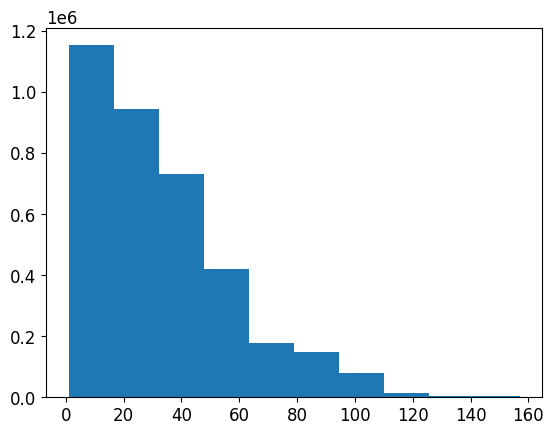

In [4]:

print("Loading data")
df_exps, df_roi, df_ca, df_behave, df_behave_ca = db.get_ca_behave_data(cfg, 
                                                                        exclude_bad_behave=True,
                                                                        exclude_bad_2p=True, 
                                                                        roi_type=None,
                                                                        #max_speed=20,
                                                                        #max_ahv_abs=300,
                                                                        min_ear_dist=None,
                                                                        max_ear_dist=40,
                                                                        calc_extra_behave=True,
                                                                        )

print("Loading connected pair data")
df_pair_conn = pd.read_hdf(cfg.db_conn_pair_file, key="key")
print("Loading pair ca data")
df_pair_ca = pd.read_hdf(cfg.db_somadend_ca_file, key="key")
print("Filtering ROI")
min_events = 30
df_roi = df_roi[df_roi["n_events"] >= min_events]

EXP_ROI_ID = "exp_id_roi_id"
df_roi[EXP_ROI_ID] = df_roi["exp_id"] + "_" + df_roi["roi_id"].astype(str)
df_behave_ca[EXP_ROI_ID] = df_behave_ca["exp_id"] + "_" + df_behave_ca["roi_id"].astype(str)
df_behave_ca[HEAD_SPEED_FILT_GRAD] =  df_behave_ca[bu.SPEED_FILT_GRAD] * (df_behave_ca[bu.LOCO_SPEED_FILT_GRAD] < LOCO_THRESH)

df_behave_ca = df_behave_ca[df_behave_ca[EXP_ROI_ID].isin(df_roi[EXP_ROI_ID])]
print("Done")
AHV_FILT_GRAD_ABS = bu.AHV_FILT_GRAD + "-abs"
df_behave_ca[AHV_FILT_GRAD_ABS] = np.abs(df_behave_ca[bu.AHV_FILT_GRAD])

plt.figure()
plt.hist(df_behave_ca[bu.MAZE_VISIT].values)


if RESPONSE_TYPE == cu.CA_EVENTS_ONSET:
    
    if EVENTS_ONSET_AS_RATE:
        # Convert to and event rate per minute
        df_behave_ca[RESPONSE_COL] = df_behave_ca[RESPONSE_TYPE] * df_behave_ca["fps_2p"] * 60
    else:
        # Convert to probability of an event
        df_behave_ca[RESPONSE_COL] = df_behave_ca[RESPONSE_TYPE]
        
elif RESPONSE_TYPE == cu.CA_EVENTS_MASK:
    # Convert to %
    df_behave_ca[RESPONSE_COL] = df_behave_ca[RESPONSE_TYPE] * 100
else:
    # Change signal to be per second instead of per frame
    df_behave_ca[RESPONSE_COL] = df_behave_ca[RESPONSE_TYPE] * df_behave_ca["fps_2p"]
    
if REMOVE_EVENTS:
    df_behave_ca[RESPONSE_COL] = df_behave_ca[RESPONSE_COL] * (1 - df_behave_ca[cu.CA_EVENTS_MASK])
    

print("Filtering unconnected dendrites")
EXP_SOMA_ID = "exp_id_soma_id"
EXP_DEND_ID = "exp_id_dend_id"
df_pair_conn[EXP_SOMA_ID] = df_pair_conn["exp_id"] + "_" + df_pair_conn["roi_index_1"].astype(str)
df_pair_conn[EXP_DEND_ID] = df_pair_conn["exp_id"] + "_" + df_pair_conn["roi_index_2"].astype(str)
# Get indexes of all soma and dendirtes that are connected to a dendrite.
# Disable dendrites
# soma_and_pairdend_indexes = np.logical_or(df_roi["roi_type"] == "soma",
#                             np.logical_and(df_roi["roi_type"] == "dend",
#                                            df_roi[EXP_ROI_ID].isin(df_pair_conn[EXP_DEND_ID])))

soma_and_pairdend_indexes = df_roi["roi_type"] == "soma"
                                          
# Filter down to just soma, and dendrites that are connected to soma
df_roi = df_roi[soma_and_pairdend_indexes]
df_behave_ca = df_behave_ca[df_behave_ca[EXP_ROI_ID].isin(df_roi[EXP_ROI_ID])]

df_behave_ca_orig = df_behave_ca.copy(deep=True)

print(df_roi["roi_type"].unique())


In [5]:

# Disable dend local joint
# print("Making local and joint dendrite data")
# print("Get all ids of rois that are dendrites")
# 
# 
# print("Get 2 copies of the dendrite data from df_behave_ca, one for local and one for joint")
# dendrite_indexes = df_roi["roi_type"] == "dend"
# dendrite_ids = df_roi[dendrite_indexes][EXP_ROI_ID].unique()
# 
# df_behave_ca_dend_joint = df_behave_ca[df_behave_ca[EXP_ROI_ID].isin(dendrite_ids)].copy(deep=True)
# df_behave_ca_dend_local = df_behave_ca_dend_joint.copy(deep=True)
# df_behave_ca_dend_both = df_behave_ca_dend_joint.copy(deep=True)
# 
# print("Get the dendrite masks from df_pair_ca just for these dendrites")
# df_pair_ca[EXP_SOMA_ID] = df_pair_ca["exp_id"] + "_" + df_pair_ca["roi_index_1"].astype(str)
# df_pair_ca[EXP_DEND_ID] = df_pair_ca["exp_id"] + "_" + df_pair_ca["roi_index_2"].astype(str)
# 
# # Get pair can data only for connected pairs
# df_pair_ca_conn = df_pair_ca[df_pair_ca['pair_id'].isin(df_pair_conn['pair_id'].unique())].copy(deep=True)
# 
# 
# print("Join the masks to the dendrite data on exp_id and roi_index_2")
# df_behave_ca_dend_joint = df_behave_ca_dend_joint.merge(df_pair_ca_conn, 
#                                                         left_on=["exp_id", "roi_id", "frame_id"], 
#                                                         right_on=["exp_id", "roi_index_2", "frame_id"],
#                                                         how="inner")
# df_behave_ca_dend_local = df_behave_ca_dend_local.merge(df_pair_ca_conn,
#                                                         left_on=["exp_id", "roi_id", "frame_id"], 
#                                                         right_on=["exp_id", "roi_index_2", "frame_id"],
#                                                         how="inner")
# df_behave_ca_dend_both = df_behave_ca_dend_both.merge(df_pair_ca_conn,
#                                                         left_on=["exp_id", "roi_id", "frame_id"], 
#                                                         right_on=["exp_id", "roi_index_2", "frame_id"],
#                                                         how="inner")
# 
# print("Mask out the response based on whether it's a joint or local event.")
# mask_joint = (df_behave_ca_dend_joint["masks2"] == 2)
# mask_local = (df_behave_ca_dend_local["masks2"] == 1)
# mask_both = np.logical_or(mask_joint, mask_local)
# 
# # # Invert the other mask so we delete events
# # # Doesn't work well because the start of the event is often too late.
# # mask_joint = 1 - (df_behave_ca_dend_joint["masks2"] == 1)
# # mask_local = 1 - (df_behave_ca_dend_local["masks2"] == 2)
# # mask_both ???
# 
# df_behave_ca_dend_joint[RESPONSE_TYPE] = df_behave_ca_dend_joint[RESPONSE_TYPE] * mask_joint
# df_behave_ca_dend_local[RESPONSE_TYPE] = df_behave_ca_dend_local[RESPONSE_TYPE] * mask_local
# df_behave_ca_dend_both[RESPONSE_TYPE] = df_behave_ca_dend_both[RESPONSE_TYPE] * mask_both
# 
# df_behave_ca_dend_joint[RESPONSE_COL] = df_behave_ca_dend_joint[RESPONSE_COL] * mask_joint
# df_behave_ca_dend_local[RESPONSE_COL] = df_behave_ca_dend_local[RESPONSE_COL] * mask_local
# df_behave_ca_dend_both[RESPONSE_COL] = df_behave_ca_dend_both[RESPONSE_COL] * mask_both
# 
# if RESPONSE_TYPE != cu.CA_EVENTS_ONSET:
#     df_behave_ca_dend_joint[cu.CA_EVENTS_ONSET] = df_behave_ca_dend_joint[cu.CA_EVENTS_ONSET] * mask_joint
#     df_behave_ca_dend_local[cu.CA_EVENTS_ONSET] = df_behave_ca_dend_local[cu.CA_EVENTS_ONSET] * mask_local
#     df_behave_ca_dend_both[cu.CA_EVENTS_ONSET] = df_behave_ca_dend_both[cu.CA_EVENTS_ONSET] * mask_both
# 
# if RESPONSE_TYPE != cu.CA_EVENTS_AMP:
#     df_behave_ca_dend_joint[cu.CA_EVENTS_AMP] = df_behave_ca_dend_joint[cu.CA_EVENTS_AMP] * mask_joint
#     df_behave_ca_dend_local[cu.CA_EVENTS_AMP] = df_behave_ca_dend_local[cu.CA_EVENTS_AMP] * mask_local
#     df_behave_ca_dend_both[cu.CA_EVENTS_AMP] = df_behave_ca_dend_both[cu.CA_EVENTS_AMP] * mask_both
# 
# if RESPONSE_TYPE != cu.CA_EVENTS_MASK:
#     df_behave_ca_dend_joint[cu.CA_EVENTS_MASK] = df_behave_ca_dend_joint[cu.CA_EVENTS_MASK] * mask_joint
#     df_behave_ca_dend_local[cu.CA_EVENTS_MASK] = df_behave_ca_dend_local[cu.CA_EVENTS_MASK] * mask_local
#     df_behave_ca_dend_both[cu.CA_EVENTS_MASK] = df_behave_ca_dend_both[cu.CA_EVENTS_MASK] * mask_both
# 
# print('Concatenate the dataframes back together')
# df_behave_ca_dend_joint['roi_type'] = 'dend_joint'
# df_behave_ca_dend_local['roi_type'] = 'dend_local'
# df_behave_ca_dend_both['roi_type'] = 'dend_both'
# df_behave_ca = pd.concat([df_behave_ca_orig, 
#                           df_behave_ca_dend_joint, 
#                           df_behave_ca_dend_local, 
#                           df_behave_ca_dend_both],
#                           ignore_index=True)
# 
# print('Concatenate the roi data for local and joint dendrites')
# dendrite_indexes = df_roi[EXP_ROI_ID].isin(dendrite_ids)
# df_roi_joint = df_roi[dendrite_indexes].copy(deep=True)
# df_roi_joint['roi_type'] = 'dend_joint'
# df_roi_local = df_roi[dendrite_indexes].copy(deep=True)
# df_roi_local['roi_type'] = 'dend_local'
# df_roi_both = df_roi[dendrite_indexes].copy(deep=True)
# df_roi_both['roi_type'] = 'dend_both'
# 
# df_roi = pd.concat([df_roi, 
#                     df_roi_joint, 
#                     df_roi_local,
#                     df_roi_both], 
#                     ignore_index=True)
# print("Load complete")

(9514, 143) 43.0


/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_93811/3618186297.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(df_expplot[df_indexes][cu.CA_DECONV_NORM].values, label="Deconv")
/var/folders/47/g6v8cjj50_9f9qvjg5w4fn480000gn/T/ipykernel_93811/3618186297.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.plot(df_expplot[df_indexes][cu.CA_EVENTS_MASK].values, label="Event Mask")


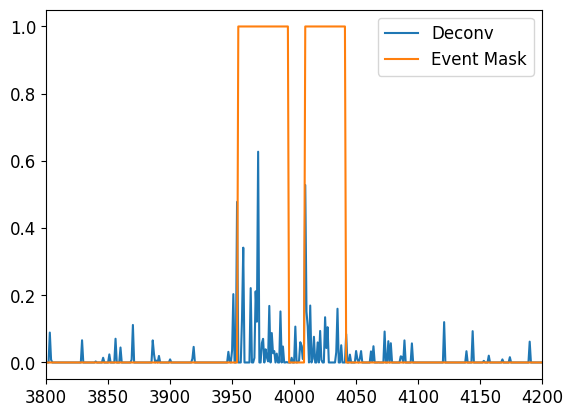

In [6]:
# Check an example trace data
xlim1 = 3800
xlim2 = 4200
df_indexes = (df_behave_ca['exp_id'] == "20210823_16_59_50_1114353") & \
                    (df_behave_ca['roi_id'] == 1)

df_expplot = df_behave_ca[df_indexes]

print(df_expplot.shape, np.sum(df_expplot[RESPONSE_COL]))

plt.figure()
# plt.plot(df_expplot[df_indexes][RESPONSE_COL].values/np.max(df_expplot[df_indexes][RESPONSE_COL].values), label="Response-time")
plt.plot(df_expplot[df_indexes][cu.CA_DECONV_NORM].values, label="Deconv")
plt.plot(df_expplot[df_indexes][cu.CA_EVENTS_MASK].values, label="Event Mask")
plt.xlim([xlim1, xlim2])
plt.legend()

(0, 143) 0.0
0.0 143
0.0 143
0.0 143


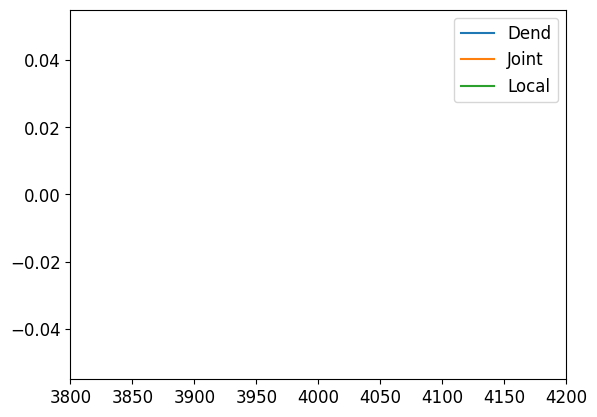

In [7]:
# Check the dendrite data
xlim1 = 3800
xlim2 = 4200

# df_expplot = df_behave_ca[df_behave_ca["exp_id"] == "20210823_16_59_50_1114353"]
# plot_indexes_dend = np.logical_and(df_expplot["roi_id"] == 18,
#                               df_expplot["roi_type"] == "dend") 
# 
# plot_indexes_joint = np.logical_and(df_expplot["roi_id"] == 18,
#                               df_expplot["roi_type"] == "dend_joint")  
# plot_indexes_local = np.logical_and(df_expplot["roi_id"] == 18,
#                               df_expplot["roi_type"] == "dend_local") 

df_indexes = (df_behave_ca['exp_id'] == "20210823_16_59_50_1114353") & \
                    (df_behave_ca['roi_id'] == 18) & \
                    (df_behave_ca['roi_type'] == "dend_local")

df_expplot = df_behave_ca[df_indexes]

print(df_expplot.shape, np.sum(df_expplot[RESPONSE_TYPE]))


df_expplot = df_behave_ca
plot_indexes_dend = (df_expplot["exp_id"] == "20210823_16_59_50_1114353") & (df_expplot["roi_id"] == 18) & \
                    (df_expplot["roi_type"] == "dend_both")

plot_indexes_joint = (df_expplot["exp_id"] == "20210823_16_59_50_1114353") & (df_expplot["roi_id"] == 18) & \
                     (df_expplot["roi_type"] == "dend_joint")  
plot_indexes_local = (df_expplot["exp_id"] == "20210823_16_59_50_1114353") & (df_expplot["roi_id"] == 18) & \
                     (df_expplot["roi_type"] == "dend_local")

print(np.sum(df_expplot[plot_indexes_dend][RESPONSE_TYPE].values), np.sum(df_expplot[plot_indexes_dend].shape))
print(np.sum(df_expplot[plot_indexes_joint][RESPONSE_TYPE].values), np.sum(df_expplot[plot_indexes_joint].shape))
print(np.sum(df_expplot[plot_indexes_local][RESPONSE_TYPE].values), np.sum(df_expplot[plot_indexes_local].shape))

plt.figure()
plt.plot(df_expplot[plot_indexes_dend][RESPONSE_TYPE].values, label="Dend")
plt.plot(df_expplot[plot_indexes_joint][RESPONSE_TYPE].values + 0.3, label="Joint")
plt.plot(df_expplot[plot_indexes_local][RESPONSE_TYPE].values + 0.6, label="Local")
plt.xlim([xlim1, xlim2])
plt.legend()

# plt.figure()
# plt.plot(df_behave_ca[plot_indexes_dend][RESPONSE_COL].values)
# plt.xlim([xlim1, xlim2])
# 
# plt.figure()
# plt.plot(df_behave_ca[plot_indexes_joint][RESPONSE_COL].values)
# plt.xlim([xlim1, xlim2])

In [8]:
grp_df_cell = df_behave_ca.groupby(['exp_id', 'animal_id', 'roi_id', 'celltype', 'roi_type'])

In [9]:
#bins_hd = np.linspace(0, 360, 36 + 1, endpoint=True)
bins_hd = np.linspace(0, 360, 8 + 1, endpoint=True)

#bins_ahv_pos = np.linspace(bu.ACTIVE_AHV_THRESH_UP, 60, 5 + 1, endpoint=True)
min_ahv = 1
bins_ahv_pos = np.linspace(min_ahv, 120, 13 + 1, endpoint=True)
bins_ahv_size = bins_ahv_pos[1] - bins_ahv_pos[0]
bins_ahv_pos = bins_ahv_pos[1:]
bin_ahv_extra = bins_ahv_pos[-1] + bins_ahv_size
bins_ahv = np.hstack((np.flip(-bins_ahv_pos),
                      -min_ahv,
                      min_ahv,
                      bins_ahv_pos,
                      bin_ahv_extra))


min_ahv_abs = 10
bins_ahv_abs = np.linspace(min_ahv_abs, 120, 13 + 1, endpoint=True)
# # Try without the zero bin
# bins_ahv_abs = bins_ahv[int((len(bins_ahv)-1)/2):]


speed_min = bu.ACTIVE_SPEED_THRESH_UP
# speed_max = 40
# bins_speed = np.append([0], np.linspace(speed_min, speed_max, 20 + 1, endpoint=True))
speed_max = 15
#bins_speed = np.append([0], np.linspace(speed_min, speed_max, 10 + 1, endpoint=True))
bins_speed = np.linspace(speed_min, speed_max, 10 + 1, endpoint=True)
# speed_max = 20
#bins_speed = np.append([0], np.linspace(speed_min, speed_max, 10 + 1, endpoint=True))
# Try without zero
#bins_speed = np.linspace(speed_min, speed_max, 20 + 1, endpoint=True)
#bins_speed = np.linspace(speed_min, speed_max, 10 + 1, endpoint=True)

maze_width = 7
maze_height = 5
maze_bin_sub = 1
bins_maze_x = np.linspace(0, maze_width, maze_width * maze_bin_sub + 1, endpoint=True)
bins_maze_y = np.linspace(0, maze_height, maze_height * maze_bin_sub + 1, endpoint=True)

bins_place_visit = np.linspace(1, 60, 60, endpoint=True)

#smooth_hd = [2, 'wrap']
#smooth_hd = [0.25, 'wrap']
smooth_hd = None
smooth_ahv = [1, 'reflect']
smooth_speed = [1, 'reflect']
#smooth_maze = [0.5, 'reflect']
smooth_maze = [0.25, 'reflect']
smooth_maze = None #[0.25, 'reflect']
smooth_place_visit = [2, 'reflect']

@dataclass
class BehaveInfo:
    name: str
    colname: str
    label: str = None
    index_fun: typing.Callable = None
    bins: np.array = None
    smooth: typing.List = None
    

@dataclass
class BehaveInfoStats:
    BehaveInfo: BehaveInfo
    info: float
    lags: np.array = None
    lag_infos: np.array = None


# behave_infos = [
#                 BehaveInfo(name="AHV",
#                            colname=bu.AHV_FILT_GRAD,
#                            index_fun=None,
#                            bins=bins_ahv,
#                            smooth=smooth_ahv),
#                 BehaveInfo(name="AHV-Abs",
#                            colname=AHV_FILT_GRAD_ABS,
#                            index_fun=None,
#                            bins=bins_ahv_abs,
#                            smooth=smooth_ahv),
#                 BehaveInfo(name="Speed",
#                            colname=bu.SPEED_FILT_GRAD,
#                            index_fun=None,
#                            bins=bins_speed,
#                            smooth=smooth_speed),
#                 BehaveInfo(name="Locomotion",
#                            colname=bu.LOCO_SPEED_FILT_GRAD,
#                            index_fun=None,
#                            bins=bins_speed,
#                            smooth=smooth_speed),
#                 BehaveInfo(name="Heading-Ego",
#                            colname=bu.HEADING_EGO_ABS_FILT,
#                            index_fun=bu.get_moving_indexes,
#                            bins=bins_hd,
#                            smooth=smooth_hd),
#                 BehaveInfo(name="HD",
#                            colname=bu.HD_ABS_FILT,
#                            index_fun=None,
#                            bins=bins_hd,
#                            smooth=smooth_hd),
#                 BehaveInfo(name="Heading-Allo",
#                            colname=bu.HEADING_ALLO_ABS_FILT,
#                            index_fun=bu.get_moving_indexes,
#                            bins=bins_hd,
#                            smooth=smooth_hd),
#                 BehaveInfo(name="Place",
#                            colname=(bu.HEAD_X_FILT_MAZE, bu.HEAD_Y_FILT_MAZE),
#                            index_fun=None,
#                            bins=(bins_maze_x, bins_maze_y),
#                            smooth=smooth_maze)]

behave_infos = [
                # BehaveInfo(name="Speed",
                #            colname=bu.SPEED_FILT_GRAD,
                #            label="Speed (cm/s)",
                #            index_fun=bu.get_active_indexes, 
                #            bins=bins_speed,
                #            smooth=smooth_speed),
    
                # BehaveInfo(name="AHV",
                #            colname=bu.AHV_FILT_GRAD,
                #            index_fun=bu.get_active_indexes,
                #            bins=bins_ahv,
                #            smooth=smooth_ahv),
                # BehaveInfo(name="AHV-Abs",
                #            colname=AHV_FILT_GRAD_ABS,
                #            index_fun=bu.get_active_indexes,
                #            bins=bins_ahv_abs,
                #            smooth=smooth_ahv),
                BehaveInfo(name="HD",
                           label="Head direction (°)",
                           colname=bu.HD_ABS_FILT,
                           index_fun=bu.get_moving_indexes, 
                           bins=bins_hd,
                           smooth=smooth_hd),
                BehaveInfo(name="Place",
                           colname=(bu.HEAD_X_FILT_MAZE, bu.HEAD_Y_FILT_MAZE),
                           index_fun=bu.get_moving_indexes,
                           bins=(bins_maze_x, bins_maze_y),
                           smooth=smooth_maze),
                # BehaveInfo(name="Place-NotSmoothed",
                #            colname=(bu.HEAD_X_FILT_MAZE, bu.HEAD_Y_FILT_MAZE),
                #            index_fun=bu.get_active_indexes,
                #            bins=(bins_maze_x, bins_maze_y),
                #            smooth=None),
                # BehaveInfo(name="Place-Visit",
                #            colname=bu.MAZE_VISIT,
                #            index_fun=bu.get_active_indexes,
                #            bins=bins_place_visit,
                #            smooth=None),  
    
    
                # BehaveInfo(name="Locomotion",
                #            colname=bu.LOCO_SPEED_FILT_GRAD,
                #            index_fun=bu.get_active_indexes, 
                #            bins=bins_speed,
                #            smooth=smooth_speed),
                # BehaveInfo(name="Speed-Head",
                #            colname=HEAD_SPEED_FILT_GRAD,
                #            index_fun=bu.get_active_indexes, 
                #            bins=bins_speed,
                #            smooth=smooth_speed),
                # BehaveInfo(name="Heading-Ego",
                #            colname=bu.HEADING_EGO_ABS_FILT,
                #            index_fun=bu.get_moving_indexes,
                #            bins=bins_hd,
                #            smooth=smooth_hd),
                # BehaveInfo(name="Heading-Allo",
                #            colname=bu.HEADING_ALLO_ABS_FILT,
                #            index_fun=bu.get_moving_indexes,
                #            bins=bins_hd,
                #            smooth=smooth_hd),
                ]

@dataclass
class InfoMeasures:
    behave_info: BehaveInfo
    bin_ca_mean: np.array
    info: float
    info_lower: float
    info_no_lag: float
    info_no_lag_lower: float
    info_sig95: float
    info_light_sig95: float
    info_dark_sig95: float
    info_sig99: float
    info_light_sig99: float
    info_dark_sig99: float
    info_sig50: float
    info_light_sig50: float
    info_dark_sig50: float
    peak1: float
    peak2: float
    lags: np.array
    lag_best_index: int
    lag_best_time: float
    lag_infos: np.array
    light_lag_infos: np.array
    dark_lag_infos: np.array
    lag_before_info_mean: float
    lag_after_info_mean: float
    lag_light_before_info_mean: float
    lag_light_after_info_mean: float
    lag_dark_before_info_mean: float
    lag_dark_after_info_mean: float
    boot_info: np.array
    boot_ci95: float
    corr_light: float
    corr_half: float
    corr_inter: float
    corr_inter_lag: float
    corr_p_light: float
    corr_p_half: float
    corr_p_inter: float
    corr_p_inter_lag: float
    corr_inter_lower: float
    corr_inter_upper: float
    info_light: float
    info_dark: float
    info_light_lag: float
    info_dark_lag: float
    info_half1: float
    info_half2: float
    info_inter1: float
    info_inter2: float
    info_inter1_lag: float
    info_inter2_lag: float
    twonorm_light: float
    twonorm_light_scale: float
    twonorm_light_norm: float
    twonorm_inter: float
    twonorm_inter_scale: float
    twonorm_inter_norm: float
    twonorm_half: float
    twonorm_half_scale: float
    twonorm_half_norm: float

In [10]:
# Run the main analysis
def rm_nans(a1, a2):
    nan_indexes = np.logical_or(np.isnan(a1), np.isnan(a2))
    a1 = a1[~nan_indexes]
    a2 = a2[~nan_indexes]
    return a1, a2

def scale_arr(arr):
    min_val = np.nanmin(arr)
    max_val = np.nanmax(arr)
    if min_val == max_val:
        return 0
    else:
        return (arr - min_val) / (max_val - min_val)


def norm_arr(arr):
    norm = np.linalg.norm(arr)
    if norm == 0: 
       return arr
    return arr / norm

def get_best_lags(lag_infos, valid_lags, valid_lag_indexes):
    
    smooth_lag_infos = gaussian_filter1d(lag_infos, 3)
    valid_lag_infos = smooth_lag_infos[valid_lag_indexes]
    
    best_lag_index = np.argmax(valid_lag_infos)
    best_lag = valid_lags[best_lag_index]
    best_lag_info = valid_lag_infos[best_lag_index]
    
    n_nz_lags = int((valid_lag_infos.shape[0] - 1) / 2)
    before_info_mean = np.mean(valid_lag_infos[0:n_nz_lags-1])
    after_info_mean = np.mean(valid_lag_infos[n_nz_lags+1:])
    
    return best_lag, best_lag_info, best_lag_index, before_info_mean, after_info_mean

def calc_info_all(df,
                  behave_info,
                  response_col,
                  light_indexes=None,
                  dark_indexes=None,
                  inter1_indexes=None,
                  inter2_indexes=None,
                  half1_indexes=None,
                  half2_indexes=None,
                  n_lags=0,
                  n_lags_valid=0,
                  n_rolls=0,
                  min_roll=0,
                  n_boots=0,
                  plot_curves=False,
                  plot_events=True,
                  plot_behave=True,
                  plot_ca_mean=True,
                  plot_inter_on_light=True):

    is_spatial_tuning = type(behave_info.bins) is tuple

    df_light = df[light_indexes].copy(deep=True)
    df_dark = df[dark_indexes].copy(deep=True)
    
    # Calculate the time lag of the tuning by cross-correlation

    # Shift the response by a fixed neural latency for all other calculations
    nolag_resp_orig = df[response_col].copy()
    nolag_light_resp_orig = df_light[response_col].copy()
    nolag_dark_resp_orig = df_dark[response_col].copy()
    df[response_col] = np.roll(df[response_col], NEURAL_LATENCY_FRAMES)
    df_light[response_col] = np.roll(df_light[response_col], NEURAL_LATENCY_FRAMES)
    df_dark[response_col] = np.roll(df_dark[response_col], NEURAL_LATENCY_FRAMES)

    lags = np.arange(-n_lags, n_lags+1)
    lag_infos = np.full(lags.shape, np.nan)
    light_lag_infos = np.full(lags.shape, np.nan)
    dark_lag_infos = np.full(lags.shape, np.nan)
    resp_orig = df[response_col].copy()
    light_resp_orig = df_light[response_col].copy()
    dark_resp_orig = df_dark[response_col].copy()
    
    for i_lag in range(len(lags)):

        df[response_col] = resp_orig
        df[response_col] = np.roll(df[response_col], lags[i_lag])
        df_light[response_col] = light_resp_orig
        df_light[response_col] = np.roll(df_light[response_col], lags[i_lag])
        df_dark[response_col] = dark_resp_orig
        df_dark[response_col] = np.roll(df_dark[response_col], lags[i_lag])

        tune_info = calc_info(df,
                              behave_info,
                              response_col)
        
        light_tune_info = calc_info(df_light,
                                    behave_info,
                                    response_col)
        
        dark_tune_info = calc_info(df_dark,
                                   behave_info,
                                   response_col)


        lag_infos[i_lag] = tune_info.info
        light_lag_infos[i_lag] = light_tune_info.info
        dark_lag_infos[i_lag] = dark_tune_info.info
        

    # Un do all the rolling for lag tests
    df[response_col] = resp_orig
    df_light[response_col] = light_resp_orig
    df_dark[response_col] = dark_resp_orig

    # Undo the neural latency shift
    df[response_col] = nolag_resp_orig
    df_light[response_col] = nolag_light_resp_orig
    df_dark[response_col] = nolag_dark_resp_orig


    
    # A wide range of lags may be used but only take the best one within the valid range.
    valid_lag_indexes = np.logical_and(lags >= -n_lags_valid, lags <= n_lags_valid)
    valid_lags = lags[valid_lag_indexes]
    
    best_lag, best_lag_info, best_lag_index, before_info_mean, after_info_mean = get_best_lags(lag_infos, valid_lags, valid_lag_indexes)
    light_best_lag, light_best_lag_info, light_best_lag_index, light_before_info_mean, light_after_info_mean = get_best_lags(light_lag_infos, valid_lags, valid_lag_indexes)
    dark_best_lag, dark_best_lag_info, dark_best_lag_index, dark_before_info_mean, dark_after_info_mean = get_best_lags(dark_lag_infos, valid_lags, valid_lag_indexes)
    
    # Calculate information at optimal time
    resp_orig = df[response_col].copy()
    df[response_col] = np.roll(df[response_col], best_lag)
    tune_info_lag = calc_info(df,
                              behave_info,
                              response_col)

    # Set back to non lagged!! Don't forget this!
    df[response_col] = resp_orig


    # Shift the response by a fixed neural latency for all other calculations
    resp_orig = df[response_col].copy()
    df[response_col] = np.roll(df[response_col], NEURAL_LATENCY_FRAMES)

    # Calculate the information for the halves of the session
    tune_info_half1 = calc_info(df[half1_indexes],
                                behave_info,
                                response_col)

    tune_info_half2 = calc_info(df[half2_indexes],
                                behave_info,
                                response_col)
    
    v1 = tune_info_half1.bin_ca_means.flatten()
    v2 = tune_info_half2.bin_ca_means.flatten()
    v1, v2 = rm_nans(v1, v2)
    half_vect = v1 - v2
    half_vect_scale = scale_arr(v1) - scale_arr(v2)
    half_vent_norm = norm_arr(v1) - norm_arr(v2)
    twonorm_half = np.linalg.norm(half_vect)
    twonorm_half_scale = np.linalg.norm(half_vect_scale)
    twonorm_half_norm = np.linalg.norm(half_vent_norm)

    # Calculate the information for interleaved data
    tune_info_inter1 = calc_info(df[inter1_indexes],
                                behave_info,
                                response_col,
                                n_boots=n_boots)

    tune_info_inter2 = calc_info(df[inter2_indexes],
                                behave_info,
                                response_col,
                                n_boots=n_boots)
    
    
    v1 = tune_info_inter1.bin_ca_means.flatten()
    v2 = tune_info_inter2.bin_ca_means.flatten()
    v1, v2 = rm_nans(v1, v2)
    inter_vect = v1 - v2
    inter_vect_scale = scale_arr(v1) - scale_arr(v2)
    inter_vect_norm = norm_arr(v1) - norm_arr(v2)
    twonorm_inter = np.linalg.norm(inter_vect)
    twonorm_inter_scale = np.linalg.norm(inter_vect_scale)
    twonorm_inter_norm = np.linalg.norm(inter_vect_norm)

    # Calculate the information for light and dark
    tune_info_light = calc_info(df[light_indexes],
                                behave_info,
                                response_col,
                                n_boots=n_boots,)

    tune_info_dark = calc_info(df[dark_indexes],
                                behave_info,
                                response_col,
                                n_boots=n_boots)
    
    v1 = tune_info_light.bin_ca_means.flatten()
    v2 = tune_info_dark.bin_ca_means.flatten()
    v1, v2 = rm_nans(v1, v2)
    light_vect = v1 - v2
    light_vect_scale = scale_arr(v1) - scale_arr(v2)
    light_vent_norm = norm_arr(v1) - norm_arr(v2)
    twonorm_light = np.linalg.norm(light_vect)
    twonorm_light_scale = np.linalg.norm(light_vect_scale)
    twonorm_light_norm = np.linalg.norm(light_vent_norm)

    # Calculate the information for interleaved data
    tune_info_inter1_lag = calc_info(df[inter1_indexes],
                                     behave_info,
                                     response_col)

    tune_info_inter2_lag = calc_info(df[inter2_indexes],
                                     behave_info,
                                     response_col)

    # Calculate the correlation between the splits
    half_corr = su.nanspearmanr(tune_info_half1.bin_ca_means.flatten(),
                         tune_info_half2.bin_ca_means.flatten())
    inter_corr = su.nanspearmanr(tune_info_inter1.bin_ca_means.flatten(),
                          tune_info_inter2.bin_ca_means.flatten())
    inter_lag_corr = su.nanspearmanr(tune_info_inter1_lag.bin_ca_means.flatten(),
                          tune_info_inter2_lag.bin_ca_means.flatten())
    light_corr = su.nanspearmanr(tune_info_light.bin_ca_means.flatten(),
                          tune_info_dark.bin_ca_means.flatten())

    # Calculate CI of correlation
    inter_corr_boot = np.full((n_boots, 1), 0, dtype=float)
    inter_corr_lower = np.NaN
    inter_corr_upper = np.NaN
    for i_boot in range(n_boots):
        inter_r = su.nanspearmanr(tune_info_inter1.boot_bin_ca_means[i_boot,: ].flatten(),
                                  tune_info_inter2.boot_bin_ca_means[i_boot,: ].flatten())

        inter_corr_boot[i_boot] = inter_r.statistic

    if n_boots > 0:
        inter_corr_lower = np.percentile(inter_corr_boot, 2.5)
        inter_corr_upper = np.percentile(inter_corr_boot, 97.5)



    # Calculate information at time zero
    tune_info_zero = calc_info(df,
                               behave_info,
                               response_col,
                               n_boots=n_boots)
    # Set back to non latency adjusted before doing rolls!! Don't forget this!
    df[response_col] = resp_orig

    # Calculate the significance of the information by rolling
    rolls = tu.get_boot_rolls(df[response_col].shape[0],
                              int(n_rolls / 2),
                              min_roll)
    
    roll_infos = np.full((n_rolls, 1), np.nan)
    roll_infos_light = np.full((n_rolls, 1), np.nan)
    roll_infos_dark = np.full((n_rolls, 1), np.nan)
    
    df_light = df[light_indexes].copy(deep=True)
    df_dark = df[dark_indexes].copy(deep=True)
    
    resp_orig = df[response_col].copy()
    resp_orig_light = df_light[response_col].copy()
    resp_orig_dark = df_dark[response_col].copy()
    for i_roll in range(n_rolls):

        df[response_col] = resp_orig
        df[response_col] = np.roll(df[response_col], rolls[i_roll])

        tune_info_roll = calc_info(df,
                                    behave_info,
                                    response_col)
        
        # Calculate the information for light and dark
        df_light[response_col] = resp_orig_light
        df_light[response_col] = np.roll(df_light[response_col], rolls[i_roll])
        tune_info_light_roll = calc_info(df_light,
                                         behave_info,
                                         response_col)
        
        df_dark[response_col] = resp_orig_dark
        df_dark[response_col] = np.roll(df_dark[response_col], rolls[i_roll])
        tune_info_dark_roll = calc_info(df_dark,
                                        behave_info,
                                        response_col)

        
        roll_infos[i_roll] = tune_info_roll.info
        roll_infos_light[i_roll] = tune_info_light_roll.info
        roll_infos_dark[i_roll] = tune_info_dark_roll.info

    df[response_col] = resp_orig
    df_light[response_col] = resp_orig_light
    df_dark[response_col] = resp_orig_dark

    info_sig95 = np.percentile(roll_infos, 95)
    info_light_sig95 = np.percentile(roll_infos_light, 95)
    info_dark_sig95 = np.percentile(roll_infos_dark, 95)
    info_sig99 = np.percentile(roll_infos, 99)
    info_light_sig99 = np.percentile(roll_infos_light, 99)
    info_dark_sig99 = np.percentile(roll_infos_dark, 99)
    info_sig50 = np.percentile(roll_infos, 50)
    info_light_sig50 = np.percentile(roll_infos_light, 50)
    info_dark_sig50 = np.percentile(roll_infos_dark, 50)
    is_sig = (tune_info_zero.info > info_sig95) & (inter_corr_lower > 0)
    
    # Get the peak values
    peak1 = np.NaN
    peak2 = np.NaN
    if not is_spatial_tuning:
        
        behave_bins = behave_info.bins
        midpoints = (behave_bins[:-1] + behave_bins[1:]) / 2
        # Get the index of the maximum tune_info_zero.bin_ca_means
        peak1_index = np.nanargmax(tune_info_zero.bin_ca_means)
        peak1 = midpoints[peak1_index]
    else:
        
        bins_x = behave_info.bins[0]
        bins_y = behave_info.bins[1]
        
        midpoints_x = bins_x[1:]
        midpoints_y = bins_y[1:]
        # Get the index of the maximum tune_info_zero.bin_ca_means
        peak_index = np.nanargmax(tune_info_zero.bin_ca_means)
        row, col = np.unravel_index(peak_index, tune_info_zero.bin_ca_means.shape)
        peak1 = midpoints_x[row]
        peak2 = midpoints_y[col]
    


    # Plotting
    plot_name = "{}_{:03d}_{}_{}_{}_{}_tuning_00_all.png".format(exp_id,
                                                       roi_id,
                                                       roi_type,
                                                       cell_type,
                                                       behave_info.name,
                                                       response_col)

    plot_path = os.path.join(cfg.sum_tune_roi_path, plot_name)
    tune_plot_ratio = (8, 4)
    if RESPONSE_TYPE == cu.CA_EVENTS_ONSET and not EVENTS_ONSET_AS_RATE:
        ylabel_text = "Event probability"
    else:
        ylabel_text = cu.get_ca_unit_rate(RESPONSE_TYPE)
    if PLOT_TUNING_CURVES and plot_curves:

        if not is_spatial_tuning:


            plot_bins = behave_info.bins.copy()[0:-1]
            bin_lo = plot_bins[0]
            bin_hi = plot_bins[-1]

            # Main plot with wide aspect ratio
            
            fig, ax = plt.subplots(figsize=tune_plot_ratio)
            line, = ax.plot(plot_bins,
                             tune_info_zero.bin_ca_means,
                             color='deepskyblue')

            if n_boots > 0:
                if PLOT_ERROR_AS_REGION:
                    ax.fill_between(plot_bins,
                                    tune_info_zero.bin_ca_means_lo,
                                    tune_info_zero.bin_ca_means_hi,
                                    color=line.get_color(), alpha=0.3)
                else:
                    ax.errorbar(plot_bins,
                                tune_info_zero.bin_ca_means,
                                yerr=[tune_info_zero.bin_ca_means - tune_info_zero.bin_ca_means_lo,
                                      tune_info_zero.bin_ca_means_hi - tune_info_zero.bin_ca_means],
                                color=line.get_color(),
                                linestyle='None',
                                capsize=3)

            if not RESPONSE_TYPE == cu.CA_EVENTS_ONSET and plot_ca_mean:
                ax.plot((bin_lo, bin_hi), (tune_info_zero.ca_mean, tune_info_zero.ca_mean))
            
            ax.set_ylabel(ylabel_text)
            
            if plot_events:
                df_events = df[df[cu.CA_EVENTS_ONSET]==1]
                event_amps = df_events[cu.CA_EVENTS_AMP]
                event_behave = df_events[behave_info.colname]
                
                ax1 = ax.twinx()
                ax1.yaxis.set_label_position('left')
                ax1.yaxis.tick_left()
                ax1.spines["left"].set_position(("axes", -0.2))
                
                
                ax1.scatter(event_behave,
                            event_amps,
                            c=pu.COLOUR_TUNE_CURVE)
                
                ax1.set_ylim(bottom=0)# Move the second y-axis to the left
                
                ax1.set_ylabel("Event amplitude (df/F0)")

            if plot_behave:
                ax2 = ax.twinx()
                ax2.plot(plot_bins,
                         tune_info_zero.bin_probs * 100,
                         color='red')
                ax2.set_ylabel("Behaviour time (%)", color='red')

            plt.xlabel(behave_info.label)
            ax.set_ylabel(ylabel_text)
            plt.xlim(left=bin_lo, right=bin_hi)
            #ax.set_ylim(bottom=0)

            plt.gca().spines['top'].set_visible(False)
            plt.gca().spines['right'].set_visible(False)

            plt.title("{:.3f} bits ({:.2f}) rLower={:.2f}".format(tune_info_zero.info, 
                                                                  info_sig95,
                                                                  inter_corr_lower))
            plt.tight_layout()

            plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white')
            plt.close()
            if is_sig: 
                mu.copy2dir(plot_path, cfg.sum_tune_roi_sig_path)  
                mu.copy2dir(plot_path, cfg.sum_tune_roi_sig_path / behave_info.name)  
                mu.copy2dir(plot_path, cfg.sum_tune_roi_sig_path / behave_info.name / cell_type)  
            else:
                mu.copy2dir(plot_path, cfg.sum_tune_roi_nonsig_path)
                mu.copy2dir(plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name)
                mu.copy2dir(plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name / cell_type)

            # # Plot the interleaves
            # plt.figure()
            # line, = plt.plot(plot_bins,
            #          tune_info_zero.bin_ca_means)
            # 
            # if n_boots > 0:
            #     plt.fill_between(plot_bins,
            #                      tune_info_zero.bin_ca_means_lo,
            #                      tune_info_zero.bin_ca_means_hi,
            #                      color=line.get_color(), alpha=0.3)
            # 
            # plt.plot(plot_bins,
            #          tune_info_inter1.bin_ca_means,
            #          color='gray')
            # 
            # plt.plot(plot_bins,
            #          tune_info_inter2.bin_ca_means,
            #          color='gray', linestyle=":")
            # 
            # ax2 = plt.twinx()
            # ax2.plot(plot_bins,
            #          tune_info_inter1.bin_probs * 100,
            #          color='red')
            # 
            # ax2.plot(plot_bins,
            #          tune_info_inter2.bin_probs * 100,
            #          color='red', linestyle=":")
            # 
            # plt.xlabel(behave_info.colname)
            # plt.ylabel(response_col)
            # ax2.set_ylabel("Behaviour time (%)", color='red')
            # plt.xlim(left=bin_lo, right=bin_hi)
            # plt.ylim(bottom=0)
            # plt.title("2norm={:.2f} rLow={:.3f} {:.3f} bits ({:.2f}) {:.3f} bits ({:.2f})".format(
            #                                      twonorm_inter, 
            #                                      inter_corr_lower,
            #                                      tune_info_inter1.info,
            #                                      tune_info_inter1.info_hi,
            #                                      tune_info_inter2.info,
            #                                      tune_info_inter2.info_hi))
            # 
            # 
            # plt.tight_layout()
            # 
            # new_plot_path = plot_path.replace("tuning_00_all", "tuning_01_inter")
            # plt.savefig(new_plot_path, dpi=PLOT_DPI, facecolor='white')
            # plt.close()
            # if is_sig: 
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path)
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name)
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name / cell_type)
            # else:
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path)
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name) 
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name / cell_type)


            # Plot the light and dark
            fig, ax = plt.subplots(figsize=tune_plot_ratio)

            linelight, = ax.plot(plot_bins,
                     tune_info_light.bin_ca_means,
                     color='orange', label='Light')


            linedark, = ax.plot(plot_bins,
                     tune_info_dark.bin_ca_means,
                     color='black', label='Dark')

            if n_boots > 0:
                if PLOT_ERROR_AS_REGION:
                    ax.fill_between(plot_bins,
                                    tune_info_light.bin_ca_means_lo,
                                    tune_info_light.bin_ca_means_hi,
                                    color=linelight.get_color(), alpha=0.3)
                else:
                    ax.errorbar(plot_bins,
                                tune_info_light.bin_ca_means,
                                yerr=[tune_info_light.bin_ca_means - tune_info_light.bin_ca_means_lo,
                                      tune_info_light.bin_ca_means_hi - tune_info_light.bin_ca_means],
                                color=linelight.get_color(),
                                linestyle='None',
                                capsize=3)

            if n_boots > 0:
                if PLOT_ERROR_AS_REGION:
                    ax.fill_between(plot_bins,
                                    tune_info_dark.bin_ca_means_lo,
                                    tune_info_dark.bin_ca_means_hi,
                                    color=linedark.get_color(), alpha=0.3)
                else:
                    ax.errorbar(plot_bins,
                                tune_info_dark.bin_ca_means,
                                yerr=[tune_info_dark.bin_ca_means - tune_info_dark.bin_ca_means_lo,
                                      tune_info_dark.bin_ca_means_hi - tune_info_dark.bin_ca_means],
                                color=linedark.get_color(),
                                linestyle='None',
                                capsize=3)

            if plot_inter_on_light:
                ax.plot(plot_bins,
                         tune_info_inter1.bin_ca_means,
                         color='blueviolet', label='Interleave 1')

                ax.plot(plot_bins,
                         tune_info_inter2.bin_ca_means,
                         color='orchid', label='Interleave 2')
            
            ax.set_ylabel(ylabel_text)
            
            if plot_events:  
                df_events_light = df_light[df_light[cu.CA_EVENTS_ONSET]==1]
                df_events_dark = df_dark[df_dark[cu.CA_EVENTS_ONSET]==1]
                event_amps_light = df_events_light[cu.CA_EVENTS_AMP]
                event_amps_dark = df_events_dark[cu.CA_EVENTS_AMP]
                event_behave_light = df_events_light[behave_info.colname]
                event_behave_dark = df_events_dark[behave_info.colname]
                
                ax1 = ax.twinx()
                ax1.yaxis.set_label_position('left')
                ax1.yaxis.tick_left()
                ax1.spines["left"].set_position(("axes", -0.2))  # Move the second y-axis to the left
                
                ax1.scatter(event_behave_light,
                            event_amps_light,
                            c=pu.COLOUR_LIGHT, 
                            label='Light events')
                
                ax1.scatter(event_behave_dark,
                            event_amps_dark,
                            c=pu.COLOUR_DARK,
                            label='Dark events')
                
                ax1.set_ylabel("Event amplitude (df/F0)")
                ax1.set_ylim(bottom=0)

            if plot_behave:
                ax2 = ax.twinx()
                ax2.plot(plot_bins,
                         tune_info_light.bin_probs * 100,
                         color='red')
                ax2.plot(plot_bins,
                         tune_info_dark.bin_probs * 100,
                         color='red', linestyle=":")
                ax2.set_ylabel("Behaviour time (%)", color='red')

            plt.gca().spines['top'].set_visible(False)
            plt.gca().spines['right'].set_visible(False)

            plt.xlabel(behave_info.label)
            plt.xlim(left=bin_lo, right=bin_hi)
            #ax.set_ylim(bottom=0)
            plt.title("light={:.3f}({:.2f}) dark={:.3f}({:.2f})\ndist={:.3f}({:.3f}) ".format(
                                                 tune_info_light.info,
                                                 tune_info_light.info_hi,
                                                 tune_info_dark.info,
                                                 tune_info_dark.info_hi,
                                                 twonorm_light, 
                                                 twonorm_inter,))

            plt.legend()
            plt.tight_layout()

            new_plot_path = plot_path.replace("tuning_00_all", "tuning_02_light")
            plt.savefig(new_plot_path, dpi=PLOT_DPI, facecolor='white')
            plt.close()
            if is_sig: 
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path)
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name) 
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name / cell_type) 
            else:
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path)
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name)
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name / cell_type)
                
            

        else:

            # Plot the place tuning map with behaviour
            if plot_behave:
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
            else:
                fig, ax1 = plt.subplots(1, 1)
            img1 = ax1.imshow(tune_info_zero.bin_ca_means.T)
            ax1.tick_params(
                axis='both',  # changes apply to the both axis
                which='both',  # both major and minor ticks are affected
                bottom=False,  # ticks along the bottom edge are off
                left=False,
                labelleft=False,
                labelbottom=False)  # labels along the bottom edge are off
            cbar = fig.colorbar(img1, ax=ax1)
            cbar.ax.set_ylabel(ylabel_text, rotation=90)
            ax1.set_title("{:.2f} bits ({:.2f}) rLow{:.2f}".format(tune_info_zero.info, 
                                                                   info_sig95,
                                                                   inter_corr_lower))
            maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
            ax1.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
                     maze_bin_sub * np.array(maze_poly_y) - 0.5,
                     'k', linewidth=3)
            ax1.spines[['left', 'top', 'right', 'bottom']].set_visible(False)
            if plot_events:
                df_events = df[df[cu.CA_EVENTS_ONSET]==1]
                event_amps = df_events[cu.CA_EVENTS_AMP]
                event_x = df_events[bu.HEAD_X_FILT_MAZE]
                event_y = df_events[bu.HEAD_Y_FILT_MAZE]
            
                ax1.scatter(maze_bin_sub * event_x - 0.5,
                            maze_bin_sub * event_y - 0.5,
                            c='k',
                            edgecolors='white',)
                
            if plot_behave:
                data = tune_info_zero.bin_probs.T * 100
                data[data == 0] = np.nan
                img2 = ax2.imshow(data)
                ax2.tick_params(
                    axis='both',  # changes apply to the both axis
                    which='both',  # both major and minor ticks are affected
                    bottom=False,  # ticks along the bottom edge are off
                    left=False,
                    labelleft=False,
                    labelbottom=False)  # labels along the bottom edge are off
                cbar2 = fig.colorbar(img2, ax=ax2)
                cbar2.ax.set_ylabel("Behaviour time (%)", rotation=90)

                maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
                ax2.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
                         maze_bin_sub * np.array(maze_poly_y) - 0.5,
                         'k', linewidth=3)

            fig.tight_layout()
            plt.savefig(plot_path, dpi=PLOT_DPI, facecolor='white')
            plt.close()
            if is_sig: 
                mu.copy2dir(plot_path, cfg.sum_tune_roi_sig_path)
                mu.copy2dir(plot_path, cfg.sum_tune_roi_sig_path / behave_info.name)
                mu.copy2dir(plot_path, cfg.sum_tune_roi_sig_path / behave_info.name / cell_type)
            else:
                mu.copy2dir(plot_path, cfg.sum_tune_roi_nonsig_path)
                mu.copy2dir(plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name) 
                mu.copy2dir(plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name / cell_type)

            # # Plot the tuning map of inter1 and inter2
            # fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 5))
            # img1 = ax1.imshow(tune_info_inter1.bin_ca_means.T)
            # ax1.tick_params(
            #     axis='both',  # changes apply to the both axis
            #     which='both',  # both major and minor ticks are affected
            #     bottom=False,  # ticks along the bottom edge are off
            #     left=False,
            #     labelleft=False,
            #     labelbottom=False)  # labels along the bottom edge are off
            # cbar = fig.colorbar(img1, ax=ax1)
            # cbar.ax.set_ylabel(response_col, rotation=90)
            # ax1.set_title("r={:.2f} p={:.3f}".format(inter_corr.statistic, inter_corr.pvalue))
            # maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
            # ax1.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
            #          maze_bin_sub * np.array(maze_poly_y) - 0.5,
            #          'k', linewidth=3)
            # 
            # img2 = ax2.imshow(tune_info_inter1.bin_probs.T * 100)
            # ax2.tick_params(
            #     axis='both',  # changes apply to the both axis
            #     which='both',  # both major and minor ticks are affected
            #     bottom=False,  # ticks along the bottom edge are off
            #     left=False,
            #     labelleft=False,
            #     labelbottom=False)  # labels along the bottom edge are off
            # cbar2 = fig.colorbar(img2, ax=ax2)
            # cbar2.ax.set_ylabel("Behaviour time (%)", rotation=90)
            # maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
            # ax2.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
            #          maze_bin_sub * np.array(maze_poly_y) - 0.5,
            #          'k', linewidth=3)
            # 
            # img3 = ax3.imshow(tune_info_inter2.bin_ca_means.T)
            # ax3.tick_params(
            #     axis='both',  # changes apply to the both axis
            #     which='both',  # both major and minor ticks are affected
            #     bottom=False,  # ticks along the bottom edge are off
            #     left=False,
            #     labelleft=False,
            #     labelbottom=False)  # labels along the bottom edge are off
            # cbar3 = fig.colorbar(img3, ax=ax3)
            # cbar3.ax.set_ylabel(response_col, rotation=90) 
            # ax3.set_title("{:.3f} bits ({:.2f}) {:.3f} bits ({:.2f})".format(tune_info_inter1.info,
            #                                                                  tune_info_inter1.info_hi,
            #                                                                  tune_info_inter2.info,
            #                                                                  tune_info_inter2.info_hi))
            # maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
            # ax3.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
            #          maze_bin_sub * np.array(maze_poly_y) - 0.5,
            #          'k', linewidth=3)
            # 
            # img4 = ax4.imshow(tune_info_inter2.bin_probs.T * 100)
            # ax4.tick_params(
            #     axis='both',  # changes apply to the both axis
            #     which='both',  # both major and minor ticks are affected
            #     bottom=False,  # ticks along the bottom edge are off
            #     left=False,
            #     labelleft=False,
            #     labelbottom=False)  # labels along the bottom edge are off
            # cbar4 = fig.colorbar(img4, ax=ax4)
            # cbar4.ax.set_ylabel("Behaviour time (%)", rotation=90)
            # maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
            # ax4.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
            #          maze_bin_sub * np.array(maze_poly_y) - 0.5,
            #          'k', linewidth=3)
            # 
            # fig.tight_layout()
            # new_plot_path = plot_path.replace("tuning_00_all", "tuning_01_inter")
            # plt.savefig(new_plot_path, dpi=PLOT_DPI, facecolor='white')
            # plt.close()
            # if is_sig: 
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path)
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name)
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name / cell_type)
            # else:
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path)
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name)
            #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name / cell_type)


            # Plot the tuning map of light and dark
            if plot_behave:
                fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 5))
            else:
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

            # Calculate global min and max for color scaling
            global_min = min(np.nanmin(tune_info_light.bin_ca_means), np.nanmin(tune_info_dark.bin_ca_means))
            global_max = max(np.nanmax(tune_info_light.bin_ca_means), np.nanmax(tune_info_dark.bin_ca_means))


            img1 = ax1.imshow(tune_info_light.bin_ca_means.T, vmin=global_min, vmax=global_max)
            ax1.tick_params(
                axis='both',  # changes apply to the both axis
                which='both',  # both major and minor ticks are affected
                bottom=False,  # ticks along the bottom edge are off
                left=False,
                labelleft=False,
                labelbottom=False)  # labels along the bottom edge are off
            cbar = fig.colorbar(img1, ax=ax1)
            cbar.ax.set_ylabel(ylabel_text, rotation=90)
            ax1.set_title("light={:.3f} ({:.2f}) dist={:.2f}({:.2f})".format(tune_info_light.info,
                                                                             tune_info_light.info_hi,
                                                                             twonorm_light,
                                                                             twonorm_inter))
            maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
            ax1.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
                     maze_bin_sub * np.array(maze_poly_y) - 0.5,
                     'k', linewidth=3)
            ax1.spines[['left', 'top', 'right', 'bottom']].set_visible(False)
            if plot_events:
                df_events = df_light[df_light[cu.CA_EVENTS_ONSET]==1]
                event_amps = df_events[cu.CA_EVENTS_AMP]
                event_x = df_events[bu.HEAD_X_FILT_MAZE]
                event_y = df_events[bu.HEAD_Y_FILT_MAZE]

                ax1.scatter(maze_bin_sub * event_x - 0.5,
                            maze_bin_sub * event_y - 0.5,
                            c='k',
                            edgecolors='white',)

            img2 = ax2.imshow(tune_info_dark.bin_ca_means.T, vmin=global_min, vmax=global_max)
            ax2.tick_params(
                axis='both',  # changes apply to the both axis
                which='both',  # both major and minor ticks are affected
                bottom=False,  # ticks along the bottom edge are off
                left=False,
                labelleft=False,
                labelbottom=False)  # labels along the bottom edge are off
            cbar2 = fig.colorbar(img2, ax=ax2)
            cbar2.ax.set_ylabel(ylabel_text, rotation=90)
            ax2.set_title("dark={:.3f} ({:.2f})".format(tune_info_dark.info,
                                                        tune_info_dark.info_hi))

            maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
            ax2.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
                     maze_bin_sub * np.array(maze_poly_y) - 0.5,
                     'k', linewidth=3)
            ax2.spines[['left', 'top', 'right', 'bottom']].set_visible(False)
            if plot_events:
                df_events = df_dark[df_dark[cu.CA_EVENTS_ONSET]==1]
                event_amps = df_events[cu.CA_EVENTS_AMP]
                event_x = df_events[bu.HEAD_X_FILT_MAZE]
                event_y = df_events[bu.HEAD_Y_FILT_MAZE]

                ax2.scatter(maze_bin_sub * event_x - 0.5,
                            maze_bin_sub * event_y - 0.5,
                            c='k',
                            edgecolors='white',)

            if plot_behave:
                data = tune_info_light.bin_probs.T * 100
                data[data == 0] = np.nan
                img3 = ax3.imshow(data)
                ax3.tick_params(
                    axis='both',  # changes apply to the both axis
                    which='both',  # both major and minor ticks are affected
                    bottom=False,  # ticks along the bottom edge are off
                    left=False,
                    labelleft=False,
                    labelbottom=False)  # labels along the bottom edge are off
                cbar3 = fig.colorbar(img3, ax=ax3)
                cbar3.ax.set_ylabel("Behaviour time (%)", rotation=90)
                maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
                ax3.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
                         maze_bin_sub * np.array(maze_poly_y) - 0.5,
                         'k', linewidth=3)
                ax3.spines[['left', 'top', 'right', 'bottom']].set_visible(False)

                data = tune_info_dark.bin_probs.T * 100
                data[data == 0] = np.nan
                img4 = ax4.imshow(data)
                ax4.tick_params(
                    axis='both',  # changes apply to the both axis
                    which='both',  # both major and minor ticks are affected
                    bottom=False,  # ticks along the bottom edge are off
                    left=False,
                    labelleft=False,
                    labelbottom=False)  # labels along the bottom edge are off
                cbar4 = fig.colorbar(img4, ax=ax4)
                cbar4.ax.set_ylabel("Behaviour time (%)", rotation=90)
                maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
                ax4.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
                         maze_bin_sub * np.array(maze_poly_y) - 0.5,
                         'k', linewidth =3)

                ax4.spines[['left', 'top', 'right', 'bottom']].set_visible(False)

            fig.tight_layout()
            new_plot_path = plot_path.replace("tuning_00_all", "tuning_02_light")
            plt.savefig(new_plot_path, dpi=PLOT_DPI, facecolor='white')
            plt.close()
            if is_sig: 
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path)
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name)
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name / cell_type)
            else:
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path)
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name)
                mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name / cell_type)
                
            

        # # Plot histogram of rolss
        # plt.figure(tight_layout=True)
        # plt.hist(roll_infos)
        # plt.plot([info_sig, info_sig], [0, plt.ylim()[1]], 'b', label="sig")
        # plt.plot([tune_info_lag.info, tune_info_lag.info], [0, plt.ylim()[1]], 'r', label="zero")
        # plt.plot([tune_info_zero.info, tune_info_zero.info], [0, plt.ylim()[1]], 'g', label="lag")
        # plt.xlabel("Info (bits)")
        # new_plot_path = plot_path.replace("tuning_00_all", "tuning_03_rolls")
        # plt.savefig(new_plot_path, dpi=PLOT_DPI, facecolor='white')
        # if is_sig: 
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path)
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name)
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name / cell_type)
        # else:
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path)
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name)
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name / cell_type)
        # plt.close()
        
        # # Plot lag infos
        # plt.figure(tight_layout=True)
        # plt.plot(lags, lag_infos)
        # plt.plot([plt.xlim()[0], plt.xlim()[1]], [info_sig95, info_sig95], label="95 shuffled")
        # plt.plot([plt.xlim()[0], plt.xlim()[1]], [info_sig99, info_sig99], label="99 shuffled")
        # plt.plot([plt.xlim()[0], plt.xlim()[1]], [tune_info_zero.info_hi, tune_info_zero.info_hi], label="0 lag bootstrap")
        # plt.xlabel("Lag (frames)")
        # plt.ylabel("Info (bits)")
        # plt.legend()
        # new_plot_path = plot_path.replace("tuning_00_all", "tuning_04_lags")
        # plt.savefig(new_plot_path, dpi=PLOT_DPI, facecolor='white')
        # if is_sig: 
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path)
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name)
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_sig_path / behave_info.name / cell_type)
        # else:
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path)
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name)
        #     mu.copy2dir(new_plot_path, cfg.sum_tune_roi_nonsig_path / behave_info.name / cell_type)
        # plt.close()
        
    

    return InfoMeasures(behave_info=behave_info,
                        bin_ca_mean=tune_info_zero.bin_ca_means,
                        info=tune_info_lag.info,
                        info_lower=tune_info_lag.info_lo,
                        info_no_lag=tune_info_zero.info,
                        info_no_lag_lower=tune_info_zero.info_lo,
                        info_sig95=info_sig95,
                        info_light_sig95=info_light_sig95,
                        info_dark_sig95=info_dark_sig95,
                        info_sig99=info_sig99,
                        info_light_sig99=info_light_sig99,
                        info_dark_sig99=info_dark_sig99,
                        info_sig50=info_sig50,
                        info_light_sig50=info_light_sig50,
                        info_dark_sig50=info_dark_sig50,
                        peak1=peak1,
                        peak2=peak2,
                        lags=lags,
                        lag_best_index=best_lag_index,
                        lag_best_time=best_lag / TWOP_FPS,
                        lag_infos=lag_infos,
                        light_lag_infos=light_lag_infos,
                        dark_lag_infos=dark_lag_infos,
                        lag_before_info_mean=before_info_mean,
                        lag_after_info_mean=after_info_mean,
                        lag_light_before_info_mean=light_before_info_mean,
                        lag_light_after_info_mean=light_after_info_mean,
                        lag_dark_before_info_mean=dark_before_info_mean,
                        lag_dark_after_info_mean=dark_after_info_mean,
                        boot_info=None,
                        boot_ci95=None,
                        corr_half=half_corr.statistic,
                        corr_light=light_corr.statistic,
                        corr_inter=inter_corr.statistic,
                        corr_inter_lag=inter_lag_corr.statistic,
                        corr_p_half=half_corr.pvalue,
                        corr_p_light=light_corr.pvalue,
                        corr_p_inter=inter_corr.pvalue,
                        corr_p_inter_lag=inter_lag_corr.pvalue,
                        corr_inter_lower=inter_corr_lower,
                        corr_inter_upper=inter_corr_upper,
                        info_half1=tune_info_half1.info,
                        info_half2=tune_info_half2.info,
                        info_light=tune_info_light.info,
                        info_dark=tune_info_dark.info,
                        info_light_lag=light_best_lag_info,
                        info_dark_lag=dark_best_lag_info,
                        info_inter1=tune_info_inter1.info,
                        info_inter2=tune_info_inter2.info,
                        info_inter1_lag=tune_info_inter1_lag.info,
                        info_inter2_lag=tune_info_inter2_lag.info,
                        twonorm_light=twonorm_light,
                        twonorm_light_scale=twonorm_light_scale,
                        twonorm_light_norm=twonorm_light_norm,
                        twonorm_inter=twonorm_inter,
                        twonorm_inter_scale=twonorm_inter_scale,
                        twonorm_inter_norm=twonorm_inter_norm,
                        twonorm_half=twonorm_half,
                        twonorm_half_scale=twonorm_half_scale,
                        twonorm_half_norm=twonorm_half_norm, )

@dataclass
class TuneInfo:
    info: float
    bin_probs: np.array
    bin_ca_means: np.array
    ca_mean: np.array
    info_lo: float = np.NaN
    info_hi: float = np.NaN
    bin_ca_means_lo: np.array = None
    bin_ca_means_hi: np.array = None
    boot_bin_ca_means: np.array = None


def calc_info(df,
              behave_info,
              response_col,
              n_boots=0):

    
    ca_mean = df[response_col].mean()
    
    if behave_info.index_fun:
        df = df.loc[behave_info.index_fun(df)]

    is_spatial_tuning = type(behave_info.bins) is tuple

    # Caclulate bin probabilities (behavior)
    if not is_spatial_tuning:
        grp_by_cols = pd.cut(df[behave_info.colname],
                             bins=behave_info.bins,
                             include_lowest=True,
                             labels=False)
    else:
        col_x = behave_info.colname[0]
        col_y = behave_info.colname[1]
        bins_x = behave_info.bins[0]
        bins_y = behave_info.bins[1]

        df_x = pd.cut(df[col_x], bins=bins_x)
        df_y = pd.cut(df[col_y], bins=bins_y)

        grp_by_cols = [df_x, df_y]

    bin_probs = df.groupby(grp_by_cols)[response_col].count()
    bin_probs = bin_probs / np.sum(bin_probs)


    if not is_spatial_tuning:
        # Bizarely will remove bins if there are no values, this is the chatgpt fix
        bin_indices = range(len(behave_info.bins) - 1)
        bin_probs = bin_probs.reindex(bin_indices, fill_value=0)
    else:
        bin_probs = bin_probs.values.reshape((bins_x.size - 1, bins_y.size - 1))

    
    if behave_info.smooth:
        if not is_spatial_tuning:
            bin_probs = gaussian_filter1d(bin_probs, behave_info.smooth[0], mode=behave_info.smooth[1])
            bin_probs = bin_probs / np.sum(bin_probs)
     
        else:
            bin_probs_zero = bin_probs == 0
            # todo only regions outside the maze should be nan
            bin_probs[bin_probs_zero] = np.nan
            bin_probs = tu.filt_img_nan(bin_probs, sigma=behave_info.smooth[0], truncate=3)
            bin_probs = bin_probs / np.nansum(bin_probs)
            bin_probs[bin_probs_zero] = np.nan


    # Caclulate ca binned responses
    bin_ca_means = df.groupby(grp_by_cols)[response_col].mean()
    if not is_spatial_tuning:
        # wtf why was I removing empty bins?
        # empty_bins = bin_probs == 0
        # bin_probs = bin_probs[~empty_bins]
        # Bizarely will remove bins if there are no values, this is the chatgpt fix
        
        bin_indices = range(len(behave_info.bins) - 1)
        bin_ca_means = bin_ca_means.reindex(bin_indices, fill_value=0)
        if behave_info.smooth:
            bin_ca_means = gaussian_filter1d(bin_ca_means, behave_info.smooth[0], mode=behave_info.smooth[1])
        #bin_ca_means = bin_ca_means[~empty_bins]
    else:
        bin_ca_means = bin_ca_means.values.reshape((bins_x.size - 1, bins_y.size - 1))
        
        if behave_info.smooth:
            bin_ca_means[bin_probs_zero] = np.nan
            bin_ca_means = tu.filt_img_nan(bin_ca_means, sigma=behave_info.smooth[0], truncate=3)
            bin_ca_means[bin_probs_zero] = np.nan

    if RESPONSE_TYPE in (cu.CA_EVENTS_MASK) or (RESPONSE_TYPE == cu.CA_EVENTS_ONSET and not EVENTS_ONSET_AS_RATE):
        # Normalize so it's like a probability distribution 
        denom = np.nansum(bin_ca_means)
        if denom != 0:
            bin_ca_means = bin_ca_means / denom

            if RESPONSE_TYPE == cu.CA_EVENTS_MASK:
                # Convert to percentage of time covered by events in each bin
                bin_ca_means = bin_ca_means * 100

    if hasattr(bin_probs, 'values'):
        bin_probs = bin_probs.values
    if hasattr(bin_ca_means, 'values'):
        bin_ca_means = bin_ca_means.values
        
    info_bits = su.info_zong(bin_probs, bin_ca_means, ca_mean)

    # Calculate the error of the tuning by bootstrapping
    if n_boots > 0:
        boot_infos = np.full((n_boots, 1), 0, dtype=float)
        boot_tunes = np.full((n_boots, bin_ca_means.size), 0, dtype=float)
        for i_boot in range(n_boots):

            df_sample = df.sample(n=len(df), replace=True)

            tune_info_boot = calc_info(df_sample,
                                       behave_info,
                                       response_col)


            boot_infos[i_boot] = tune_info_boot.info
            boot_tunes[i_boot, :] = tune_info_boot.bin_ca_means.flatten()

        # Calculate the 95% confidence interval
        info_lower = np.percentile(boot_infos, 2.5)
        info_upper = np.percentile(boot_infos, 97.5)

        tune_lower = np.percentile(boot_tunes, 2.5, axis=0)
        tune_upper = np.percentile(boot_tunes, 97.5, axis=0)

    else:
        info_lower = np.nan
        info_upper = np.nan

        tune_lower = np.nan
        tune_upper = np.nan

        boot_tunes = None

    return TuneInfo(info=info_bits,
                    bin_probs=bin_probs,
                    bin_ca_means=bin_ca_means,
                    ca_mean=ca_mean,
                    info_lo=info_lower,
                    info_hi=info_upper,
                    bin_ca_means_lo=tune_lower,
                    bin_ca_means_hi=tune_upper,
                    boot_bin_ca_means=boot_tunes)

def get_inter_indexes(block_size, n_elements):
    num_blocks = int(np.ceil(n_elements / (block_size * 2)))
    bool_array = np.tile([False] * block_size + [True] * block_size, num_blocks)
    return bool_array[:n_elements]


bin_ca_means_all = {}
lag_info_dict = {}
df_lag = pd.DataFrame()
for (exp_id, animal_id, roi_id, cell_type, roi_type), df_group in grp_df_cell:
    
    
    resp_col = RESPONSE_COL
    if RESP_SMOOTH_WIN is not None and RESPONSE_TYPE not in [cu.CA_EVENTS_ONSET, cu.CA_EVENTS_AMP]:
        smooth_reponse_col = resp_col + "-SMOOTH"
        df_group[smooth_reponse_col] = gaussian_filter1d(df_group[resp_col], sigma=RESP_SMOOTH_WIN)
        resp_col = smooth_reponse_col
    
    if BREAKING_OFFSET_FRAMES:
        df_group[resp_col] = np.roll(df_group[resp_col], BREAKING_OFFSET_FRAMES)

    light_indexes = bu.get_light_indexes(df_group)

    inter_indexes = get_inter_indexes(INTERLEAVE_INDEXES, len(df_group))

    first_indexes = df_group.time <= np.max(df_group.time) / 2

    for behave_info in behave_infos:

        print(exp_id, roi_id, roi_type, behave_info.name)

        roi_index = (df_roi['exp_id'] == exp_id) & \
                    (df_roi['roi_id'] == roi_id) & \
                    (df_roi['roi_type'] == roi_type)

        info_measures = calc_info_all(df_group,
                                      behave_info,
                                      resp_col,
                                      light_indexes=light_indexes,
                                      dark_indexes=~light_indexes,
                                      inter1_indexes=inter_indexes,
                                      inter2_indexes=~inter_indexes,
                                      half1_indexes=first_indexes,
                                      half2_indexes=~first_indexes,
                                      n_lags=N_LAGS_FRAMES, 
                                      n_lags_valid=0.5 * TWOP_FPS,
                                      n_rolls=200,
                                      min_roll=MIN_ROLL_FRAMES * TWOP_FPS, # needed for sig testing
                                      n_boots=200, # needed for sig testing and plots 
                                      plot_curves=True,
                                      plot_events=False,
                                      plot_behave=True,
                                      plot_ca_mean=True,
                                      plot_inter_on_light=False)

        df_roi.loc[roi_index, behave_info.name + '-MI'] = info_measures.info
        df_roi.loc[roi_index, behave_info.name + '-MI-lower'] = info_measures.info_lower
        df_roi.loc[roi_index, behave_info.name + '-MI-info-no-lag'] = info_measures.info_no_lag
        df_roi.loc[roi_index, behave_info.name + '-MI-info-no-lag-lower'] = info_measures.info_no_lag_lower
        df_roi.loc[roi_index, behave_info.name + '-MI-info-light-best-lag'] = info_measures.info_light_lag
        df_roi.loc[roi_index, behave_info.name + '-MI-info-dark-best-lag'] = info_measures.info_dark_lag
        df_roi.loc[roi_index, behave_info.name + '-MI-info-sig95'] = info_measures.info_sig95
        df_roi.loc[roi_index, behave_info.name + '-MI-info-light-sig95'] = info_measures.info_light_sig95
        df_roi.loc[roi_index, behave_info.name + '-MI-info-dark-sig95'] = info_measures.info_dark_sig95
        df_roi.loc[roi_index, behave_info.name + '-MI-info-sig99'] = info_measures.info_sig99
        df_roi.loc[roi_index, behave_info.name + '-MI-info-light-sig99'] = info_measures.info_light_sig99
        df_roi.loc[roi_index, behave_info.name + '-MI-info-dark-sig99'] = info_measures.info_dark_sig99
        df_roi.loc[roi_index, behave_info.name + '-MI-info-sig50'] = info_measures.info_sig50
        df_roi.loc[roi_index, behave_info.name + '-MI-info-light-sig50'] = info_measures.info_light_sig50
        df_roi.loc[roi_index, behave_info.name + '-MI-info-dark-sig50'] = info_measures.info_dark_sig50
        df_roi.loc[roi_index, behave_info.name + '-MI-peak1-no-lag'] = info_measures.peak1
        df_roi.loc[roi_index, behave_info.name + '-MI-peak2-no-lag'] = info_measures.peak2
        df_roi.loc[roi_index, behave_info.name + '-MI-lag-index'] = info_measures.lag_best_index
        df_roi.loc[roi_index, behave_info.name + '-MI-lag-time'] = info_measures.lag_best_time
        
        df_roi.loc[roi_index, behave_info.name + '-MI-lag-info-before-mean'] = info_measures.lag_before_info_mean
        df_roi.loc[roi_index, behave_info.name + '-MI-lag-info-after-mean'] = info_measures.lag_after_info_mean
        df_roi.loc[roi_index, behave_info.name + '-MI-lag-info-light-before-mean'] = info_measures.lag_light_before_info_mean
        df_roi.loc[roi_index, behave_info.name + '-MI-lag-info-light-after-mean'] = info_measures.lag_light_after_info_mean
        df_roi.loc[roi_index, behave_info.name + '-MI-lag-info-dark-before-mean'] = info_measures.lag_dark_before_info_mean
        df_roi.loc[roi_index, behave_info.name + '-MI-lag-info-dark-after-mean'] = info_measures.lag_dark_after_info_mean
    
        df_roi.loc[roi_index, behave_info.name + '-MI-info-light'] = info_measures.info_light
        df_roi.loc[roi_index, behave_info.name + '-MI-info-dark'] = info_measures.info_dark
        df_roi.loc[roi_index, behave_info.name + '-MI-info-light-lag'] = info_measures.info_light_lag
        df_roi.loc[roi_index, behave_info.name + '-MI-info-dark-lag'] = info_measures.info_dark_lag
        df_roi.loc[roi_index, behave_info.name + '-MI-info-inter1'] = info_measures.info_inter1
        df_roi.loc[roi_index, behave_info.name + '-MI-info-inter2'] = info_measures.info_inter2
        df_roi.loc[roi_index, behave_info.name + '-MI-info-inter1-lag'] = info_measures.info_inter1_lag
        df_roi.loc[roi_index, behave_info.name + '-MI-info-inter2-lag'] = info_measures.info_inter2_lag
        df_roi.loc[roi_index, behave_info.name + '-MI-info-half1'] = info_measures.info_half1
        df_roi.loc[roi_index, behave_info.name + '-MI-info-half2'] = info_measures.info_half2
        df_roi.loc[roi_index, behave_info.name + '-MI-corr-light'] = info_measures.corr_light
        df_roi.loc[roi_index, behave_info.name + '-MI-corr-half'] = info_measures.corr_half
        df_roi.loc[roi_index, behave_info.name + '-MI-corr-inter'] = info_measures.corr_inter
        df_roi.loc[roi_index, behave_info.name + '-MI-corr-inter-lag'] = info_measures.corr_inter_lag
        df_roi.loc[roi_index, behave_info.name + '-MI-corr-inter-lower'] = info_measures.corr_inter_lower
        df_roi.loc[roi_index, behave_info.name + '-MI-corr-inter-upper'] = info_measures.corr_inter_upper
        df_roi.loc[roi_index, behave_info.name + '-MI-corr-p-light'] = info_measures.corr_p_light
        df_roi.loc[roi_index, behave_info.name + '-MI-corr-p-half'] = info_measures.corr_p_half
        df_roi.loc[roi_index, behave_info.name + '-MI-corr-p-inter'] = info_measures.corr_p_inter
        df_roi.loc[roi_index, behave_info.name + '-MI-corr-p-inter-lag'] = info_measures.corr_p_inter_lag
        df_roi.loc[roi_index, behave_info.name + '-MI-twonorm_light'] = info_measures.twonorm_light
        df_roi.loc[roi_index, behave_info.name + '-MI-twonorm_light_scale'] = info_measures.twonorm_light_scale
        df_roi.loc[roi_index, behave_info.name + '-MI-twonorm_light_norm'] = info_measures.twonorm_light_norm
        df_roi.loc[roi_index, behave_info.name + '-MI-twonorm_inter'] = info_measures.twonorm_inter
        df_roi.loc[roi_index, behave_info.name + '-MI-twonorm_inter_scale'] = info_measures.twonorm_inter_scale
        df_roi.loc[roi_index, behave_info.name + '-MI-twonorm_inter_norm'] = info_measures.twonorm_inter_norm
        df_roi.loc[roi_index, behave_info.name + '-MI-twonorm_half'] = info_measures.twonorm_half
        df_roi.loc[roi_index, behave_info.name + '-MI-twonorm_half_scale'] = info_measures.twonorm_half_scale
        df_roi.loc[roi_index, behave_info.name + '-MI-twonorm_half_norm'] = info_measures.twonorm_half_norm

        if behave_info.name not in lag_info_dict:
            lag_info_dict[behave_info.name] = {}
        lag_tuple = (info_measures.lag_infos, 
                     info_measures.light_lag_infos, 
                     info_measures.dark_lag_infos)
        lag_info_dict[behave_info.name][(exp_id, roi_id)] = lag_tuple

        data = [
            (exp_id, 
             roi_id, 
             roi_type, 
             cell_type, 
             behave_info.name, 
             info_measures.lag_infos, 
             info_measures.light_lag_infos,
             info_measures.dark_lag_infos)
        ]
        
        this_df_lag = pd.DataFrame(data, columns=['exp_id',
                                                  'roi_id',
                                                  'roi_type',
                                                  'celltype',
                                                  'behave_name',
                                                  'comb-lag-infos', 
                                                  'light-lag-infos', 
                                                  'dark-lag-infos'])
        
        df_lag = pd.concat([df_lag, this_df_lag])
        
        # defragments frames apparently?
        df_roi = df_roi.copy()


print("Info calculated")

# Full data set contains connected dendrites, which I don't want in the main analysis, so filter them into a different df here.
print(df_roi["roi_type"].unique())
df_roi_withdend = df_roi.copy(deep=True)
print(df_roi_withdend["roi_type"].unique())
df_roi = df_roi[df_roi["roi_type"] == "soma"]
print(df_roi_withdend["roi_type"].unique())
print(df_roi["roi_type"].unique())

20210823_16_59_50_1114353 1 soma HD


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


20210823_16_59_50_1114353 1 soma Place
20210823_16_59_50_1114353 2 soma HD


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


20210823_16_59_50_1114353 2 soma Place
20210823_16_59_50_1114353 3 soma HD


...

20221116_14_31_12_1118320 18 soma Place
20221116_14_31_12_1118320 26 soma HD


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


20221116_14_31_12_1118320 26 soma Place
20221116_14_31_12_1118320 66 soma HD


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


20221116_14_31_12_1118320 66 soma Place
Info calculated
['soma']
['soma']
['soma']
['soma']


# Save/reload analysis

In [ ]:

# df_roi.to_hdf(str(cfg.db_roi_stat_file)  + "_20240828_DeconvMaskNoZeroSpeed", key="key", mode='w')
# df_roi_withdend.to_hdf(str(cfg.db_roi_stat_dend_file) + "_20240828_DeconvMaskNoZeroSpeed", key="key", mode='w')

# ## Reload
# # df_roi = pd.read_hdf(str(cfg.db_roi_stat_file))
# df_roi = pd.read_hdf(str(cfg.db_roi_stat_file) + "_act")
# # Full data set contains connected dendrites, which I don't want in the main analysis, so filter them into a different df here.
# df_roi_withdend = df_roi.copy(deep=True)
# df_roi = df_roi[df_roi["roi_type"] == "soma"]
# print("Data reloaded")

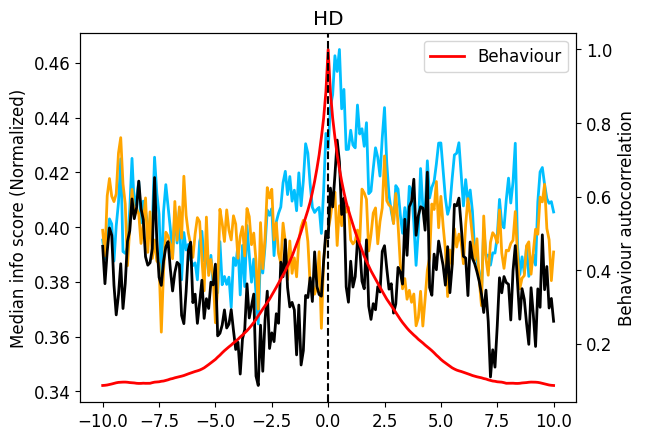

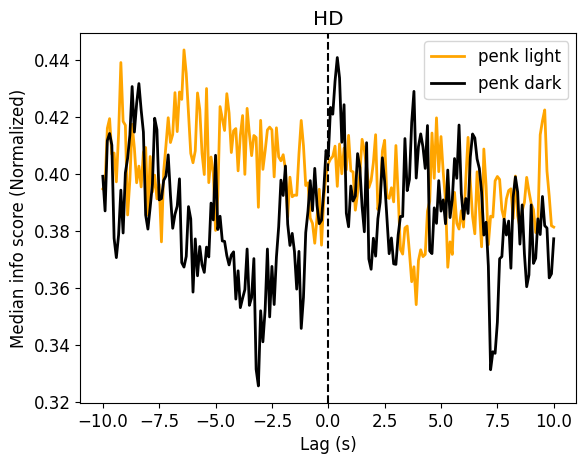

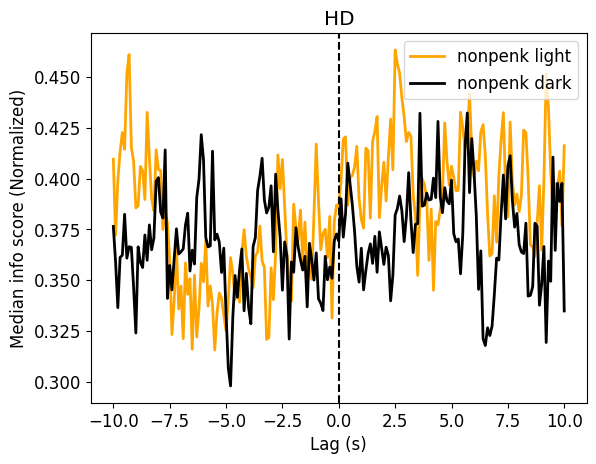

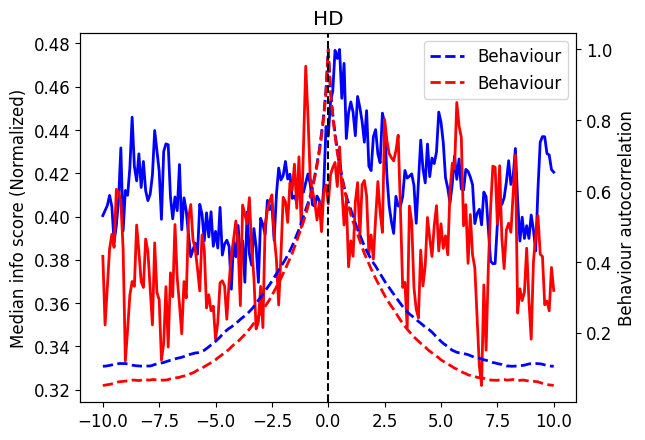

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


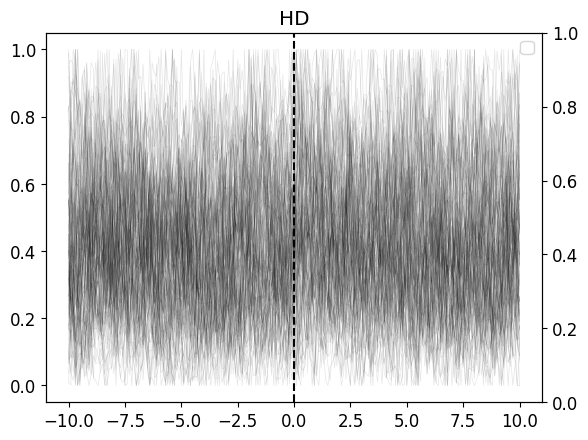

/Users/tristan/opt/miniconda3/envs/suite2p/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


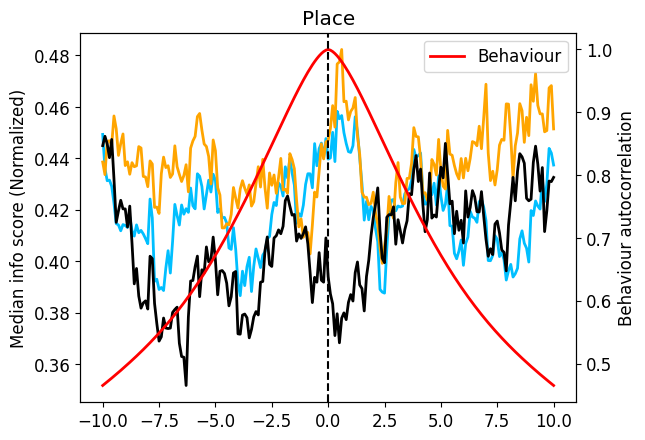

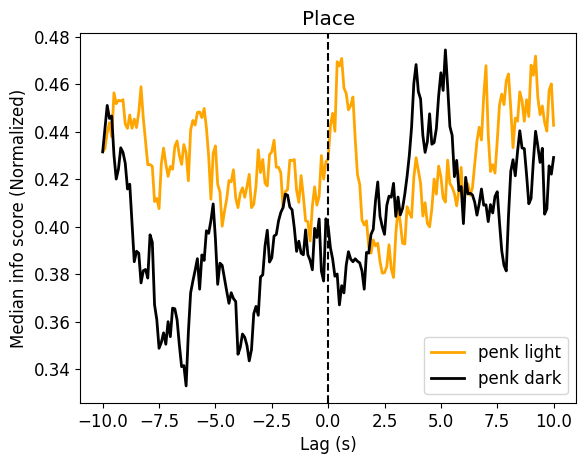

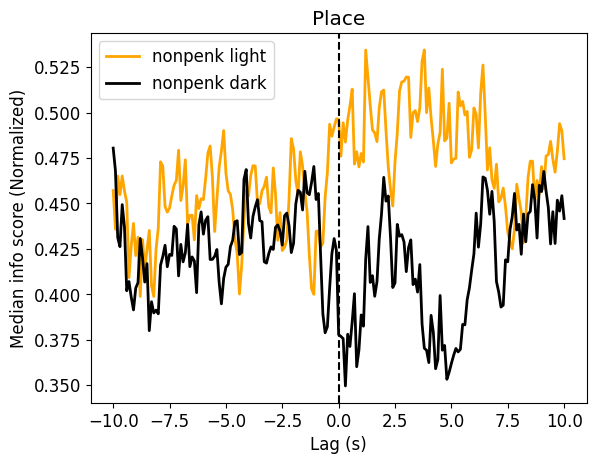

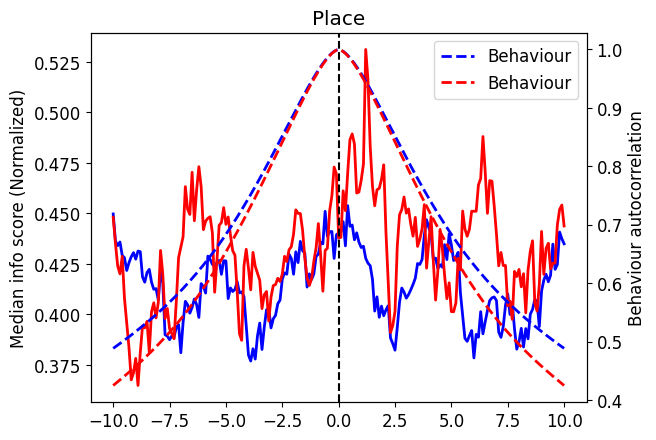

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


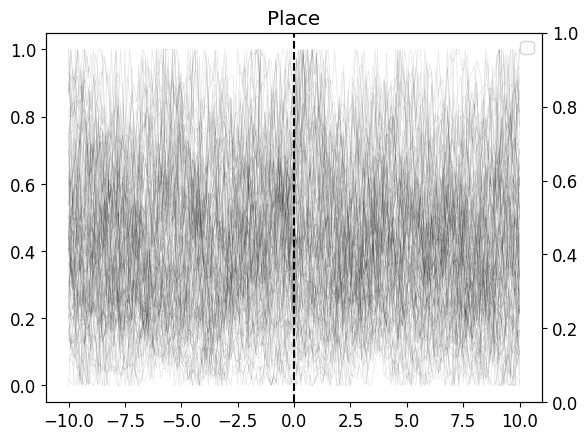

In [11]:
# Time lag analysis
lags = np.arange(-N_LAGS_FRAMES, N_LAGS_FRAMES+1)
behave_lag_dict = {}
plot_all = True
norm_95 = False

for bi in behave_infos:
    
    behave_name = bi.name
    
    comb_lag_info_matrix = None 
    light_lag_info_matrix = None 
    dark_lag_info_matrix = None
    diff_lag_info_matrix = None
    behave_lag_matrix = None
    
    comb_lag_info_penk = [] 
    light_lag_info_penk = [] 
    dark_lag_info_penk = []
    diff_lag_info_penk = []
    behave_lag_penk = []
    
    last_exp_id = None
    for (exp_id, roi_id) in lag_info_dict[behave_name]:
    
        
        # Look up the roi in df_roi
        roi_index = (df_roi['exp_id'] == exp_id) & \
                    (df_roi['roi_id'] == roi_id)
        roi_row = df_roi[roi_index]
        
        if exp_id != last_exp_id:
            # Look up this experiment in the df_behave
            behave_index = df_behave['exp_id'] == exp_id
            df_behave_exp = df_behave[behave_index]
            behave_lag_penk.append((roi_row["celltype"] == "penk").values[0])
            if not type(bi.bins) is tuple:
                behave_data = df_behave_exp[bi.colname].values
                # Do autocorrelation
                behave_lag = []
                for lag in lags:
                    behave_lag.append(np.corrcoef(behave_data, 
                                                  np.roll(behave_data, lag))[0, 1])
                behave_lag = np.array(behave_lag)
            else:
                behave_data1 = df_behave_exp[bi.colname[0]].values
                behave_data2 = df_behave_exp[bi.colname[1]].values
                behave_data = behave_data1 + 1j*behave_data2
                # Do autocorrelation
                behave_lag = []
                for lag in lags:
                    # bl1 = (np.corrcoef(behave_data1, np.roll(behave_data1, lag))[0, 1])
                    # bl2 = (np.corrcoef(behave_data2, np.roll(behave_data2, lag))[0, 1])
                    # behave_lag.append((bl1 + bl2) / 2)
                    behave_lag.append(np.corrcoef(behave_data, np.roll(behave_data, lag))[0, 1])
                behave_lag = np.array(behave_lag)
                
            if comb_lag_info_matrix is None:
                behave_lag_matrix = behave_lag
            else:
                behave_lag_matrix = np.vstack((behave_lag_matrix, behave_lag))

        (comb_lag, light_lag, dark_lag) = lag_info_dict[behave_name][(exp_id, roi_id)]
        
        comb_info_at_best_lag = roi_row[behave_info.name + '-MI'].values[0]
        comb_info_95 = roi_row[behave_info.name + '-MI-info-sig95'].values[0]
    
        light_info_at_best_lag = roi_row[behave_info.name + '-MI-info-light-best-lag'].values[0]
        light_info_95 = roi_row[behave_info.name + '-MI-info-light-sig95'].values[0]
 
        dark_info_at_best_lag = roi_row[behave_info.name + '-MI-info-dark-best-lag'].values[0]
        dark_info_95 = roi_row[behave_info.name + '-MI-info-dark-sig95'].values[0]
    
        if norm_95:
            comb_info_norm = comb_lag / comb_info_95
            light_info_norm = light_lag / light_info_95
            dark_info_norm = dark_lag / dark_info_95
            diff_info_norm = light_info_norm - dark_info_95
        else:
            comb_info_norm = (comb_lag - np.min(comb_lag)) / (np.max(comb_lag) - np.min(comb_lag))
            light_info_norm = (light_lag - np.min(light_lag)) / (np.max(light_lag) - np.min(light_lag))
            dark_info_norm = (dark_lag - np.min(dark_lag)) / (np.max(dark_lag) - np.min(dark_lag))
            diff_info_norm = (light_info_norm - dark_info_norm) / (np.max(light_info_norm) - np.min(light_info_norm))

        
        # # Smooth the lag traces with a gaussian filter
        # comb_info_norm = gaussian_filter1d(comb_info_norm, 3)
        # light_info_norm = gaussian_filter1d(light_info_norm, 3)
        # dark_info_norm = gaussian_filter1d(dark_info_norm, 3)
        # diff_info_norm = gaussian_filter1d(diff_info_norm, 3)
        
        if plot_all or (comb_info_at_best_lag > comb_info_95):
            if comb_lag_info_matrix is None:
                comb_lag_info_matrix = comb_info_norm
            else:
                comb_lag_info_matrix = np.vstack((comb_lag_info_matrix, comb_info_norm))
                
            comb_lag_info_penk.append((roi_row["celltype"] == "penk").values[0])
        
        if plot_all or (light_info_at_best_lag > light_info_95):
            if light_lag_info_matrix is None:
                light_lag_info_matrix = light_info_norm
            else:
                light_lag_info_matrix = np.vstack((light_lag_info_matrix, light_info_norm))
                
            light_lag_info_penk.append((roi_row["celltype"] == "penk").values[0])
        
        if plot_all or (dark_info_at_best_lag > dark_info_95):
            if dark_lag_info_matrix is None:
                dark_lag_info_matrix = dark_info_norm
            else:
                dark_lag_info_matrix = np.vstack((dark_lag_info_matrix, dark_info_norm))
                
            dark_lag_info_penk.append((roi_row["celltype"] == "penk").values[0])
                
        if plot_all or ((light_info_at_best_lag > light_info_95) and (dark_info_at_best_lag > dark_info_95)):
            if diff_lag_info_matrix is None:
                diff_lag_info_matrix = diff_info_norm
            else:
                diff_lag_info_matrix = np.vstack((diff_lag_info_matrix, diff_info_norm))
                
            diff_lag_info_penk.append((roi_row["celltype"] == "penk").values[0])
                
        last_exp_id = exp_id

    comb_lag_info_mean = np.mean(comb_lag_info_matrix, axis=0)
    light_lag_info_mean = np.mean(light_lag_info_matrix, axis=0)
    dark_lag_info_mean = np.mean(dark_lag_info_matrix, axis=0)
    diff_lag_info_mean = light_lag_info_mean - dark_lag_info_mean#np.mean(diff_lag_info_matrix, axis=0)
    
    penk_comb_lag_info_mean = np.mean(comb_lag_info_matrix[comb_lag_info_penk], axis=0)
    nonpenk_comb_lag_info_mean = np.mean(comb_lag_info_matrix[np.logical_not(comb_lag_info_penk)], axis=0)
    penk_light_lag_info_mean = np.mean(light_lag_info_matrix[light_lag_info_penk], axis=0)
    penk_dark_lag_info_mean = np.mean(dark_lag_info_matrix[dark_lag_info_penk], axis=0)
    nonpenk_light_lag_info_mean = np.mean(light_lag_info_matrix[np.logical_not(light_lag_info_penk)], axis=0)
    nonpenk_dark_lag_info_mean = np.mean(dark_lag_info_matrix[np.logical_not(dark_lag_info_penk)], axis=0)
    if behave_lag_matrix is not None:
        behave_lag_mean = np.mean(behave_lag_matrix, axis=0)
        penk_behave_lag_mean = np.mean(behave_lag_matrix[behave_lag_penk], axis=0)
        nonpenk_behave_lag_mean = np.mean(behave_lag_matrix[np.logical_not(behave_lag_penk)], axis=0)
    
    fig, ax1 = plt.subplots()
    ax1.plot(lags / TWOP_FPS,
             comb_lag_info_mean, 
             color=pu.COLOUR_TUNE_CURVE,
             linewidth=2,
             label='light & dark')
    ax1.plot(lags / TWOP_FPS,
             light_lag_info_mean, 
             color=pu.COLOUR_LIGHT,
             linewidth=2,
             label='light')
    ax1.plot(lags / TWOP_FPS,
             dark_lag_info_mean, 
             color=pu.COLOUR_DARK,
             linewidth=2,
             label='dark')
    ax1_right = ax1.twinx()
    if behave_lag_matrix is not None:
        ax1_right.plot(lags / TWOP_FPS,
                       behave_lag_mean, 
                       color='red',
                       linewidth=2,
                       label='Behaviour')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.xlabel("Lag (s)")
    ax1.set_ylabel("Median info score (Normalized)")
    ax1_right.set_ylabel("Behaviour autocorrelation")
    #plt.xlim(-2, 2)
    plt.title(behave_name)
    plt.legend()
    plt.show() 

    fig, ax1 = plt.subplots()
    ax1.plot(lags / TWOP_FPS,
             penk_light_lag_info_mean, 
             color=pu.COLOUR_LIGHT,
             linewidth=2,
             label='penk light')
    ax1.plot(lags / TWOP_FPS,
             penk_dark_lag_info_mean,
             color=pu.COLOUR_DARK,
             linewidth=2,
             label='penk dark')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.xlabel("Lag (s)")
    ax1.set_ylabel("Median info score (Normalized)")
    #plt.xlim(-2, 2)
    plt.title(behave_name)
    plt.legend()
    plt.show() 

    fig, ax1 = plt.subplots()
    ax1.plot(lags / TWOP_FPS,
             nonpenk_light_lag_info_mean, 
             color=pu.COLOUR_LIGHT,
             linewidth=2,
             label='nonpenk light')
    ax1.plot(lags / TWOP_FPS,
             nonpenk_dark_lag_info_mean,
             color=pu.COLOUR_DARK,
             linewidth=2,
             label='nonpenk dark')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.xlabel("Lag (s)")
    ax1.set_ylabel("Median info score (Normalized)")
    #plt.xlim(-2, 2)
    plt.title(behave_name)
    plt.legend()
    plt.show() 
    
    fig, ax1 = plt.subplots()
    ax1.plot(lags / TWOP_FPS,
             penk_comb_lag_info_mean, 
             color=pu.COLOR_PENK,
             linewidth=2,
             label='penk')
    # ax1.plot(lags / TWOP_FPS,
    #          np.transpose(comb_lag_info_matrix[comb_lag_info_penk]), 
    #          color=pu.COLOR_PENK,
    #          linewidth=0.1,
    #          label='penk')
    ax1.plot(lags / TWOP_FPS,
             nonpenk_comb_lag_info_mean, 
             color=pu.COLOR_NONPENK,
             linewidth=2,
             label='nonpenk')
    # ax1.plot(lags / TWOP_FPS,
    #          np.transpose(comb_lag_info_matrix[np.logical_not(comb_lag_info_penk)]), 
    #          color=pu.COLOR_NONPENK,
    #          linewidth=0.1,
    #          label='penk')
    ax1_right = ax1.twinx()
    if behave_lag_matrix is not None:
        ax1_right.plot(lags / TWOP_FPS,
                       penk_behave_lag_mean, 
                       color=pu.COLOR_PENK,
                       linewidth=2,
                       linestyle='--',
                       label='Behaviour')
        ax1_right.plot(lags / TWOP_FPS,
                       nonpenk_behave_lag_mean, 
                       color=pu.COLOR_NONPENK,
                       linewidth=2,
                       linestyle='--',
                       label='Behaviour')
    plt.axvline(x=0, color='black', linestyle='--')
    plt.xlabel("Lag (s)")
    ax1.set_ylabel("Median info score (Normalized)")
    ax1_right.set_ylabel("Behaviour autocorrelation")
    #plt.xlim(-5, 5)
    plt.title(behave_name)
    plt.legend()
    plt.show() 
    
    fig, ax1 = plt.subplots()
    plt.axvline(x=0, color='black', linestyle='--')
    ax1.plot(lags / TWOP_FPS,
             np.transpose(comb_lag_info_matrix[comb_lag_info_penk]), 
             color='k',
             alpha=0.1,
             linewidth=0.5,
             label='penk')
    ax1_right = ax1.twinx()
    # if behave_lag_matrix is not None:
    #     ax1_right.plot(lags / TWOP_FPS,
    #                    penk_behave_lag_mean, 
    #                    color=pu.COLOR_PENK,
    #                    linewidth=2,
    #                    linestyle='--',
    #                    label='Behaviour')
    # ax1.set_ylabel("Info score (% above 95% CI)")
    # ax1_right.set_ylabel("Behaviour autocorrelation")
    
    plt.xlabel("Lag (s)")
    
    #plt.xlim(-5, 5)
    plt.title(behave_name)
    plt.legend()
    plt.show()  
    
    behave_lag_matrix = None

# Plots

164
Percentage of True values for each column:
HD 12.804878048780488 HD-MI-is-sig-tuned 21
Place 14.02439024390244 Place-MI-is-sig-tuned 23
None: 76.8%
Place: 14.0%
HD: 12.8%


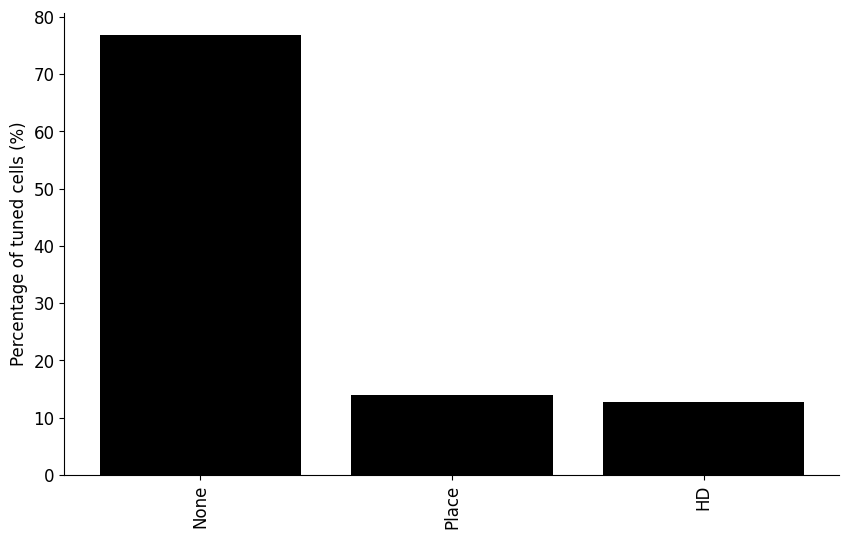

Percentage of True values for each column:

Percentage of rows for each combination of values (in descending order):
None: 76.8%
Place: 10.4%
HD: 9.1%
HD, Place: 3.7%


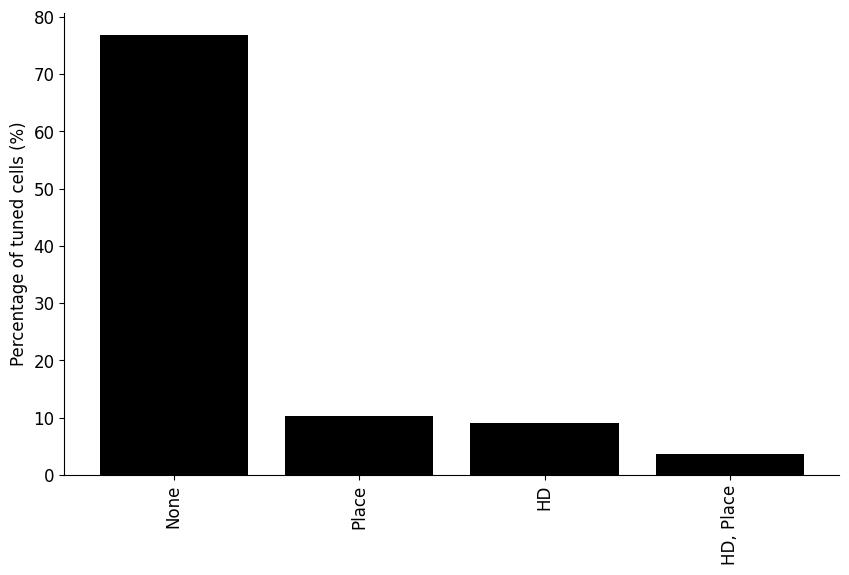

HD     Place
False  False    76.829268
       True     10.365854
True   False     9.146341
       True      3.658537
dtype: float64
All Intersections (as Percentages):


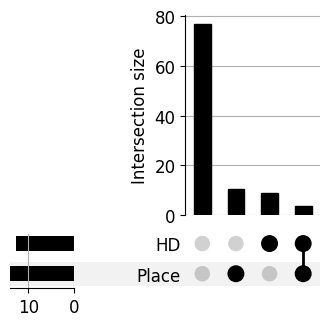


Top 10 Intersections (as Percentages):


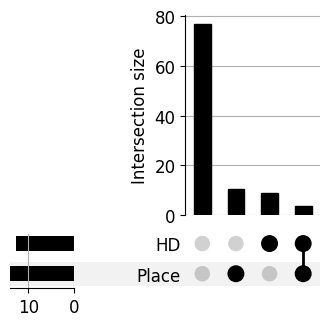

In [12]:

#behave_inc = ["HD", "Place"]
#behave_inc = ["HD", "Place", "Head-Speed", "AHV", "AHV-Abs", "Locomotion", "Heading-Ego", "Heading-Allo"]
# behave_inc = ["HD", "Place", "Place-NotSmoothed", "Place-Visit", "Speed-Head", "Locomotion", "Heading-Ego", "Heading-Allo", "AHV", "AHV-Abs",]
#behave_inc = ["HD", "Place", "Heading-Ego"]
behave_inc = ["HD", "Place"] #, "Locomotion", "Heading-Ego", "Heading-Allo"]
behave_sig_cols = []

penk_indexes = df_roi["celltype"] == "penk"
nonpenk_indexes = ~penk_indexes

#df_roi_types = df_roi[penk_indexes].copy(deep=True)
df_roi_types = df_roi.copy(deep=True)
print(df_roi_types.shape[0])

for bindex, bi in enumerate(behave_infos):

    if behave_inc and bi.name not in behave_inc:
        continue

    mi_col = bi.name + '-MI-info-no-lag'
    sig_col = bi.name + '-MI-info-sig95'
    is_sig_col = bi.name + '-MI-is-sig-tuned'
    inter_corr_col = bi.name + '-MI-corr-inter'
    half_corr_col = bi.name + '-MI-corr-half'
    inter_corr_p_col = bi.name + '-MI-corr-p-inter'
    half_corr_p_col = bi.name + '-MI-corr-p-half'
    inter_corr_lower_col = bi.name + '-MI-corr-inter-lower'
    half_corr_lower_col = bi.name + '-MI-corr-half-lower'
    mi_info_light_col = bi.name + '-MI-info-light'
    mi_info_dark_col = bi.name + '-MI-info-dark'
    mi_sig_light_col = bi.name + '-MI-info-light-sig95'
    mi_sig_dark_col = bi.name + '-MI-info-dark-sig95'

    behave_sig_cols.append((bi.name, is_sig_col))

    # is_sig = (df_roi_types[mi_col] > df_roi_types[sig_col]) & \
    #           (df_roi_types[inter_corr_lower_col] > 0)
    
    light_sig_indexes = (df_roi_types[mi_info_light_col] > df_roi_types[mi_sig_light_col]) #& (df_roi_types[inter_corr_lower_col] > 0)

    dark_sig_indexes = (df_roi_types[mi_info_dark_col] > df_roi_types[mi_sig_dark_col]) #& (df_roi_types[inter_corr_lower_col] > 0)

    comb_sig_indexes = (df_roi_types[mi_col] > df_roi_types[sig_col]) #& (df_roi_types[inter_corr_lower_col] > 0)

    
    # light_sig_indexes = (df_roi_types[mi_info_light_col] > df_roi_types[mi_sig_light_col])
    # 
    # dark_sig_indexes = (df_roi_types[mi_info_dark_col] > df_roi_types[mi_sig_dark_col]) 
    # 
    # comb_sig_indexes = (df_roi_types[mi_col] > df_roi_types[sig_col])
    
    is_sig =  comb_sig_indexes | light_sig_indexes | dark_sig_indexes
    
    df_roi_types[is_sig_col] = is_sig

#  Step 1: Calculate the percentage of True values for each column in behave_sig_cols
print("Percentage of True values for each column:")

# Create a dictionary to store the column percentages
column_percents = {"None": 0}  # Start with "None" at 0%

for name, col in behave_sig_cols:
    perc_true = df_roi_types[col].mean() * 100  # mean of boolean series gives the percentage of True values
    print(name, perc_true, col, df_roi_types[col].sum())
    column_percents[name] = perc_true

# Calculate the "None" case where all columns are False
column_percents["None"] = (df_roi_types[[col for _, col in behave_sig_cols]].sum(axis=1) == 0).mean() * 100


# Sort by percentage in descending order and print
for name, perc in sorted(column_percents.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {perc:.1f}%")

# Sort by percentage in descending order
sorted_percents = sorted(column_percents.items(), key=lambda x: x[1], reverse=True)

# Prepare data for plotting
names, percents = zip(*sorted_percents)  # unzip the list of tuples

# Plot
plt.figure(figsize=(10,6))
plt.bar(names, percents, color='black')
plt.ylabel('Percentage of tuned cells (%)')
plt.xticks(rotation=90)  # rotate x-axis labels for better readability
plt.gca().spines[['right', 'top']].set_visible(False)
plot_path = cfg.sum_plot_path / "tuning-single-{}.png".format(RESPONSE_TYPE)
plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
plt.show()

# Step 2: Generate all possible permutations of True and False for the number of behave_sig_cols
# and compare with our DataFrame to calculate the percentages for each unique combination.

# Create an empty dictionary to store counts of each permutation
perm_counts = {}

# Get all permutations
perms = itertools.product([False, True], repeat=len(behave_sig_cols))

for perm in perms:
    # Create a mask for rows matching the current permutation
    mask = (df_roi_types[[col for _, col in behave_sig_cols]] == perm).all(axis=1)

    # Identify the friendly names that are True
    true_cols = [name for (name, col), val in zip(behave_sig_cols, perm) if val]
    true_cols = ', '.join(true_cols) if true_cols else 'None'

    # Count the number of matching rows and store in the dictionary
    perm_counts[true_cols] = mask.sum()

# Convert counts to percentages
total_rows = df_roi_types.shape[0]
perm_perc = {perm: (count / total_rows) * 100 for perm, count in perm_counts.items()}

# Step 1: Calculate the percentage of True values for each column in behave_sig_cols
print("Percentage of True values for each column:")

# Create a dictionary to store the column percentages
column_percents = perm_perc  # Now use perm_perc instead of calculating again

# Sort by percentage in descending order and print
print("\nPercentage of rows for each combination of values (in descending order):")
for perm, perc in sorted(perm_perc.items(), key=lambda x: x[1], reverse=True):
    # Skip if percentage is zero
    if perc == 0:
        continue
    print(f"{perm}: {perc:.1f}%")

    # Sort by percentage in descending order
sorted_percents = sorted(column_percents.items(), key=lambda x: x[1], reverse=True)

# Prepare data for plotting
names, percents = zip(*sorted_percents)  # unzip the list of tuples

# Plot
plt.figure(figsize=(10,6))
plt.bar(names, percents, color='black')
plt.ylabel('Percentage of tuned cells (%)')
#plt.xlabel('Behavioural measure')
plt.xticks(rotation=90)  # rotate x-axis labels for better readability
plt.gca().spines[['right', 'top']].set_visible(False)
plt.show()


## Plot
# Step 1: Prepare a DataFrame for upsetplot
df_upset = pd.DataFrame(index=df_roi_types.index)

for name, col in behave_sig_cols:
    df_upset[name] = df_roi_types[col]

# Ensure boolean type
df_upset = df_upset.astype(bool)

# Step 2: Convert DataFrame to intersection format and calculate percentages
intersections = df_upset.groupby(list(df_upset.columns)).size()
intersections_percentage = (intersections / intersections.sum()) * 100  # Convert counts to percentage
print(intersections_percentage)

# Step 3: Plot with upsetplot all intersections (now as percentages)
print("All Intersections (as Percentages):")
plot(intersections_percentage, sort_by="cardinality")
plt.gca().spines[['right', 'top']].set_visible(False)
plot_path = cfg.sum_plot_path / f"tuning-upset-{RESPONSE_TYPE}.png"
plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
plt.show()

# Step 4: Select top 10 intersections by cardinality (now as percentages)
top_10_intersections_percentage = intersections_percentage.sort_values(ascending=False).head(10)

# Step 5: Plot with upsetplot only the top 10 intersections (as percentages)
print("\nTop 10 Intersections (as Percentages):")
plot(top_10_intersections_percentage, sort_by="cardinality")
plt.show()



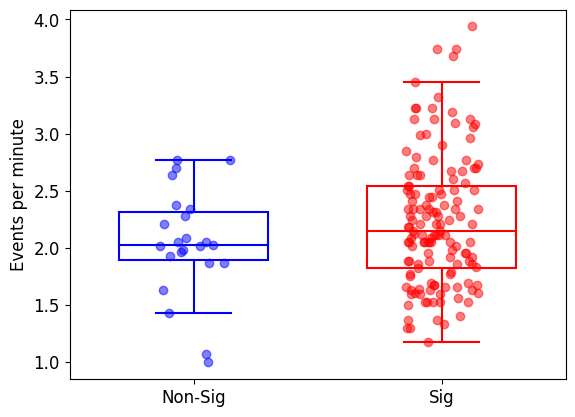

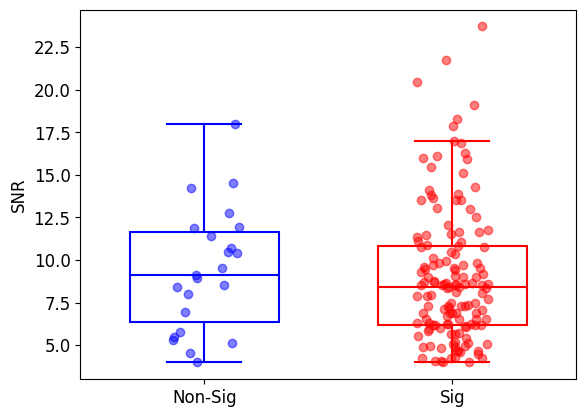

Text(0, 0.5, 'SNR')

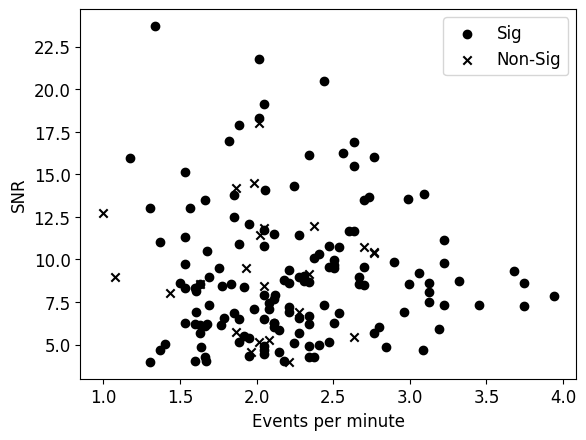

In [16]:
# Try and track down which cells have no tuning.

nonsig_roi_indexes = df_roi_types[[col for _, col in behave_sig_cols]].sum(axis=1) == 0
sig_roi_indexes = np.logical_not(nonsig_roi_indexes)

# Calculate the percentage of significant cells per animal

# Check if SNR or event rate causes non sig tuning.
pu.plot_box_celltype(df_roi_types,
                     nonsig_roi_indexes,
                     sig_roi_indexes,
                     col_name='events_per_min',
                     plot_label='Events per minute',
                     labels=["Non-Sig", "Sig"])

pu.plot_box_celltype(df_roi_types,
                     nonsig_roi_indexes,
                     sig_roi_indexes,
                     col_name='snr',
                     plot_label='SNR',
                     labels=["Non-Sig", "Sig"])
                     
                    
plt.figure()
plt.scatter(df_roi_types.loc[sig_roi_indexes, 'events_per_min'],
            df_roi_types.loc[sig_roi_indexes, 'snr'],
            marker='o', label='Sig', color='k')
plt.scatter(df_roi_types.loc[nonsig_roi_indexes, 'events_per_min'],
            df_roi_types.loc[nonsig_roi_indexes, 'snr'],
            marker='x', label='Non-Sig', color='k')
plt.legend()
plt.xlabel('Events per minute')
plt.ylabel('SNR')

#TODO: show place visit info - i'ts temporal so should be a good indicator of failed tuning

#TODO: loop through behave info and show stabiluty measures



In [17]:


# for i, behave_info in enumerate(behave_infos):
#
#     mi_info_lag_col = behave_info.name + '-MI'
#     mi_info_col = behave_info.name + '-MI-info-no-lag'
#     mi_sig_col = behave_info.name + '-MI-info-sig'
#     mi_latency_col = behave_info.name + '-MI-lag-time'
#     mi_info_light_col = behave_info.name + '-MI-info-light'
#     mi_info_dark_col = behave_info.name + '-MI-info-dark'
#     mi_info_inter1_col = behave_info.name + '-MI-info-inter1'
#     mi_info_inter2_col = behave_info.name + '-MI-info-inter2'
#     mi_info_half1_col = behave_info.name + '-MI-info-half1'
#     mi_info_half2_col = behave_info.name + '-MI-info-half2'
#     mi_corr_light_col = behave_info.name + '-MI-corr-light'
#     mi_corr_half_col = behave_info.name + '-MI-corr-half'
#     mi_corr_inter_col = behave_info.name + '-MI-corr-inter'
#     mi_corr_interlag_col = behave_info.name + '-MI-corr-inter-lag'
#
#     mi_corr_p_light_col = behave_info.name + '-MI-corr-p-light'
#     mi_corr_p_half_col = behave_info.name + '-MI-corr-p-half'
#     mi_corr_p_inter_col = behave_info.name + '-MI-corr-p-inter'
#     mi_corr_p_interlag_col = behave_info.name + '-MI-corr-p-inter-lag'
#
#     mi_infodiff_sig_col = behave_info.name + '-MI-infodiff-sig'
#     mi_infodiff_light_col = behave_info.name + '-MI-infodiff-light'
#     mi_infodiff_half_col = behave_info.name + '-MI-infodiff-half'
#     mi_infodiff_inter_col = behave_info.name + '-MI-infodiff-inter'
#     mi_corrdiff_inter_col = behave_info.name + '-MI-corrdiff-inter'
#
#     df_roi[mi_infodiff_sig_col] = df_roi[mi_info_col] - df_roi[mi_sig_col]
#     df_roi[mi_infodiff_light_col] = df_roi[mi_info_light_col] - df_roi[mi_info_dark_col]
#     df_roi[mi_infodiff_half_col] = df_roi[mi_info_half2_col] - df_roi[mi_info_half1_col]
#     df_roi[mi_infodiff_inter_col] = df_roi[mi_info_inter1_col] - df_roi[mi_info_inter2_col]
#     df_roi[mi_corrdiff_inter_col] = df_roi[mi_corr_interlag_col] - df_roi[mi_corr_inter_col]
#
#
#     # todo stats like this
#     # groups = df_roi.groupby('celltype')[mi_col]
#     # result = ranksums(groups.get_group('penk'), groups.get_group('nonpenk'))
#     # print("Penk vs non penk {} ".format(mi_col), result)
#
#
#     sig_indexes = df_roi[mi_info_col] > df_roi[mi_sig_col]
#     sig_penk_indexes = sig_indexes & penk_indexes
#     sig_nonpenk_indexes = sig_indexes & nonpenk_indexes
#
#     penk_percent = np.sum(sig_penk_indexes == True) / n_penk
#     nonpenk_percent = np.sum(sig_nonpenk_indexes == True) / n_nonpenk
#
#     print(behave_info.name, "sig", penk_percent, nonpenk_percent)
#
#     # Significant cells only
#     pu.plot_box_celltype(df_roi,
#                          sig_penk_indexes,
#                          sig_nonpenk_indexes,
#                          col_name=mi_info_col,
#                          plot_label=behave_info.name + '_MI')
#
#     pu.plot_box_celltype(df_roi,
#                          sig_penk_indexes,
#                          sig_nonpenk_indexes,
#                          col_name=mi_corr_light_col,
#                          plot_label=behave_info.name + '_Light_Corr')
#
#     pu.plot_box_celltype(df_roi,
#                          sig_penk_indexes,
#                          sig_nonpenk_indexes,
#                          col_name=mi_corr_half_col,
#                          plot_label=behave_info.name + '_Half_Corr')
#
#     pu.plot_box_celltype(df_roi,
#                          sig_penk_indexes,
#                          sig_nonpenk_indexes,
#                          col_name=mi_corr_p_half_col,
#                          plot_label=behave_info.name + '_Half_Corr_P')
#
#     pu.plot_box_celltype(df_roi,
#                          sig_penk_indexes,
#                          sig_nonpenk_indexes,
#                          col_name=mi_corr_inter_col,
#                          plot_label=behave_info.name + '_Inter_Corr')
#
#     pu.plot_box_celltype(df_roi,
#                          sig_penk_indexes,
#                          sig_nonpenk_indexes,
#                          col_name=mi_corr_p_inter_col,
#                          plot_label=behave_info.name + '_Inter_Corr_P')
#
#     pu.plot_box_celltype(df_roi,
#                          sig_penk_indexes,
#                          sig_nonpenk_indexes,
#                          col_name=mi_latency_col,
#                          plot_label=behave_info.name + '_Latency')
#
#
#     # All cells
#     pu.plot_box_celltype(df_roi,
#                          penk_indexes,
#                          nonpenk_indexes,
#                          col_name=mi_info_col,
#                          plot_label=behave_info.name + '_MI')
#
#     pu.plot_box_celltype(df_roi,
#                          penk_indexes,
#                          nonpenk_indexes,
#                          col_name=mi_corr_light_col,
#                          plot_label=behave_info.name + '_Light_Corr')
#
#     pu.plot_box_celltype(df_roi,
#                          penk_indexes,
#                          nonpenk_indexes,
#                          col_name=mi_infodiff_light_col,
#                          plot_label=behave_info.name + '_Light_InfoDiff')
#
#     pu.plot_box_celltype(df_roi,
#                          penk_indexes,
#                          nonpenk_indexes,
#                          col_name=mi_corr_half_col,
#                          plot_label=behave_info.name + '_Half_Corr')
#
#     pu.plot_box_celltype(df_roi,
#                          penk_indexes,
#                          nonpenk_indexes,
#                          col_name=mi_infodiff_half_col,
#                          plot_label=behave_info.name + '_Half_InfoDiff')
#
#     pu.plot_box_celltype(df_roi,
#                          penk_indexes,
#                          nonpenk_indexes,
#                          col_name=mi_corr_inter_col,
#                          plot_label=behave_info.name + '_Inter_Corr')
#
#     pu.plot_box_celltype(df_roi,
#                          penk_indexes,
#                          nonpenk_indexes,
#                          col_name=mi_infodiff_inter_col,
#                          plot_label=behave_info.name + '_Inter_InfoDiff')
#
#     pu.plot_box_celltype(df_roi,
#                          penk_indexes,
#                          nonpenk_indexes,
#                          col_name=mi_latency_col,
#                          plot_label=behave_info.name + '_Latency')
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_info_lag_col,
#              mi_info_col,
#              "Zero lag",
#              "Best lag",
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_info_light_col,
#              mi_info_dark_col,
#              "Light info",
#              "Dark info",
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_info_half1_col,
#              mi_info_half2_col,
#              "First half info",
#              "Second half info",
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_info_inter1_col,
#              mi_info_inter2_col,
#              "Inter1 info",
#              "Inter2 info",
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_corr_inter_col,
#              mi_corr_half_col,
#              "Inter corr",
#              "Half corr",
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_corr_light_col,
#              mi_corr_half_col,
#              "Light corr",
#              "Half corr",
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_corr_light_col,
#              mi_infodiff_light_col,
#              "Light corr",
#              "Light info diff",
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_corr_half_col,
#              mi_infodiff_half_col,
#              "Half corr",
#              "Half info diff",
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_info_lag_col,
#              mi_sig_col,
#              "Info lag",
#              "Info sig",
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_info_col,
#              mi_sig_col,
#              "Info",
#              "Info sig",
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_infodiff_sig_col,
#              mi_corr_inter_col,
#              "Info sig",
#              "Inter corr",
#              square=False,
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              penk_indexes,
#              nonpenk_indexes,
#              mi_corr_inter_col,
#              mi_corr_interlag_col,
#              "Inter corr",
#              "Inter corr lag",
#              square=True,
#              title=behave_info.name)
#
#     inf_scat(df_roi,
#              sig_penk_indexes,
#              sig_nonpenk_indexes,
#              mi_infodiff_half_col,
#              mi_infodiff_light_col,
#              "Half diff",
#              "Light diff",
#              square=True,
#              title=behave_info.name)
#
#






n Penk=119 non-Penk=45
HD
sig_n=126
sig_n_penk=94 (119)
[[94 25]
 [32 13]]
HD sig 0.7899159663865546 0.7111111111111111 p=0.390
Penk vs non penk HD  RanksumsResult(statistic=0.8126012894494897, pvalue=0.41644669203951523)
Penk vs non penk light/darkHD  RanksumsResult(statistic=0.7315254238354817, pvalue=0.46445828125239763)
Penk vs non penk light/dark 2-normHD  RanksumsResult(statistic=2.1503530720806223, pvalue=0.031527297349287484)
Penk vs non penk peak HD  RanksumsResult(statistic=-0.4551304274240906, pvalue=0.6490154089510232)


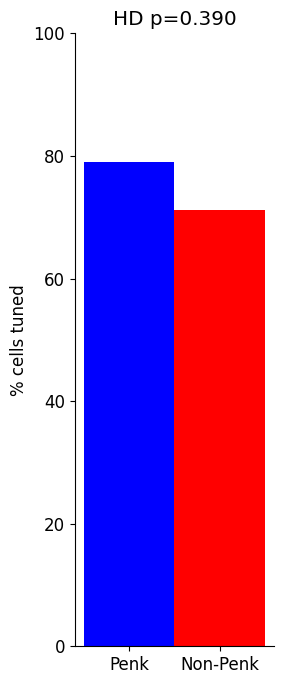

31 24 54 109 126
[28.440366972477065, 22.01834862385321, 49.54128440366973]


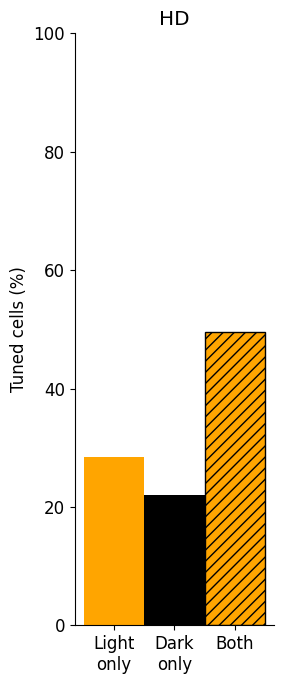

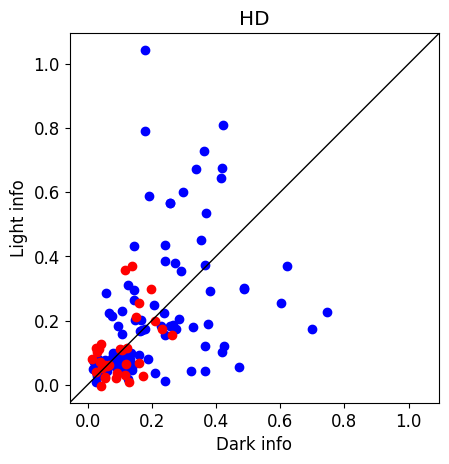

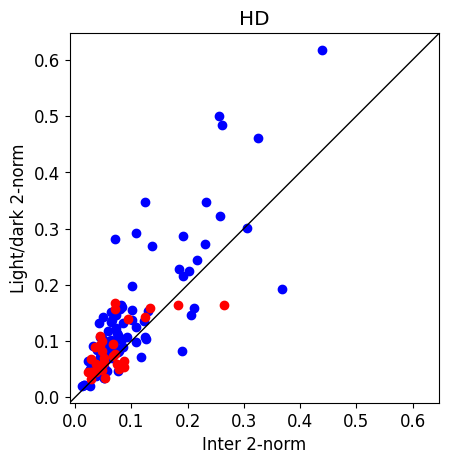

Wilcoxon WilcoxonResult(statistic=170.0, pvalue=8.250373577552131e-07) 0.032085157662159955


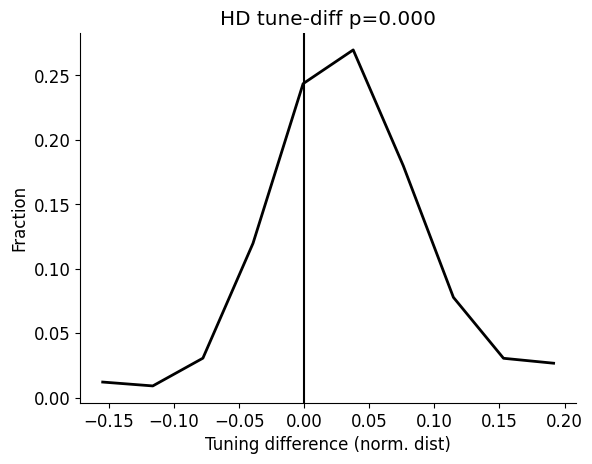

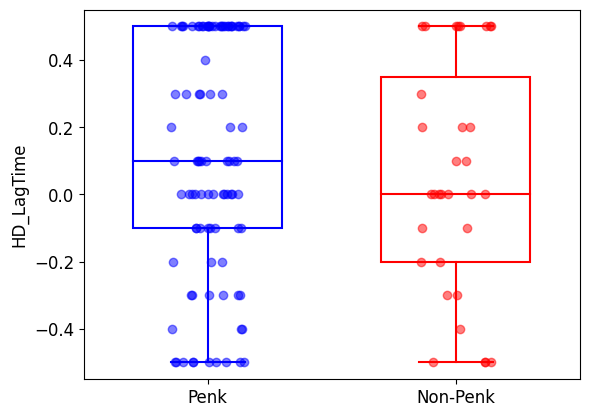

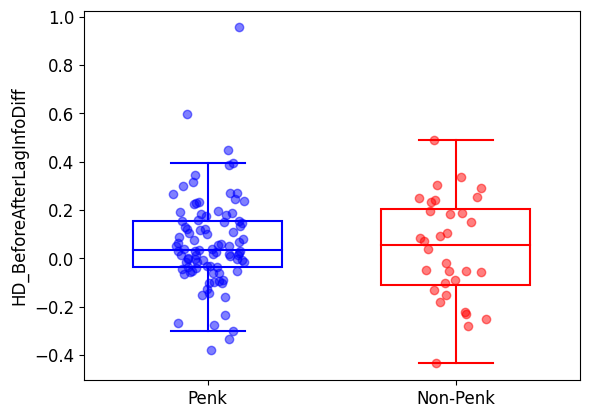

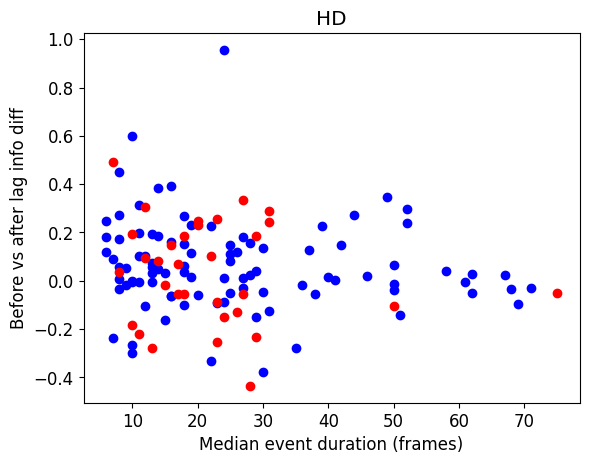

Place
sig_n=128
sig_n_penk=96 (119)
[[96 23]
 [32 13]]
Place sig 0.8067226890756303 0.7111111111111111 p=0.268
Penk vs non penk Place  RanksumsResult(statistic=0.98949408715278, pvalue=0.32242146138363326)
Penk vs non penk light/darkPlace  RanksumsResult(statistic=0.7499517569295744, pvalue=0.453283760868075)
Penk vs non penk light/dark 2-normPlace  RanksumsResult(statistic=0.17873543101269954, pvalue=0.858145447210249)
Penk vs non penk peak Place  RanksumsResult(statistic=0.2524407633890705, pvalue=0.8007003955008579)


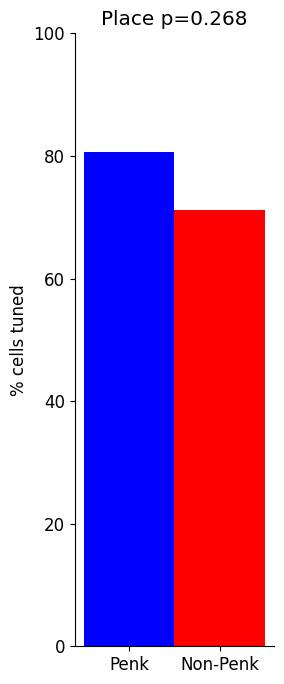

36 30 47 113 128
[31.858407079646017, 26.548672566371682, 41.5929203539823]


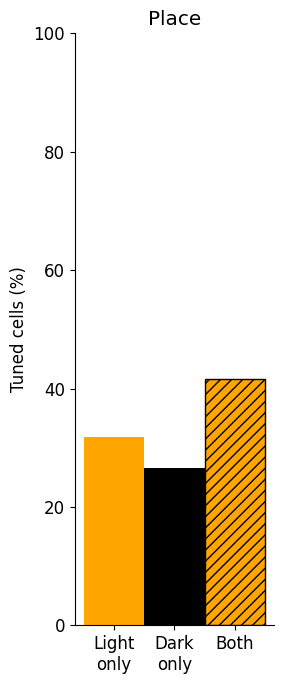

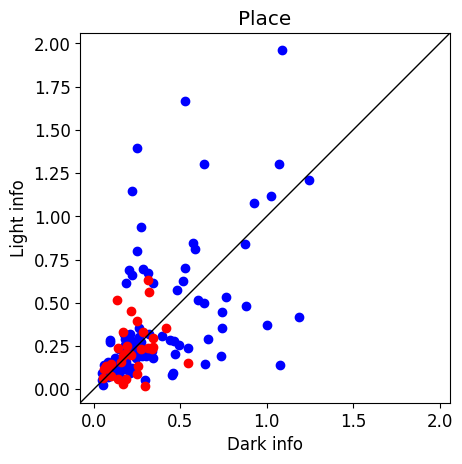

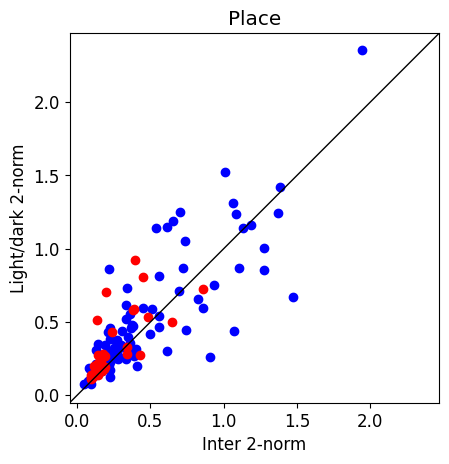

Wilcoxon WilcoxonResult(statistic=513.0, pvalue=0.5962626683115957) 0.02759548574085799


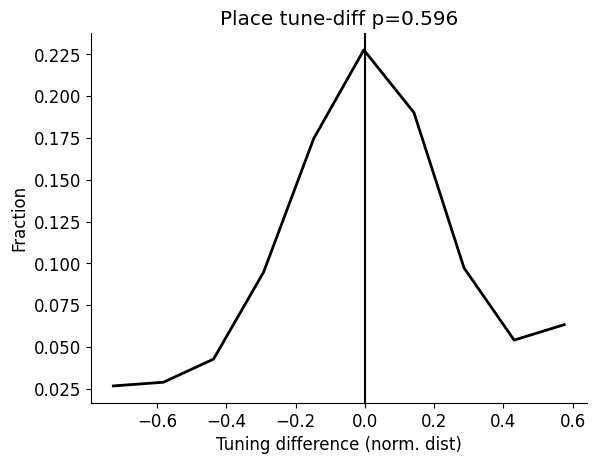

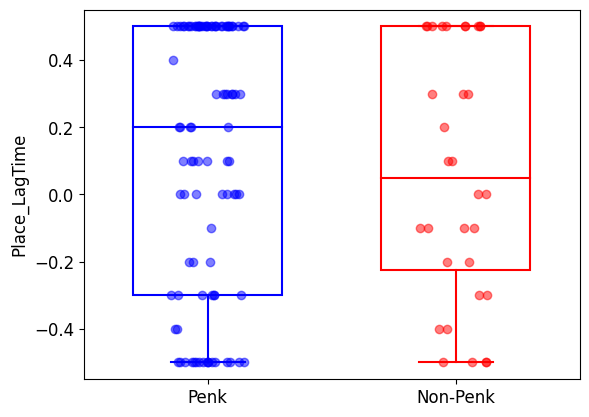

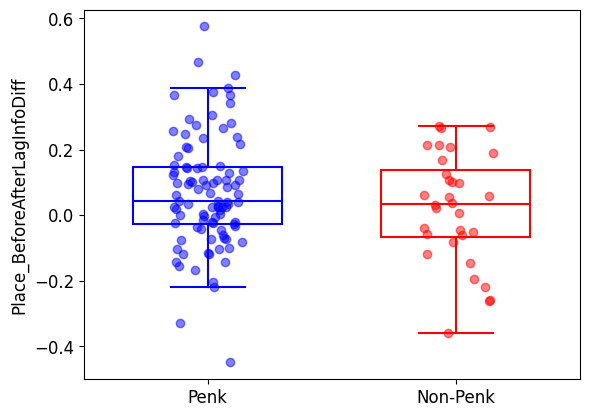

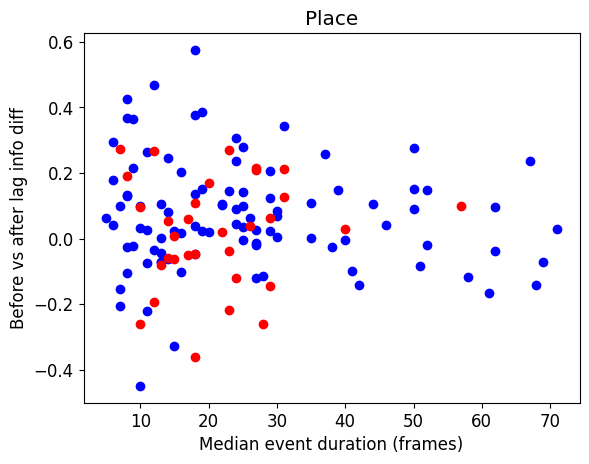

In [18]:
# Penk vs non penk
behave_inc = ["HD", "Place", "Heading-Ego", "Heading-Allo", "Locomotion"]

penk_indexes = df_roi["celltype"] == "penk"
nonpenk_indexes = ~penk_indexes

n_penk = np.sum(penk_indexes)
n_nonpenk = np.sum(nonpenk_indexes)

print("n Penk={} non-Penk={}".format(n_penk, n_nonpenk))

def inf_scat(df,
             penk_indexes,
             nonpenk_indexes,
             colname_1,
             colname_2,
             xlab,
             ylab,
             square=True,
             title=None):

    plt.figure()

    plt.scatter(df.loc[penk_indexes][colname_1],
                df.loc[penk_indexes][colname_2],
                color=pu.COLOR_PENK, label="penk")
    plt.scatter(df.loc[nonpenk_indexes][colname_1],
                df.loc[nonpenk_indexes][colname_2],
                color=pu.COLOR_NONPENK, label="nonpenk")

    if square:
        pu.square_plot()
    if title:
        plt.title(title)

    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.show()
    
def inf_diff_hist(df,
                  colname_1,
                  colname_2,
                  xlab,
                  behave_name,
                  measure_name,
                  diff_col=None):
    
    if diff_col is None:
        diffs = df[colname_1] - df[colname_2]
    else:
        diffs = df[diff_col]
    
    result = wilcoxon(diffs)
    
    # Plot the histogram with bars (using weights to make it a fraction)
    print("Wilcoxon", result, np.median(diffs))

    weights = np.ones_like(diffs) / float(len(diffs))
    y, x = np.histogram(diffs, bins=10, weights=weights)
    x = (x[:-1] + x[1:]) / 2  # Convert bin edges to centers
    
    # Smooth the histogram outline
    y_smooth = gaussian_filter1d(y, sigma=1.0)
    #y_smooth = y
    
    # Plot the smoothed outline
    plt.plot(x, y_smooth, color='black', linewidth=2)
    
    # Plot a solid vertical line at zero
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
    
    plt.xlabel(xlab)
    plt.ylabel("Fraction")
    plt.title(behave_name + " " + measure_name + " p={:.3f}".format(result.pvalue))
    plt.gca().spines[['right', 'top']].set_visible(False)
    plot_path = cfg.sum_plot_path / "diffs-{}-vs-{}-{}-{}-hist.png".format(colname_1,
                                                                           colname_2,
                                                                           RESPONSE_TYPE, 
                                                                           behave_name,
                                                                           measure_name)
    plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
    plt.show()

for i, behave_info in enumerate(behave_infos):

    print(behave_info.name)
    if behave_info.name not in behave_inc:
        continue
    mi_info_col = behave_info.name + '-MI-info-no-lag'
    mi_info_lag_col = behave_info.name + '-MI'
    mi_sig_col = behave_info.name + '-MI-info-sig95'
    
    mi_lag_time = behave_info.name + '-MI-lag-time'
    
    mi_info_light_col = behave_info.name + '-MI-info-light'
    mi_info_dark_col = behave_info.name + '-MI-info-dark'
    mi_corr_light_col = behave_info.name + '-MI-corr-light'
    mi_sig_light_col = behave_info.name + '-MI-info-light-sig95'
    mi_sig_dark_col = behave_info.name + '-MI-info-dark-sig95'

    mi_corr_inter_col = behave_info.name + '-MI-corr-inter'
    mi_corr_inter_p_col= behave_info.name + '-MI-corr-p-inter'
    mi_corr_inter_low_col = behave_info.name + '-MI-corr-inter-lower'
    
    mi_corr_half_col = behave_info.name + '-MI-corr-half'
    mi_corr_half_p_col= behave_info.name + '-MI-corr-p-half'
    mi_corr_half_low_col = behave_info.name + '-MI-corr-half-lower'

    mi_infoprc_sig_col = behave_info.name + '-MI-info-sig-prc'
    mi_infoprc_sig_light_col = behave_info.name + '-MI-info-sig-prc-light'
    mi_infoprc_sig_dark_col = behave_info.name + '-MI-info-sig-prc-dark'
    mi_info_lightdark_diff_col = behave_info.name + '-MI-info-light-dark-diff'
    mi_info_lightdark_ratio_col = behave_info.name + '-MI-info-light-dark-ratio'
    mi_info_lightdark_index_col = behave_info.name + '-MI-info-light-dark-index'
    
    mi_peak1_col = behave_info.name + '-MI-peak1-no-lag'
    mi_peak2_col = behave_info.name + '-MI-peak2-no-lag'
    
    mi_twonorm_light_col = behave_info.name + '-MI-twonorm_light'
    mi_twonorm_scale_light_col = behave_info.name + '-MI-twonorm_light_scale'
    mi_twonorm_norm_light_col = behave_info.name + '-MI-twonorm_light_norm'
    mi_twonorm_inter_col = behave_info.name + '-MI-twonorm_inter'
    mi_twonorm_scale_inter_col = behave_info.name + '-MI-twonorm_inter_scale'
    mi_twonorm_norm_inter_col = behave_info.name + '-MI-twonorm_inter_norm'

    mi_twonorm_light_inter_col = behave_info.name + '-MI-twonorm_light-inter'
    mi_twonorm_scale_light_inter_col = behave_info.name + '-MI-twonorm_light_scale-inter'
    mi_twonorm_norm_light_inter_col = behave_info.name + '-MI-twonorm_light_norm-inter'
    
    mi_lag_info_before_mean = behave_info.name + '-MI-lag-info-before-mean'
    mi_lag_info_after_mean = behave_info.name + '-MI-lag-info-after-mean'
    mi_lag_info_light_before_mean = behave_info.name + '-MI-lag-info-light-before-mean'
    mi_lag_info_light_after_mean = behave_info.name + '-MI-lag-info-light-after-mean'
    mi_lag_info_dark_before_mean = behave_info.name + '-MI-lag-info-dark-before-mean'
    mi_lag_info_dark_after_mean = behave_info.name + '-MI-lag-info-dark-after-mean'
    
    mi_lag_before_after_diff = behave_info.name + '-MI-lag-before-after-diff'
    mi_lag_light_before_after_diff = behave_info.name + '-MI-lag-light-before-after-diff'
    mi_lag_dark_before_after_diff = behave_info.name + '-MI-lag-dark-before-after-diff'
    

    df_roi[mi_lag_before_after_diff] = df_roi[mi_lag_info_after_mean]/df_roi[mi_sig_col] - df_roi[mi_lag_info_before_mean]/df_roi[mi_sig_col]
    df_roi[mi_lag_light_before_after_diff] = df_roi[mi_lag_info_light_after_mean]/df_roi[mi_sig_light_col] - df_roi[mi_lag_info_light_before_mean]/df_roi[mi_sig_light_col]
    df_roi[mi_lag_dark_before_after_diff] = df_roi[mi_lag_info_dark_after_mean]/df_roi[mi_sig_dark_col] - df_roi[mi_lag_info_dark_before_mean]/df_roi[mi_sig_dark_col]

    df_roi[mi_twonorm_light_inter_col] = df_roi[mi_twonorm_light_col] - df_roi[mi_twonorm_inter_col]
    df_roi[mi_twonorm_scale_light_inter_col] = df_roi[mi_twonorm_scale_light_col] - df_roi[mi_twonorm_scale_inter_col]
    df_roi[mi_twonorm_norm_light_inter_col] = df_roi[mi_twonorm_norm_light_col] - df_roi[mi_twonorm_norm_inter_col]

    light_sig_indexes = (df_roi[mi_info_light_col] > df_roi[mi_sig_light_col])# & (df_roi[mi_corr_inter_low_col] > 0)
    dark_sig_indexes = (df_roi[mi_info_dark_col] > df_roi[mi_sig_dark_col]) #& (df_roi[mi_corr_inter_low_col] > 0)
    comb_sig_indexes = (df_roi[mi_info_col] > df_roi[mi_sig_col])# & (df_roi[mi_corr_inter_low_col] > 0)
    sig_ld_all_indexes =  comb_sig_indexes | light_sig_indexes | dark_sig_indexes
    
    # lag_light_sig_indexes = (df_roi[mi_info_light_col] > df_roi[mi_sig_light_col])
    # lag_dark_sig_indexes = (df_roi[mi_info_dark_col] > df_roi[mi_sig_dark_col]) 
    lag_comb_sig_indexes = (df_roi[mi_info_lag_col] > df_roi[mi_sig_col])
    sig_lag_ld_all_indexes =  comb_sig_indexes #| light_sig_indexes | dark_sig_indexes
    
    sig_indexes = sig_ld_all_indexes
    sig_lag_indexes = sig_lag_ld_all_indexes                   

    sig_penk_indexes = sig_indexes & penk_indexes
    sig_nonpenk_indexes = sig_indexes & nonpenk_indexes
    
    sig_lag_penk_indexes = sig_lag_indexes & penk_indexes
    sig_lag_nonpenk_indexes = sig_lag_indexes & nonpenk_indexes

    sig_n = np.sum(sig_indexes)
    print("sig_n={}".format(sig_n))
    print("sig_n_penk={} ({})".format(np.sum(sig_penk_indexes == True), n_penk))
    penk_percent = np.sum(sig_penk_indexes == True) / n_penk
    nonpenk_percent = np.sum(sig_nonpenk_indexes == True) / n_nonpenk

    df_roi[mi_infoprc_sig_col] = (df_roi[mi_info_col] - df_roi[mi_sig_col]) / df_roi[mi_sig_col]
    df_roi[mi_infoprc_sig_light_col] = (df_roi[mi_info_light_col] - df_roi[mi_sig_col]) / df_roi[mi_sig_col]
    df_roi[mi_infoprc_sig_dark_col] = (df_roi[mi_info_dark_col] - df_roi[mi_sig_col]) / df_roi[mi_sig_col]
    
    df_roi[mi_info_lightdark_diff_col] = df_roi[mi_info_light_col] - df_roi[mi_info_dark_col]
    df_roi[mi_info_lightdark_ratio_col] = df_roi[mi_info_light_col] / df_roi[mi_info_dark_col]
    df_roi[mi_info_lightdark_index_col] = (df_roi[mi_info_light_col] - df_roi[mi_info_dark_col]) / (df_roi[mi_info_light_col] + df_roi[mi_info_dark_col])

    n_penk_sig = np.sum(sig_penk_indexes == True)
    n_nonpenk_sig = np.sum(sig_nonpenk_indexes == True)
    chi_data = np.array([[n_penk_sig , n_penk - n_penk_sig],
                         [n_nonpenk_sig , n_nonpenk - n_nonpenk_sig]])
    print(chi_data)
    if n_penk_sig == 0 and n_nonpenk_sig == 0:
        print("No Sig cells for {}!".format(behave_info.name))
        continue
    

    chi2, chi_p, dof, expected = chi2_contingency(chi_data)

    print(behave_info.name, "sig", penk_percent, nonpenk_percent, "p={:.3f}".format(chi_p))
    
    groups = df_roi.groupby('celltype')[mi_infoprc_sig_col]
    result = ranksums(groups.get_group('penk'), groups.get_group('nonpenk'))
    print("Penk vs non penk {} ".format(behave_info.name), result)

    groups = df_roi.groupby('celltype')[mi_info_lightdark_ratio_col]
    result = ranksums(groups.get_group('penk'), groups.get_group('nonpenk'))
    print("Penk vs non penk light/dark{} ".format(behave_info.name), result)
    
    groups = df_roi.groupby('celltype')[mi_twonorm_light_inter_col]
    result = ranksums(groups.get_group('penk'), groups.get_group('nonpenk'))
    print("Penk vs non penk light/dark 2-norm{} ".format(behave_info.name), result)
    
    groups = df_roi.groupby('celltype')[mi_peak1_col]
    result = ranksums(groups.get_group('penk'), groups.get_group('nonpenk'))
    print("Penk vs non penk peak {} ".format(behave_info.name), result)
    

    # Significant cells only
    # pu.plot_box_celltype(df_roi,
    #                      sig_penk_indexes,
    #                      sig_nonpenk_indexes,
    #                      col_name=mi_infoprc_sig_col,
    #                      plot_label=behave_info.name + '_MI')
    
    # pu.plot_box_celltype(df_roi,
    #                      sig_penk_indexes,
    #                      sig_nonpenk_indexes,
    #                      col_name=mi_peak1_col,
    #                      plot_label=behave_info.name + '_Peak1')

    # Plot percentage sig barchart
    penk_sig_percent = n_penk_sig / n_penk * 100
    nonpenk_sig_percent = n_nonpenk_sig / n_nonpenk * 100
    #penk_sig_percent = n_penk_sig 
    #nonpenk_sig_percent = n_nonpenk_sig 

    # calculate the complementary percentages
    complement_penk = 100 - penk_sig_percent
    complement_nonpenk = 100 - nonpenk_sig_percent

    # labels for the bars
    labels = ['Penk', 'Non-Penk']

    # data to plot
    percentages = [penk_sig_percent, nonpenk_sig_percent]
    complements = [complement_penk, complement_nonpenk]

    x = np.array([0, 0.01])  # label locations, manually adjusted

    width = 0.01  # width of the bars, decrease this for closer bars

    fig, ax = plt.subplots(figsize=(3, 7))

    # creating bottom bars with color fill
    rects1 = ax.bar(x, percentages, width, label='Tuned', color=[pu.COLOR_PENK, pu.COLOR_NONPENK])

    # # creating top bars with colored edge and hatch pattern
    # rects2 = ax.bar(x, complements, width, bottom=percentages, label='Not tuned',
    #                 edgecolor=[pu.COLOR_PENK, pu.COLOR_NONPENK], facecolor='none', hatch='////')

    # removing top and right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('% cells tuned')
    ax.set_title(behave_info.name)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim([0, 100])
    plt.title(behave_info.name + " p={:.3f}".format(chi_p))
    plt.gca().spines[['right', 'top']].set_visible(False)
    plot_path = cfg.sum_plot_path / "penk-vs-nonpenk-tuned-{}-{}.png".format(behave_info.name,
                                                                             RESPONSE_TYPE)
    plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
    #ax.legend()

    fig.tight_layout()

    plt.show()
    
    light_and_dark_indexes = np.logical_and(light_sig_indexes, dark_sig_indexes)
    
    light_sig_penk_indexes = np.logical_and(light_sig_indexes, penk_indexes)
    dark_sig_penk_indexes = np.logical_and(dark_sig_indexes, penk_indexes)
    light_and_dark_penk_indexes = np.logical_and(light_and_dark_indexes, penk_indexes)
    light_sig_nonpenk_indexes = np.logical_and(light_sig_indexes, nonpenk_indexes)
    dark_sig_nonpenk_indexes = np.logical_and(dark_sig_indexes, nonpenk_indexes)
    light_and_dark_nonpenk_indexes = np.logical_and(light_and_dark_indexes, nonpenk_indexes)
    
    # # Limit to just penk
    # light_sig_indexes = light_sig_penk_indexes
    # dark_sig_indexes = dark_sig_penk_indexes
    # light_and_dark_indexes = light_and_dark_penk_indexes
    # 
    # # Limit to just non-penk
    # light_sig_indexes = light_sig_nonpenk_indexes
    # dark_sig_indexes = dark_sig_nonpenk_indexes
    # light_and_dark_indexes = light_and_dark_nonpenk_indexes
    
    
    n_light_only_sig = np.sum(np.logical_and(light_sig_indexes, ~dark_sig_indexes))
    n_dark_only_sig = np.sum(np.logical_and(~light_sig_indexes, dark_sig_indexes))
    n_lightdark_sig = np.sum(light_and_dark_indexes)
    
    n_sig = np.sum(sig_indexes)
    n_ld_sig = np.sum(sig_ld_all_indexes)
    n_sig_for_prc = n_light_only_sig + n_dark_only_sig + n_lightdark_sig
    print(n_light_only_sig, n_dark_only_sig, n_lightdark_sig, n_sig_for_prc, n_sig)
    
    per_light_sig = 100 * n_light_only_sig / n_sig_for_prc
    per_dark_sig = 100 * n_dark_only_sig / n_sig_for_prc
    per_lightdark_sig = 100 * n_lightdark_sig / n_sig_for_prc
    
    # Plot the percentage sig for light and dark
    percentages = [per_light_sig, per_dark_sig, per_lightdark_sig]
    print(percentages)
    
    x = np.array([0, 0.01, 0.02])  # label locations, manually adjusted
    labels = ('Light\nonly', 'Dark\nonly', 'Both')
    width = 0.01  # width of the bars, decrease this for closer bars
    fig, ax = plt.subplots(figsize=(3, 7))
    
    # creating bottom bars with color fill
    rects1 = ax.bar(x, percentages, width, label='Tuned', color=[pu.COLOUR_LIGHT, pu.COLOUR_DARK, pu.COLOUR_LIGHT])
    
    # Apply hatching and edge color to the third bar
    rects1[2].set_hatch('///')  # Setting the hatch pattern
    rects1[2].set_edgecolor(pu.COLOUR_DARK)  # Setting the edge color to black for visibility
    
    # Removing top and right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Add some text for labels, title, and custom x-axis tick labels, etc.
    ax.set_ylabel('Tuned cells (%)')
    ax.set_title(behave_info.name)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim([0, 100])
    
    plt.title(behave_info.name)
    plt.gca().spines[['right', 'top']].set_visible(False)
    
    plot_path = cfg.sum_plot_path / f"light-vs-dark-tuned-{behave_info.name}-{RESPONSE_TYPE}.png"
    plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
    
    fig.tight_layout()

    plt.show()

    inf_scat(df_roi,
             sig_penk_indexes,
             sig_nonpenk_indexes,
             mi_info_light_col,
             mi_info_dark_col,
             "Dark info",
             "Light info",
             title=behave_info.name)
    # 
    # inf_diff_hist(df_roi[light_and_dark_indexes],
    #               mi_info_light_col,
    #               mi_info_dark_col,
    #               "Light - dark info (bits)",
    #               behave_info.name,
    #               "info")
    
    inf_scat(df_roi,
             sig_penk_indexes,
             sig_nonpenk_indexes,
             mi_twonorm_inter_col,
             mi_twonorm_light_col,
             "Inter 2-norm",
             "Light/dark 2-norm",
             title=behave_info.name)
    
    inf_diff_hist(df_roi[light_and_dark_indexes],
                  mi_twonorm_light_col,
                  mi_twonorm_inter_col,
                  "Tuning difference (norm. dist)",
                  behave_info.name,
                  "tune-diff")
    
    
    
    
    
    # pu.plot_box_celltype(df_roi,
    #                      sig_penk_indexes,
    #                      sig_nonpenk_indexes,
    #                      col_name=mi_info_lightdark_index_col,
    #                      plot_label=behave_info.name + '_LightDarkIndex')
    # 
    # 
    # 
    # inf_scat(df_roi,
    #          sig_penk_indexes,
    #          sig_nonpenk_indexes,
    #          mi_twonorm_light_inter_col,
    #          mi_info_lightdark_diff_col,
    #          "Tuning difference",
    #          "Information difference",
    #          square=False,
    #          title=behave_info.name)

    pu.plot_box_celltype(df_roi,
                         sig_penk_indexes,
                         sig_nonpenk_indexes,
                         col_name=mi_lag_time,
                         plot_label=behave_info.name + '_LagTime')
    
    pu.plot_box_celltype(df_roi,
                         sig_penk_indexes,
                         sig_nonpenk_indexes,
                         col_name=mi_lag_before_after_diff,
                         plot_label=behave_info.name + '_BeforeAfterLagInfoDiff')
    
    
    inf_scat(df_roi,
             sig_penk_indexes,
             sig_nonpenk_indexes,
             'event_duration_median',
             mi_lag_before_after_diff,
             "Median event duration (frames)",
             "Before vs after lag info diff",
             square=False,
             title=behave_info.name)
    
    
    # inf_scat(df_roi,
    #          sig_penk_indexes,
    #          sig_nonpenk_indexes,
    #          mi_infoprc_sig_col,
    #          mi_corr_inter_low_col,
    #          "Info sig ratio",
    #          "Inter r low",
    #          square=False,
    #          title=behave_info.name)
    

    

Skipping AHV-Abs vs AHV as not in columns
Skipping HD vs Locomotion as not in columns
Skipping HD vs Heading-Ego as not in columns
Skipping HD vs Heading-Allo as not in columns
Skipping Heading-Ego vs Heading-Allo as not in columns


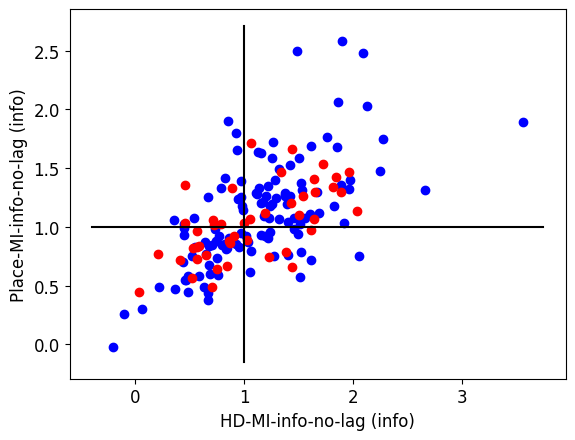

Skipping Place vs Locomotion as not in columns
Skipping Place vs Place-NotSmoothed as not in columns
Skipping Place vs Heading-Ego as not in columns
Skipping Place vs Heading-Allo as not in columns
Skipping Speed-Head vs Locomotion as not in columns


In [19]:
behave_pairs=[
              ("AHV-Abs", "AHV"),
              # ("AHV-Abs", "Speed"),
              # ("AHV-Abs", "Locomotion"),
              #("Speed", "Locomotion"),
              # ("HD", "AHV"),
              # ("HD", "AHV-Abs"),
              #("HD", "Speed"),
              ("HD", "Locomotion"),
              ("HD", "Heading-Ego"),
              ("HD", "Heading-Allo"),
              ("Heading-Ego", "Heading-Allo"),
              ("HD", "Place"),
              # ("Place", "AHV"),
              # ("Place", "AHV-Abs"),
              #("Place", "Speed"),
              ("Place", "Locomotion"),
              ("Place", "Place-NotSmoothed"),
              ("Place", "Heading-Ego"),
              ("Place", "Heading-Allo"),
              ("Speed-Head", "Locomotion"),
            ]

#behave_pairs=[("Place", "HD")]
# behave_pairs=[("Heading-Ego", "Heading-Allo")]
# behave_pairs=[("Heading-Ego", "Heading-Allo"),
#               ("HD", "Heading-Ego"),
#               ("HD", "Heading-Allo"),
#               ("Place", "HD")]

penk_indexes = df_roi["celltype"] == "penk"
nonpenk_indexes = ~penk_indexes
for bp in behave_pairs:

    b1, b2 = bp
    
    mi_col1 = b1 + '-MI-info-no-lag'
    mi_col2 = b2 + '-MI-info-no-lag'
    sig_col1 = b1 + '-MI-info-sig99'
    sig_col2 = b2 + '-MI-info-sig99'
    
    if mi_col1 not in df_roi.columns or mi_col2 not in df_roi.columns:
        print("Skipping {} vs {} as not in columns".format(b1, b2))
        continue
    
    # penk_info1 = (df_roi.loc[penk_indexes][mi_col1] - df_roi.loc[penk_indexes][sig_col1]) / df_roi.loc[penk_indexes][sig_col1]
    # penk_info2 = (df_roi.loc[penk_indexes][mi_col2] - df_roi.loc[penk_indexes][sig_col2]) / df_roi.loc[penk_indexes][sig_col2]
    # nonpenk_info1 = (df_roi.loc[nonpenk_indexes][mi_col1] - df_roi.loc[nonpenk_indexes][sig_col1]) / df_roi.loc[nonpenk_indexes][sig_col1]
    # nonpenk_info2 = (df_roi.loc[nonpenk_indexes][mi_col2] - df_roi.loc[nonpenk_indexes][sig_col2]) / df_roi.loc[nonpenk_indexes][sig_col2]
    
    penk_info1 = (df_roi.loc[penk_indexes][mi_col1]) / df_roi.loc[penk_indexes][sig_col1]
    penk_info2 = (df_roi.loc[penk_indexes][mi_col2]) / df_roi.loc[penk_indexes][sig_col2]
    nonpenk_info1 = (df_roi.loc[nonpenk_indexes][mi_col1]) / df_roi.loc[nonpenk_indexes][sig_col1]
    nonpenk_info2 = (df_roi.loc[nonpenk_indexes][mi_col2]) / df_roi.loc[nonpenk_indexes][sig_col2]
    

    plt.figure()
    plt.scatter(penk_info1,
                penk_info2,
                color=pu.COLOR_PENK, label="penk")
    plt.scatter(nonpenk_info1,
                nonpenk_info2,
                color=pu.COLOR_NONPENK, label="nonpenk")


    plt.plot([1, 1], plt.ylim(), color="black")
    plt.plot(plt.xlim(), [1, 1], color="black")

    plt.xlabel("{} ({})".format(mi_col1, "info"))
    plt.ylabel("{} ({})".format(mi_col2, "info"))
    plt.show()


164
n sig = 38


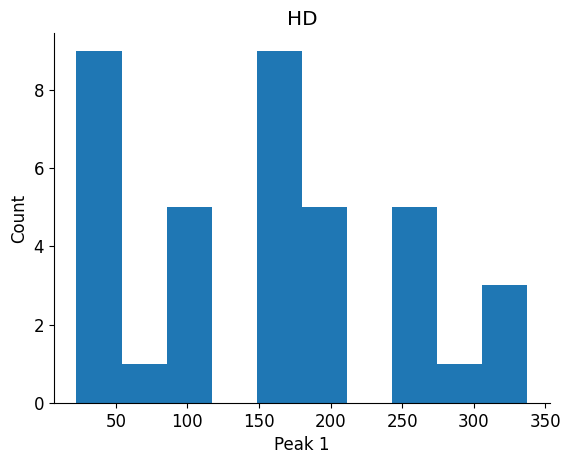

['20210823_16_59_50_1114353' '20211028_11_25_50_1115465'
 '20211203_15_10_27_1115464' '20220408_15_01_57_1116663'
 '20220802_15_06_53_1117646' '20221003_14_36_54_1118020'
 '20221018_10_56_17_1117788' '20221115_13_27_42_1118213'
 '20221116_14_31_12_1118320']


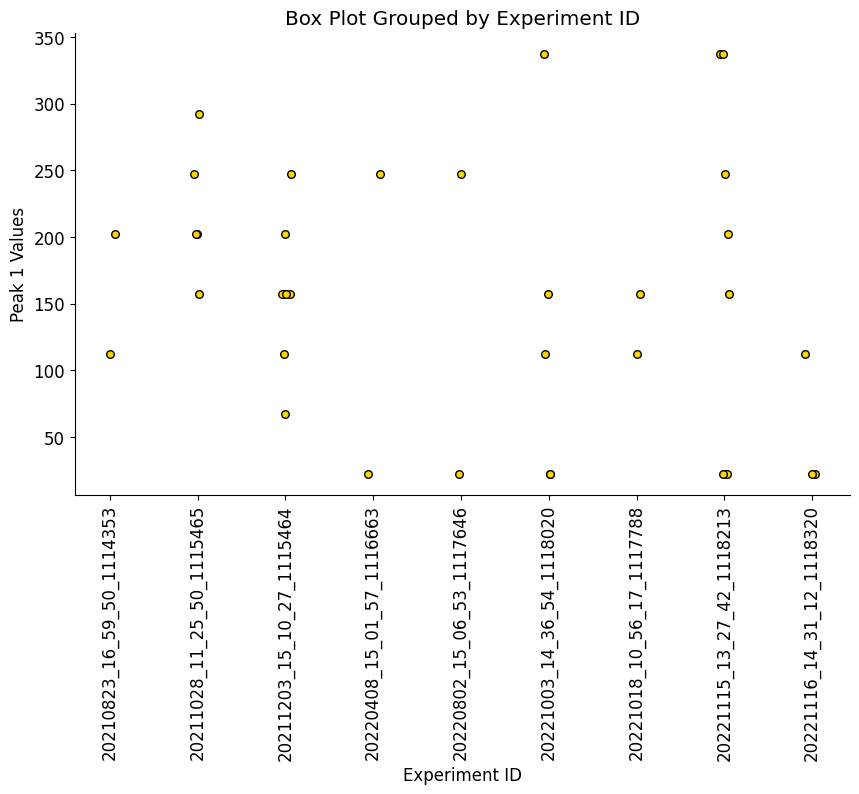

n sig = 42


TypeError: subplot() takes 1 or 3 positional arguments but 2 were given

<Figure size 640x480 with 0 Axes>

In [20]:
# Plot distributions of peak values for each behavioural measure
# Look at peak tuning

behave_inc = ["HD", "Place", "Speed"]
behave_sig_cols = []

penk_indexes = df_roi["celltype"] == "penk"
nonpenk_indexes = ~penk_indexes

#df_roi_peaks = df_roi[penk_indexes].copy(deep=True)
df_roi_peaks = df_roi.copy(deep=True)
print(df_roi_peaks.shape[0])

for bindex, bi in enumerate(behave_infos):

    if behave_inc and bi.name not in behave_inc:
        continue

    mi_col = bi.name + '-MI-info-no-lag'
    sig_col = bi.name + '-MI-info-sig95'
    is_sig_col = bi.name + '-MI-is-sig-tuned'
    inter_corr_col = bi.name + '-MI-corr-inter'
    half_corr_col = bi.name + '-MI-corr-half'
    inter_corr_p_col = bi.name + '-MI-corr-p-inter'
    half_corr_p_col = bi.name + '-MI-corr-p-half'
    inter_corr_lower_col = bi.name + '-MI-corr-inter-lower'
    half_corr_lower_col = bi.name + '-MI-corr-half-lower'
    
    mi_peak1_col = bi.name + '-MI-peak1-no-lag'
    mi_peak2_col = bi.name + '-MI-peak2-no-lag'
    
    sig_indexes = (df_roi[mi_col] > df_roi[sig_col]) & (df_roi[inter_corr_lower_col] > 0)
    
    print("n sig = {}".format(np.sum(sig_indexes)))
    if bi.name == "Place":
        
        # Extract the x and y values
        x_values = df_roi_peaks.loc[sig_indexes][mi_peak1_col]
        y_values = df_roi_peaks.loc[sig_indexes][mi_peak2_col]
        
        fig, ax1 = plt.subplot(1, 1)
        #img1 = ax1.imshow(tune_info_zero.bin_ca_means.T)
        ax1.tick_params(
            axis='both',  # changes apply to the both axis
            which='both',  # both major and minor ticks are affected
            bottom=False,  # ticks along the bottom edge are off
            left=False,
            labelleft=False,
            labelbottom=False)  # labels along the bottom edge are off
        #cbar = fig.colorbar(img1, ax=ax1)
        #cbar.ax.set_ylabel(cu.get_ca_unit_rate(RESPONSE_TYPE), rotation=90)
        maze_poly_x, maze_poly_y = bu.get_maze_poly().exterior.coords.xy
        ax1.plot(maze_bin_sub * np.array(maze_poly_x) - 0.5,
                 maze_bin_sub * np.array(maze_poly_y) - 0.5,
                 'k', linewidth=3)
        ax1.spines[['left', 'top', 'right', 'bottom']].set_visible(False)
        
        plt.show()
    else:        
        # Plot a histogram of peak1
        plt.figure()
        plt.hist(df_roi_peaks.loc[sig_indexes][mi_peak1_col], bins=10)
        plt.xlabel("Peak 1")
        plt.ylabel("Count")
        plt.title(bi.name)
        plt.gca().spines[['top', 'right']].set_visible(False)
        plot_path = cfg.sum_plot_path / "peaks-{}-{}-all.png".format(behave_info.name,
                                                                     RESPONSE_TYPE)
        plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
        plt.show()
        
        # Filter the DataFrame based on sig_indexes and select only the relevant columns
        df_filtered = df_roi_peaks.loc[sig_indexes, [mi_peak1_col, 'exp_id']]
        unique_exp_ids = df_filtered['exp_id'].unique()
        print(unique_exp_ids)
        data_to_plot = [df_filtered[df_filtered['exp_id'] == exp_id][mi_peak1_col] for exp_id in unique_exp_ids]
        
        # Create the box plot
        plt.figure(figsize=(10, 6))  # Adjust figure size as needed
        #box = plt.boxplot(data_to_plot, patch_artist=True, notch=False, widths=0.6)
        
        # Adjustments for better visibility of data points
        for i, exp_id in enumerate(unique_exp_ids, start=1):
            y_data = df_filtered[df_filtered['exp_id'] == exp_id][mi_peak1_col]
            # Spread adjustment to minimize overlap - tweak std dev and check plot
            x_data = np.random.normal(i, 0.04, size=len(y_data))
            plt.scatter(x_data, y_data, alpha=1, edgecolor='k', facecolor='gold', s=30)  # Adjust alpha and s as needed
        
        # # Customizing the boxplot appearance
        # for patch in box['boxes']:
        #     patch.set_facecolor('skyblue')  # Example color
        
        # Setting x-axis labels to unique exp_id values
        plt.xticks(range(1, len(unique_exp_ids) + 1), [str(exp_id) for exp_id in unique_exp_ids], rotation=90)  # Rotate x-axis labels for clarity
        
        plt.xlabel("Experiment ID")
        plt.ylabel("Peak 1 Values")
        plt.title("Box Plot Grouped by Experiment ID")
        plt.gca().spines[['top', 'right']].set_visible(False)
        
        plot_path = cfg.sum_plot_path / "peaks-{}-{}-exp.png".format(behave_info.name,
                                                                     RESPONSE_TYPE)
        plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
        plt.show()
        
        
        # Plot boxplot by animal todo

# Soma vs dend

# Some dend analysis

soma dend
n=25 penk=22 non-penk=0
penk n=22 non-penk=0
n=25 penk=22 non-penk=0


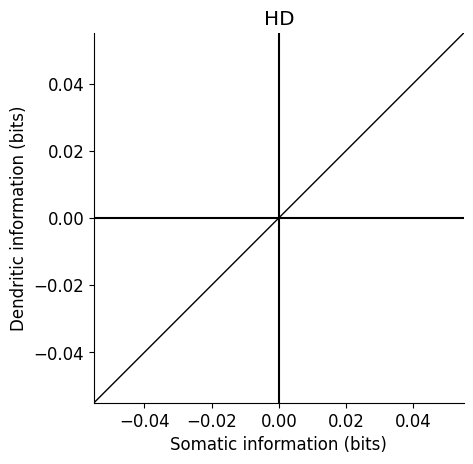

Wilcoxon WilcoxonResult(statistic=nan, pvalue=nan)


ValueError: autodetected range of [nan, nan] is not finite

In [21]:
EXP_SOMA_ID = "exp_id_soma_id"
EXP_DEND_ID = "exp_id_dend_id"

df_pair_conn[EXP_SOMA_ID] = df_pair_conn["exp_id"] + "_" + df_pair_conn["roi_index_1"].astype(str)
df_pair_conn[EXP_DEND_ID] = df_pair_conn["exp_id"] + "_" + df_pair_conn["roi_index_2"].astype(str)

comparisons = [("soma", "dend"),
               #("dend", "dend_joint"),
               # ("dend_joint", "dend_local")
               ]

for (type1, type2) in comparisons:
    
    suffix1 = '-' + type1
    suffix2 = '-' + type2
    
    print(type1, type2)
    
    df_roi_types = df_roi_withdend.copy(deep=True)
    df_roi_types = df_roi_types[df_roi_types["roi_type"].isin([type1, type2])]
    
    if type1 == "soma" and type2 == "dend":
        df_roi_pair_stats = df_pair_conn.copy(deep=True)
        df_roi_pair_stats = df_roi_pair_stats.merge(df_roi_types,
                                                    left_on=EXP_SOMA_ID, 
                                                    right_on=EXP_ROI_ID,
                                                    how='left')
        
        df_roi_pair_stats = df_roi_pair_stats.merge(df_roi_types, 
                                                    left_on=EXP_DEND_ID, 
                                                    right_on=EXP_ROI_ID,
                                                    how='left',
                                                    suffixes=(suffix1, suffix2))
    else:
        indexes1 = df_roi_withdend["roi_type"] == type1
        indexes2 = df_roi_withdend["roi_type"] == type2
        df_roi1_stats = df_roi_withdend[indexes1].copy(deep=True)
        df_roi2_stats = df_roi_withdend[indexes2].copy(deep=True)
        df_roi_pair_stats = df_roi1_stats.merge(df_roi2_stats,
                                                left_on=EXP_ROI_ID, 
                                                right_on=EXP_ROI_ID,
                                                how='inner',
                                                suffixes=(suffix1, suffix2))
    
    
    
    penk_pair_ids = df_roi[df_roi["celltype"] == "penk"][EXP_ROI_ID]
    nonpenk_pair_ids = df_roi[df_roi["celltype"] == "nonpenk"][EXP_ROI_ID]
    
    print("n={} penk={} non-penk={}".format(df_roi_pair_stats.shape[0],
                                            np.sum(df_roi_pair_stats["celltype"+suffix1] == "penk"),
                                            np.sum(df_roi_pair_stats["celltype"+suffix2] == "nonpenk")))
    
    for i, behave_info in enumerate(behave_infos):
    
        mi_info_col = behave_info.name + '-MI-info-no-lag'
        mi_sig_col = behave_info.name + '-MI-info-sig95'
        
        mi_col1 = mi_info_col + suffix1
        mi_col2 = mi_info_col + suffix2
        mi_sig_col1 = mi_sig_col + suffix1
        mi_sig_col2 = mi_sig_col + suffix2
        
        mi_metric1 = mi_col1 + "-metric"
        mi_metric2 = mi_col2 + "-metric"
        
        mi_info_light_col1 = behave_info.name + '-MI-info-light' + suffix1
        mi_info_light_col2 = behave_info.name + '-MI-info-light' + suffix2
        mi_info_dark_col1 = behave_info.name + '-MI-info-dark' + suffix1
        mi_info_dark_col2 = behave_info.name + '-MI-info-dark' + suffix2
        mi_info_lighdark_diff_col1 = behave_info.name + '-MI-info-light-dark-diff' + suffix1
        mi_info_lighdark_diff_col2 = behave_info.name + '-MI-info-light-dark-diff' + suffix2
        
        df_roi_pair_stats[mi_info_lighdark_diff_col1] = df_roi_pair_stats[mi_info_light_col1] - df_roi_pair_stats[mi_info_dark_col1]
        df_roi_pair_stats[mi_info_lighdark_diff_col2] = df_roi_pair_stats[mi_info_light_col2] - df_roi_pair_stats[mi_info_dark_col2]
        
        
        inter_corr_col1 = behave_info.name + '-MI-corr-inter'  + suffix1
        inter_corr_col2 = behave_info.name + '-MI-corr-inter'  + suffix2
        
        inter_corr_lower_col1 = behave_info.name + '-MI-corr-inter-lower'  + suffix1
        inter_corr_lower_col2 = behave_info.name + '-MI-corr-inter-lower'  + suffix2
        
        sig_pair1 = np.logical_and(df_roi_pair_stats[mi_col1] >= df_roi_pair_stats[mi_sig_col1],
                                   df_roi_pair_stats[inter_corr_col1] > 0)

        sig_pair2 = np.logical_and(df_roi_pair_stats[mi_col2] >= df_roi_pair_stats[mi_sig_col2],
                                   df_roi_pair_stats[inter_corr_col2] > 0)
        
        # sig_pair1 = df_roi_pair_stats[inter_corr_col1] > 0
        # 
        # sig_pair2 = df_roi_pair_stats[inter_corr_col2] > 0
        
        sig_pairs = np.logical_or(sig_pair1, sig_pair2)
        
        #df_roi_pair_stats_plot = df_roi_pair_stats[sig_pairs].copy(deep=True)
        df_roi_pair_stats_plot = df_roi_pair_stats.copy(deep=True)
        pair_penk_indexes = df_roi_pair_stats_plot[EXP_ROI_ID+suffix1].isin(penk_pair_ids)
        pair_nonpenk_indexes = df_roi_pair_stats_plot[EXP_ROI_ID+suffix2].isin(nonpenk_pair_ids)
        
        print("penk n={} non-penk={}".format(np.sum(pair_penk_indexes), np.sum(pair_nonpenk_indexes)))
        
        print("n={} penk={} non-penk={}".format(df_roi_pair_stats_plot.shape[0],
                                            np.sum(df_roi_pair_stats_plot["celltype"+suffix1] == "penk"),
                                            np.sum(df_roi_pair_stats_plot["celltype"+suffix2] == "nonpenk")))
                                  
        
        df_roi_pair_stats_plot[mi_metric1] = df_roi_pair_stats_plot[mi_col1]
        df_roi_pair_stats_plot[mi_metric2] = df_roi_pair_stats_plot[mi_col2]
        
        # df_roi_pair_stats_plot[mi_metric1] = (df_roi_pair_stats_plot[mi_col1] - df_roi_pair_stats_plot[mi_sig_col1]) 
        # df_roi_pair_stats_plot[mi_metric2] = (df_roi_pair_stats_plot[mi_col2] - df_roi_pair_stats_plot[mi_sig_col2])
        # 
        # df_roi_pair_stats_plot[mi_metric1] = (df_roi_pair_stats_plot[mi_col1] - df_roi_pair_stats_plot[mi_sig_col1]) / df_roi_pair_stats_plot[mi_sig_col1]
        # df_roi_pair_stats_plot[mi_metric2] = (df_roi_pair_stats_plot[mi_col2] - df_roi_pair_stats_plot[mi_sig_col2]) / df_roi_pair_stats_plot[mi_sig_col2]
    

        diffs = df_roi_pair_stats_plot[mi_metric1] - df_roi_pair_stats_plot[mi_metric2]
        
        event_diffs = (df_roi_pair_stats_plot['n_events_joint'] + df_roi_pair_stats_plot['n_events_roi_1']) - \
                      (df_roi_pair_stats_plot['n_events_joint'] + df_roi_pair_stats_plot['n_events_roi_2'])
        
        event_single_diffs = df_roi_pair_stats_plot['n_events_x'] - df_roi_pair_stats_plot['n_events_y']
        
        n_events_total = df_roi_pair_stats_plot['n_events_joint'] + \
                         df_roi_pair_stats_plot['n_events_roi_1'] + \
                         df_roi_pair_stats_plot['n_events_roi_2']

        percent_dend_events = df_roi_pair_stats_plot['n_events_roi_2'] / n_events_total
        
        snr_diffs = (df_roi_pair_stats_plot['snr-soma'] - df_roi_pair_stats_plot['snr-dend'])
    
        #diffs = diffs[sig_roi]
        result = wilcoxon(diffs)
        result_ttest = ttest_1samp(diffs, 0)
        
        plt.figure()
        plt.scatter(df_roi_pair_stats_plot[pair_penk_indexes][mi_metric1],
                    df_roi_pair_stats_plot[pair_penk_indexes][mi_metric2],
                    color=pu.COLOR_PENK, label="penk")
        plt.scatter(df_roi_pair_stats_plot[pair_nonpenk_indexes][mi_metric1],
                    df_roi_pair_stats_plot[pair_nonpenk_indexes][mi_metric2],
                    color=pu.COLOR_NONPENK, label="nonpenk")
        
        # plt.scatter(df_roi_pair_stats[mi_metric_soma],
        #             df_roi_pair_stats[mi_metric_dend])
        
        
        
        plt.xlabel("Somatic information (bits)")
        plt.ylabel("Dendritic information (bits)")
        pu.square_plot(plt.gca())
        plt.plot([0, 0], plt.ylim(), color="black")
        plt.plot(plt.xlim(), [0, 0], color="black")
        plt.title(behave_info.name) # + " p={:.3f}".format(result.pvalue))
        plt.gca().spines[['right', 'top']].set_visible(False)
        plot_path = cfg.sum_plot_path / "{}-vs-{}-{}-{}-scatter.png".format(type1,
                                                                         type2,
                                                                         RESPONSE_TYPE, 
                                                                         behave_info.name)
        plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
        plt.show()
        
        # Plot the histogram with bars (using weights to make it a fraction)
        print("Wilcoxon", result)
    
        weights = np.ones_like(diffs) / float(len(diffs))
        y, x = np.histogram(diffs, bins=10, weights=weights)
        x = (x[:-1] + x[1:]) / 2  # Convert bin edges to centers
        
        # Smooth the histogram outline
        y_smooth = gaussian_filter1d(y, sigma=1.0)
        #y_smooth = y
        
        # Plot the smoothed outline
        plt.plot(x, y_smooth, color='black', linewidth=4)
        
        # Plot a solid vertical line at zero
        plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
        
        plt.xlabel("Somatic - dendrite information")
        plt.ylabel("Fraction")
        plt.title(behave_info.name) # + " p={:.3f}".format(result.pvalue))
        plt.gca().spines[['right', 'top']].set_visible(False)
        plot_path = cfg.sum_plot_path / "{}-vs-{}-{}-{}-hist.png".format(type1,
                                                                         type2,
                                                                         RESPONSE_TYPE, 
                                                                         behave_info.name)
        plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
        plt.show()
        
        spearmanr_result = su.nanspearmanr(event_single_diffs.values, diffs.values)
        plt.figure()
        plt.scatter(event_single_diffs[pair_penk_indexes],
                    diffs[pair_penk_indexes],
                    color=pu.COLOR_PENK, label="penk")
        plt.scatter(event_single_diffs[pair_nonpenk_indexes],
                    diffs[pair_nonpenk_indexes],
                    color=pu.COLOR_NONPENK, label="nonpenk")
        
        plt.xlabel("Somatic - dendritic # events")
        plt.ylabel("Somatic - dendritic information (bits)")
        plt.title(behave_info.name + " r={:.2f} p={:.3f}".format(spearmanr_result.statistic,
                                                                 spearmanr_result.pvalue))
        plt.gca().spines[['right', 'top']].set_visible(False)
        plot_path = cfg.sum_plot_path / "{}-vs-{}-{}-{}-scatter-events.png".format(type1,
                                                                                   type2,
                                                                                   RESPONSE_TYPE, 
                                                                                   behave_info.name)
        plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
        plt.show()
        
        
        plt.figure()
        plt.scatter(df_roi_pair_stats_plot[pair_penk_indexes][mi_info_lighdark_diff_col1],
                    df_roi_pair_stats_plot[pair_penk_indexes][mi_info_lighdark_diff_col2],
                    color=pu.COLOR_PENK, label="penk")
        plt.scatter(df_roi_pair_stats_plot[pair_nonpenk_indexes][mi_info_lighdark_diff_col1],
                    df_roi_pair_stats_plot[pair_nonpenk_indexes][mi_info_lighdark_diff_col2],
                    color=pu.COLOR_NONPENK, label="nonpenk")
        
      
        plt.xlabel("Somatic light - dark information (bits)")
        plt.ylabel("Dendritic light - dark information (bits)")
        pu.square_plot(plt.gca())
        plt.plot([0, 0], plt.ylim(), color="black")
        plt.plot(plt.xlim(), [0, 0], color="black")
        plt.title(behave_info.name) # + " p={:.3f}".format(result.pvalue))
        plt.gca().spines[['right', 'top']].set_visible(False)
        plot_path = cfg.sum_plot_path / "{}-vs-{}-{}-{}-lighdark-scatter.png".format(type1,
                                                                         type2,
                                                                         RESPONSE_TYPE, 
                                                                         behave_info.name)
        plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
        plt.show()


        spearmanr_result = su.nanspearmanr(percent_dend_events.values, diffs.values)
        plt.figure()
        plt.scatter(percent_dend_events[pair_penk_indexes],
                    diffs[pair_penk_indexes],
                    color=pu.COLOR_PENK, label="penk")
        plt.scatter(percent_dend_events[pair_nonpenk_indexes],
                    diffs[pair_nonpenk_indexes],
                    color=pu.COLOR_NONPENK, label="nonpenk")
        
        plt.xlabel("Joint events (%)")
        plt.ylabel("Somatic - dendritic information (bits)")
        plt.title(behave_info.name + " r={:.2f} p={:.3f}".format(spearmanr_result.statistic,
                                                                 spearmanr_result.pvalue))
        plt.gca().spines[['right', 'top']].set_visible(False)
        plot_path = cfg.sum_plot_path / "{}-vs-{}-{}-{}-scatter-joint.png".format(type1,
                                                                                  type2,
                                                                                  RESPONSE_TYPE, 
                                                                                  behave_info.name)
        plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
        plt.show()
        
        
        snr_info_result = su.nanpearsonr(np.abs(snr_diffs.values), 
                                         np.abs(diffs.values))
        plt.figure()
        plt.scatter(np.abs(snr_diffs[pair_penk_indexes]),
                    np.abs(diffs[pair_penk_indexes]),
                    color=pu.COLOR_PENK, label="penk")
        plt.scatter(np.abs(snr_diffs[pair_nonpenk_indexes]),
                    np.abs(diffs[pair_nonpenk_indexes]),
                    color=pu.COLOR_NONPENK, label="nonpenk")
        
        plt.xlabel("Abs Soma - dendrite SNR")
        plt.ylabel("Abs Somatic - dendritic information (bits)")
        plt.title(behave_info.name + " r={:.2f} p={:.3f}".format(snr_info_result.statistic,
                                                                 snr_info_result.pvalue))
        plt.gca().spines[['right', 'top']].set_visible(False)
        plot_path = cfg.sum_plot_path / "{}-vs-{}-{}-{}-scatter-snr.png".format(type1,
                                                                                  type2,
                                                                                  RESPONSE_TYPE, 
                                                                                  behave_info.name)
        plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
        plt.show()
        
        
        

In [ ]:
diffs

In [ ]:

roi_type1 = "dend_joint"
roi_type2 = "dend_both"
indexes_joint = df_roi_withdend["roi_type"] == roi_type1
indexes_local = df_roi_withdend["roi_type"] == roi_type2

label_joint = "Joint events (bits)"
label_local= "All dendritic events (bits)"
label_diff = "Joint - all dendritic events (bits)"

suffix_joint = '_' + roi_type1
suffix_local = '_' + roi_type2

df_roi_joint_stats = df_roi_withdend[indexes_joint].copy(deep=True)
df_roi_local_stats = df_roi_withdend[indexes_local].copy(deep=True)
df_roi_jointlocal_stats = df_roi_joint_stats.merge(df_roi_local_stats,
                                                   left_on=EXP_ROI_ID, 
                                                   right_on=EXP_ROI_ID,
                                                   how='inner',
                                                   suffixes=(suffix_joint, suffix_local))

print(np.sum(indexes_joint))
penk_pair_ids = df_roi_withdend[df_roi_withdend["celltype"] == "penk"][EXP_ROI_ID]
nonpenk_pair_ids = df_roi_withdend[df_roi_withdend["celltype"] == "nonpenk"][EXP_ROI_ID]


for i, behave_info in enumerate(behave_infos):

    mi_info_col = behave_info.name + '-MI-info-no-lag'
    mi_sig_col = behave_info.name + '-MI-info-sig95'

    mi_col_joint = mi_info_col + suffix_joint
    mi_col_local = mi_info_col + suffix_local
    mi_sig_col_joint = mi_sig_col + suffix_joint
    mi_sig_col_local = mi_sig_col + suffix_local

    mi_metric_joint = mi_col_joint + "-metric"
    mi_metric_local = mi_col_local + "-metric"

    # sig_pair1 = np.logical_and(df_roi_jointlocal_stats[mi_col1] >= df_roi_jointlocal_stats[mi_sig_col1],
        #                            df_roi_jointlocal_stats[inter_corr_lower_col1] > 0)
        # 
        # sig_pair2 = np.logical_and(df_roi_jointlocal_stats[mi_col2] >= df_roi_jointlocal_stats[mi_sig_col2],
        #                            df_roi_jointlocal_stats[inter_corr_lower_col2] > 0)

    # sig_pair1 = df_roi_jointlocal_stats[df_roi_jointlocal_stats] > 0
    # 
    # sig_pair2 = df_roi_jointlocal_stats[df_roi_jointlocal_stats] > 0
    # 
    # sig_pairs = np.logical_or(sig_pair1, sig_pair2)

    #df_roi_jointlocal_stats = df_roi_jointlocal_stats[sig_pairs].copy(deep=True)
    df_roi_jointlocal_stats_plot = df_roi_jointlocal_stats.copy(deep=True)


    df_roi_jointlocal_stats_plot[mi_metric_joint] = df_roi_jointlocal_stats_plot[mi_col_joint]
    df_roi_jointlocal_stats_plot[mi_metric_local] = df_roi_jointlocal_stats_plot[mi_col_local]

    pair_penk_indexes = df_roi_jointlocal_stats_plot[EXP_ROI_ID].isin(penk_pair_ids)
    pair_nonpenk_indexes = df_roi_jointlocal_stats_plot[EXP_ROI_ID].isin(nonpenk_pair_ids)

    print("penk n={} non-penk={}".format(np.sum(pair_penk_indexes), np.sum(pair_nonpenk_indexes)))


    # df_roi_jointlocal_stats_plot[mi_metric_joint] = (df_roi_jointlocal_stats_plot[mi_col_joint] - df_roi_jointlocal_stats_plot[mi_sig_col_joint]) 
    # df_roi_jointlocal_stats_plot[mi_metric_local] = (df_roi_jointlocal_stats_plot[mi_col_local] - df_roi_jointlocal_stats_plot[mi_sig_col_local])

    # df_roi_jointlocal_stats_plot[mi_metric_joint] = (df_roi_jointlocal_stats_plot[mi_col_joint] - df_roi_jointlocal_stats_plot[mi_sig_col_joint]) / df_roi_jointlocal_stats_plot[mi_sig_col_joint]
    # df_roi_jointlocal_stats_plot[mi_metric_local] = (df_roi_jointlocal_stats_plot[mi_col_local] - df_roi_jointlocal_stats_plot[mi_sig_col_local]) / df_roi_jointlocal_stats_plot[mi_sig_col_local]

    diffs = df_roi_jointlocal_stats_plot[pair_penk_indexes][mi_metric_joint] - df_roi_jointlocal_stats_plot[pair_penk_indexes][mi_metric_local]
    
    

    #diffs = diffs[sig_roi]
    result = wilcoxon(diffs)
    print("Wilcoxon", result)


    plt.figure()
    plt.scatter(df_roi_jointlocal_stats_plot[pair_penk_indexes][mi_metric_joint],
                df_roi_jointlocal_stats_plot[pair_penk_indexes][mi_metric_local],
                color=pu.COLOR_PENK, label="penk")
    plt.scatter(df_roi_jointlocal_stats_plot[pair_nonpenk_indexes][mi_metric_joint],
                df_roi_jointlocal_stats_plot[pair_nonpenk_indexes][mi_metric_local],
                color=pu.COLOR_NONPENK, label="nonpenk")

    # plt.scatter(df_roi_jointlocal_stats_plot[mi_metric_soma],
    #             df_roi_jointlocal_stats_plot[mi_metric_dend])



    plt.xlabel(label_joint)
    plt.ylabel(label_local)
    pu.square_plot(plt.gca())
    plt.plot([0, 0], plt.ylim(), color="black")
    plt.plot(plt.xlim(), [0, 0], color="black")
    plt.title(behave_info.name + " p={:.3f}".format(result.pvalue))
    plt.gca().spines[['right', 'top']].set_visible(False)
    plot_path = cfg.sum_plot_path / "dend-{}-vs-{}-{}-{}-scatter.png".format(roi_type1,
                                                                              roi_type2,
                                                                              RESPONSE_TYPE, 
                                                                              behave_info.name)
    plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
    plt.show()


    # Plot the histogram with bars (using weights to make it a fraction)



    weights = np.ones_like(diffs) / float(len(diffs))
    y, x = np.histogram(diffs, bins=10, weights=weights)
    x = (x[:-1] + x[1:]) / 2  # Convert bin edges to centers

    # Smooth the histogram outline
    y_smooth = gaussian_filter1d(y, sigma=1.0)
    #y_smooth = y

    # Plot the smoothed outline
    plt.plot(x, y_smooth, color='black', linewidth=2)

    # Plot a solid vertical line at zero
    plt.axvline(0, color='black', linestyle='-', linewidth=1)
    plt.title(behave_info.name + " p={:.3f}".format(result.pvalue))
    plt.xlabel(label_diff)
    plt.ylabel("Fraction")
    plt.gca().spines[['right', 'top']].set_visible(False)
    plot_path = cfg.sum_plot_path / "dend-{}-vs-{}-{}-{}-hist.png".format(roi_type1,
                                                                              roi_type2,
                                                                              RESPONSE_TYPE, 
                                                                              behave_info.name)
    plt.savefig(plot_path, dpi=PLOT_SUM_DPI, facecolor='white', bbox_inches='tight')
    plt.show()
    
        

In [ ]:
# Look at local events and light and activity

In [ ]:
# df_behave_ca_dend_joint = df_behave_ca[df_behave_ca["roi_type"] == "dend_joint"].copy(deep=True)
# df_behave_ca_dend_local = df_behave_ca[df_behave_ca["roi_type"] == "dend_both"].copy(deep=True)
# df_behave_ca_dend_both = df_behave_ca[df_behave_ca["roi_type"] == "dend_both"].copy(deep=True)
# 
# 
# # df_behave_ca_dend_joint[cu.CA_EVENTS_ONSET] = df_behave_ca_dend_joint[cu.CA_EVENTS_ONSET] * (df_behave_ca_dend_joint["masks2"] == 2)
# # df_behave_ca_dend_local[cu.CA_EVENTS_ONSET] = df_behave_ca_dend_local[cu.CA_EVENTS_ONSET] * (df_behave_ca_dend_local["masks2"] == 1)
# # 
# # df_behave_ca_joint_move = df_behave_ca_dend_joint[df_behave_ca_dend_joint[bu.IS_ACTIVE]].copy(deep=True)
# # df_behave_ca_local_move = df_behave_ca_dend_local[df_behave_ca_dend_local[bu.IS_ACTIVE]].copy(deep=True)


In [ ]:
# EXP_ROI_ID = "exp_id_roi_id"
# 
# df_behave_ca_joint_move[EXP_ROI_ID] = df_behave_ca_joint_move["exp_id"] + "_" + df_behave_ca_joint_move["roi_id"].astype(str)
# 
# df_behave_ca_local_move[EXP_ROI_ID] = df_behave_ca_local_move["exp_id"] + "_" + df_behave_ca_local_move["roi_id"].astype(str)

In [ ]:
# # Look at how light and activitity affects local events
# state_pairs = [
#     ("Light", "Dark", bu.LIGHT_ON, df_behave_ca_dend_both, df_behave_ca_dend_local, df_behave_ca_dend_both),
#     ("Active", "Inactive", bu.IS_ACTIVE, df_behave_ca_dend_both, df_behave_ca_dend_local, df_behave_ca_dend_both),
# ]
# 
# for (sp1, sp2, sp_col, df_joint, df_local, df_both) in state_pairs:
#     print(sp1, sp2)
#     df_joint_sp = df_joint.groupby([EXP_ROI_ID, sp_col], group_keys=False)[cu.CA_EVENTS_ONSET].apply(lambda x: (x * TWOP_FPS * 60).mean()).reset_index()
#     
#     df_local_sp = df_local.groupby([EXP_ROI_ID, sp_col], group_keys=False)[cu.CA_EVENTS_ONSET].apply(lambda x: (x * TWOP_FPS * 60).mean()).reset_index()
#     
#     df_both = df_both.groupby([EXP_ROI_ID, sp_col], group_keys=False)[cu.CA_EVENTS_ONSET].apply(lambda x: (x * TWOP_FPS * 60).mean()).reset_index()
#     
#     df_bothlocal_sp = df_both.merge(df_local_sp, 
#                                     left_on=[EXP_ROI_ID, sp_col], 
#                                     right_on=[EXP_ROI_ID, sp_col],
#                                     how="inner",
#                                     suffixes=('_both', '_local'))
#     
#     indexes1 = df_bothlocal_sp[sp_col] == 1
#     indexes2 = ~indexes1
#     
#     plt.figure()
#     diff2 = 100 * df_bothlocal_sp[indexes2]['event_onset_local'] / df_bothlocal_sp[indexes2]['event_onset_both']
#     diff1 = 100 * df_bothlocal_sp[indexes1]['event_onset_local'] / df_bothlocal_sp[indexes1]['event_onset_both']
#     plt.scatter(diff2,
#                 diff1,
#                 )
#     plt.xlabel(sp2 + " local event percentage (%)")
#     plt.ylabel(sp1 + " local event percentage (%)")
#     pu.square_plot()
#     
#     diffs = diff1.values - diff2.values
#     
#     print(diffs)
#     result = wilcoxon(diffs)
#     print("Wilcoxon", result)
#     plt.title("p={:.3f}".format(result.pvalue))
#     plt.show()
#     
#     # df_bothlocal_all = df_joint.groupby([EXP_ROI_ID], group_keys=False)[cu.CA_EVENTS_ONSET].apply(lambda x: (x * TWOP_FPS * 60).mean()).reset_index()
#     
# 
#     
#     # df_joint_all = df_joint.groupby([EXP_ROI_ID], group_keys=False)[cu.CA_EVENTS_ONSET].apply(lambda x: (x * TWOP_FPS * 60).mean()).reset_index()
#     # 
#     # df_local_all = df_local.groupby([EXP_ROI_ID], group_keys=False)[cu.CA_EVENTS_ONSET].apply(lambda x: (x * TWOP_FPS * 60).mean()).reset_index()
#     
#     # df_jointlocal_all = df_joint_all.merge(df_local_all, 
#     #                                        left_on=[EXP_ROI_ID], 
#     #                                        right_on=[EXP_ROI_ID],
#     #                                        how="inner")
#     # 
#     # indexes1 = df_bothlocal_sp[sp_col] == 1
#     # indexes2 = ~indexes1
#     
#     
#     # print(df_jointlocal_all[['event_onset_x', 'event_onset_y']])
#     # 
#     # plt.figure()
#     # plt.scatter(df_jointlocal_all['event_onset_x'],
#     #             df_jointlocal_all['event_onset_y'])
#     # plt.xlabel(sp1 + " Event Rate (events/min)")
#     # plt.ylabel(sp2 + " Event Rate (events/min)")
#     # plt.title('{} & {}'.format(sp1, sp2))
#     # pu.square_plot()
#     # 
#     # plt.figure()
#     # plt.scatter(df_jointlocal_sp[indexes1]['event_onset_x'],
#     #             df_jointlocal_sp[indexes1]['event_onset_y'])
#     # plt.xlabel("Joint Event Rate (events/min)")
#     # plt.ylabel("Local Event Rate (events/min)")
#     # plt.title(sp1)
#     # pu.square_plot()
#     # 
#     # plt.figure()
#     e
#     
#     # plt.figure()
#     # 
#     # diff2 = df_jointlocal_sp[indexes2]['event_onset_x'] - df_jointlocal_sp[indexes2]['event_onset_y']
#     # diff1 = df_jointlocal_sp[indexes1]['event_onset_x'] - df_jointlocal_sp[indexes1]['event_onset_y']
#     # plt.scatter(diff2,
#     #             diff1,
#     #             )
#     # plt.xlabel(sp2 + " Joint vs Local (events/min)")
#     # plt.ylabel(sp1 + " Joint vs Local (events/min)")
#     # pu.square_plot()
#     # 
#     # diffs = diff1.values - diff2.values
#     # 
#     # print(diffs)
#     # result = wilcoxon(diffs)
#     # print("Wilcoxon", result)
#     
#     # Not sure what this is
#     # plt.figure()
#     # plt.scatter(df_jointlocal_sp[indexes2]['event_onset_x'],
#     #             df_jointlocal_sp[indexes1]['event_onset_x'])
#     # plt.xlabel(sp2 + " Joint Event Rate (events/min)")
#     # plt.ylabel(sp1 + " Joint Event Rate (events/min)")
#     # pu.square_plot()
#     # plt.show()
#     # 
#     # diffs = df_jointlocal_sp[indexes2]['event_onset_x'].values - df_jointlocal_sp[indexes1]['event_onset_x'].values
#     # result = wilcoxon(diffs)
#     # print("Wilcoxon", result)
#     # 
#     # plt.figure()
#     # plt.scatter(df_jointlocal_sp[indexes2]['event_onset_y'],
#     #             df_jointlocal_sp[indexes1]['event_onset_y'])
#     # plt.xlabel(sp2 + " Local Event Rate (events/min)")
#     # plt.ylabel(sp1 + " Local Event Rate (events/min)")
#     # pu.square_plot()
#     # plt.show()
#     # 
#     # diffs = df_jointlocal_sp[indexes2]['event_onset_y'].values - df_jointlocal_sp[indexes1]['event_onset_y'].values
#     # result = wilcoxon(diffs)
#     # print("Wilcoxon", result)

In [ ]:
for c in df_roi_pair_stats_plot.columns:
    print(c)

In [ ]:
df_roi


In [ ]:
- df_roi[mi_lag_info_before_mean]/df_roi[mi_sig_col]